# Smart Grid Agents for Egypt: EGrid-118

## From Primal-Dual Lagrangian to Spatially-Aware Augmented Lagrangian OPF-RL with GAT-PPO

**Author:** Mohamed Ehab Ahmed Mohamed Bishla  
**Affiliation:** Third-Year Undergraduate, CS Department, Faculty of Computers and Informatics, Suez Canal University  
**Environment:** Google Colab (CPU/GPU Runtime)

---

### Abstract

Modern power grids face unprecedented challenges from renewable energy intermittency, transmission congestion, and supply disruptions. This project presents **EgyptGrid-118**, a deep reinforcement learning framework for real-time optimal power flow (OPF) dispatch on a 118-bus system under severe constraints. The controller employs a **Graph Attention Network (GAT)** architecture coupled with **Proximal Policy Optimization (PPO)** to operate on the complex topology of the power grid. The project evolves through four distinct phases of increasing sophistication.

---

### Simulation Infrastructure and Real-World Data Integration

The agent operates within the [**Grid2Op**](https://github.com/rte-france/Grid2Op) environment (`l2rpn_wcci_2022`) with the [**LightSim2Grid**](https://github.com/BDonnot/lightsim2grid) C++ backend for accelerated AC power flow computation. Generator capacity parameters (`gen_pmax`, `Output_MW`) are augmented with **real-world data from the 2022 Egyptian Electricity Holding Company (EEHC) Annual Report**, covering more than 63 generators including:

| Data Field | Source | Description |
|-----------|--------|-------------|
| `Output_MW` | EEHC 2022 | Nominal generator capacity (MW) |
| `Source` | EEHC 2022 | Fuel type (gas, oil, solar, wind, hydro) |
| `English Name` | EEHC 2022 | Generator plant identifier |

This bridges the gap between academic benchmark environments and real Egyptian grid operational characteristics. A capacity scaling factor (`cap_scale = 5.3748`) maps real Egyptian generator capacities to the WCCI 2022 grid topology, matching the 63+ EEHC generators to the 62 WCCI generators via descending capacity sorting.

---

### Core Contributions and Innovations

#### 1. Physics-Informed GAT Architecture (Phases 2–3)

The model uses a **dual-channel adjacency tensor** derived from the complex bus admittance matrix:

$$Y_{bus} = G + jB$$

where:
- $G$ = conductance (real power losses, active power coupling)
- $B$ = susceptance (reactive power coupling, electrical distance)

**Architecture highlights:**

- **Positional encoding layer** injects bus ordering information into node features
- **Generator feature encoder** processes 4 × 62 = 248-dimensional generator state (normalized active power, voltage setpoint, renewable status, headroom per generator)
- **Gating mechanism** dynamically blends emergency voltage/curtailment actions with nominal setpoints ($\mu = 0.5$) based on grid stability assessment, preventing unnecessary adjustments during steady-state operation

#### 2. Primal-Dual Lagrangian Formulation (Phase 3)

We reformulate the constrained AC-OPF as a Lagrangian dual optimization. Constraint violations are computed at each timestep:

**Constraint functions:**

| Constraint | Formula | Interpretation |
|-----------|---------|----------------|
| $g_V$ | $\frac{1}{N}\sum \max(0, \|V_i - 1.0\| - V_{max\_dev})$ | Voltage band violation (pu) |
| $g_T$ | $\frac{1}{|E|}\sum \max(0, \rho_k - 1.0)$ | Thermal overload (fraction) |
| $g_G$ | $\frac{1}{N_g}\sum \frac{\|\text{clipped}_i - \text{raw}_i\|}{P_{max,i}}$ | Generator limit violation (fraction) |
| $g_C$ | $0.5 \cdot g_{C\_eff} + 0.3 \cdot g_{C\_phys} + 0.2 \cdot g_{C\_fair}$ | Renewable curtailment composite |

**Dual variable updates (dual ascent):**

$$\lambda_i \leftarrow \max(0, \lambda_i + \alpha \cdot g_i)$$

$$\alpha = 0.001 \text{ (learning rate)}, \lambda_{max} = 50.0$$

This eliminates hand-tuned penalty coefficients, enabling automatic discovery of the optimal trade-off between generation cost minimization and constraint satisfaction.

**Phase 3 Reward:**

$$r_t = W_{survival} - \text{cost}(P_g) - \lambda_V g_V - \lambda_T g_T - \lambda_G g_G - \lambda_C g_C + \text{equity} - \text{losses}$$

#### 3. Augmented Lagrangian with Quadratic Damping (Phase 4)

To prevent the "seesaw effect" where agents oscillate between violating and over-correcting constraints, we introduce an **augmented Lagrangian (Hamiltonian) formulation**:

$$r_t = W_{survival} - \text{cost}(P_g) - \sum \lambda_i g_i - \sum \frac{\rho_i}{2} g_i^2 + \text{equity} - \text{losses}$$

where:
- $\lambda_i$ = Lagrange multipliers (learned via dual ascent)
- $\rho_i = 5.0$ = quadratic penalty coefficients (fixed)
- The $\frac{\rho}{2}g^2$ term provides **convex regularization** stabilizing dual variable convergence

#### 4. Spatial Action Clustering via K-Means on $Y_{bus}$ (Phase 4)

Using **K-Means clustering** ($k = 8$) on the rows of the bus admittance magnitude matrix $\sqrt{G^2 + B^2}$, we partition the 118 buses into electrically coherent zones:

```
Generator → Bus mapping → Cluster assignment
    gen_i  →  gen_sub[i]  →  bus_cluster[gen_sub[i]]
```

**Soft attention masking mechanism:**

- When a bus experiences voltage deviation > 0.05 pu, its **cluster** is flagged as "affected"
- Generators in affected clusters receive a **bias factor** of $+1.0$ in actor pre-activations
- Generators in unaffected clusters receive a bias factor of $-0.5$
- This biases exploration toward **localized, physics-informed dispatch** without hard constraining the action space

#### 5. Stabilization Mechanisms (Phase 4)

**Key improvements for training stability:**

| Mechanism | Implementation | Purpose |
|-----------|----------------|---------|
| Tanh removal | Raw reward (no squashing) | Preserve gradient magnitude during failures |
| λ decay | $\lambda \leftarrow \max(0, \lambda \cdot 0.995)$ per update | Prevent multiplier windup |
| Normalized observations | $P/400$, $\Delta V$, $\theta/180°$, $[0,1]$ ratios | Comparable feature scales for GAT |
| Post-clip log-probs | `dist.log_prob(clipped_action)` | Accurate policy gradient |
| Online return norm | Welford's algorithm + $\pm 3.0$ clip | Stable critic across curriculum waves |
| Wave-aware LR schedule | Milestones at $[100, 160, 220]$ updates × 0.5 | Appropriate LR for difficulty progression |

#### 6. Curriculum Learning under Geopolitical Supply Shocks

A five-wave curriculum (1,500 episodes total) progressively exposes the agent to increasing Suez Canal gas supply disruptions:

| Wave | Episodes | Shock Range | Objective |
|------|----------|-------------|-----------|
| **I – Baseline** | 400 | 0.0 – 0.0% | Establish equilibrium, calibrate multipliers |
| **II – Adaptation** | 300 | 0.10 – 0.30% | Learn constraint-aware dispatch |
| **IIb – Stability Edge** | 300 | 0.40 – 0.50% | Handle severe localized disruptions |
| **III – Resiliency** | 400 | 0.30 – 0.60% | Survive capacity deficits under constraints |
| **IV – Generalization** | 100 | 0.00 – 0.70% (random) | Validate robust constrained control |

Shocks are applied exclusively to the Eastern Canal fossil fuel fleet (gas/oil generators identified from EEHC data), simulating realistic geopolitical risks to Egypt's energy security.

#### 7. Comprehensive Multi-Metric Tracking and Visualization

The framework provides extensive diagnostics:

- **Training Curves:** 10-panel dashboard including Lagrangian g and λ evolution
- **Test Results:** 5-row subplot grid with constraint violation and multiplier panels
- **Voltage Heatmap Before Blackout:** Per-bus voltage deviation over final 50 steps
- **Critic Calibration:** Predicted value vs. actual discounted return
- **Extended Sensitivity:** Voltage violations vs. reward, equity, losses (with regression)
- **Correlation Heatmap:** Pairwise metric correlations
- **GAT Attention Heatmap:** Layer 2 attention weights averaged over heads
- **Action Distribution:** Histogram of generator setpoints (0–1 normalized)
- **Steps vs. Shock Scatter:** Survival degradation across shock levels
- **Composite Radar Chart:** In-distribution vs. OOD performance comparison
- **Topology Visualization:** 118-bus network with color-coded voltage/loading

---

### Key Results

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **Jain's Equity** | >99% | Near-perfect load distribution fairness |
| **Voltage Violations** | <0.008 pu | Well within ±6% band |
| **Thermal Loading** | <0.90 ρ | Significant headroom before overload |
| **Training Efficiency** | Early stop at ep 1,264 | Converged before full curriculum |
| **OOD Generalization** | Comparable to in-distribution | Robust to unseen shock patterns |

Under 45% Suez shock conditions, the spatial clustering mechanism reduces unnecessary curtailment by focusing generator adjustments within affected electrical zones. The augmented Lagrangian formulation eliminates the oscillation behavior observed in standard Lagrangian approaches.

---

### Limitations

1. **Static Clustering:** K-Means on $Y_{bus}$ is computed offline and does not adapt to topological changes from line outages or islanding events, potentially misdirecting attention during cascading failures.

2. **Manual ρ Tuning:** Augmented Lagrangian penalty parameters require manual selection per constraint type; automated hyperparameter optimization would improve reproducibility across grid configurations.

3. **Single Chronic Training:** Training on a single chronic scenario (WCCI 2022) limits generalization to unseen grid topologies, load patterns, and generator dispatch configurations.

4. **Computational Cost:** The 186-dimensional action space (3 × 62 generators: ΔP, V setpoint, curtailment fraction) requires ~270K trainable parameters despite clustering optimization.

5. **Simplified Latency Model:** SCADA communication latency is modeled only through a delay penalty rather than explicit time-domain simulation of communication protocols and measurement delays.

6. **Full Observability Assumption:** The framework assumes perfect state observability of all 118 buses, whereas real-world grids operate with partial and noisy measurements from sparse PMU/SCADA deployments.

7. **Generator Data Alignment:** Matching EEHC report (63+ generators) to WCCI grid (62 generators) requires heuristic matching based on descending capacity sorting, introducing potential feature misalignment.

---

### Future Work

1. **Dynamic Spectral Clustering:** Update zones in real-time based on admittance matrices recalculated with current line statuses, enabling adaptive zone reconfiguration during cascading failures.

2. **Meta-Learning for ρ:** Train a meta-controller to adjust augmented Lagrangian penalty parameters across multiple chronic scenarios, automating hyperparameter selection.

3. **Multi-Chronic Training:** Train on diverse grid configurations and load patterns from Grid2Op's chronic library for topological robustness.

4. **Production Integration:** Deploy on production-grade simulators (Grid2Op with Pandapower/Andes backends, OPAL-RT hardware-in-the-loop) for deployment validation.

5. **Distribution Grid Extension:** Adapt to lower voltage levels with higher renewable penetration, bidirectional power flows, and prosumer integration.

6. **Partial Observability:** Implement recurrent GAT architectures (GRU/LSTM) to handle missing or noisy measurements from sparse sensor networks.

7. **Multi-Objective Optimization:** Incorporate carbon emission tracking, energy equity metrics across socioeconomic regions, and frequency stability constraints beyond N-1 security criterion.

---

## Section 0 — Environment Setup

Mount Google Drive and install all required packages. `lightsim2grid` provides the fast C++ AC power-flow solver; `grid2op` supplies the physics environment and action/observation API.

In [1]:
import subprocess
import sys

pkgs = ['lightsim2grid', 'grid2op', 'networkx', 'seaborn']
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs,
    check=True
)
print("All packages installed.")

All packages installed.


In [2]:
import os
import time
import warnings
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
import gymnasium as gym
from gymnasium import spaces
import grid2op
from lightsim2grid.lightSimBackend import LightSimBackend
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx
from sklearn.cluster import KMeans


warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

os.makedirs('./output', exist_ok=True)
os.makedirs('/checkpoints', exist_ok=True)
print("Imports OK — output dirs ready.")


c:\Users\Moham\miniconda3\envs\smart-grid-gnn-ppo\lib\site-packages\grid2op\Backend\pandaPowerBackend.py:38: UserWarning: Numba cannot be loaded. You will gain possibly massive speed if installing it by 
	c:\Users\Moham\miniconda3\envs\smart-grid-gnn-ppo\python.exe -m pip install numba

  warnings.warn(


Imports OK — output dirs ready.


## Section 1 — Global Constants & Curriculum Definition

### Voltage and Thermal Constraint Bounds

| Key | Value | Description |
|-----|-------|-------------|
| `V_LOW_WARN` | 0.90 pu | Lower voltage warning threshold – below this triggers constraint violation |
| `V_HIGH_WARN` | 1.10 pu | Upper voltage warning threshold – above this triggers constraint violation |
| `V_LOW_TIGHT` | 0.94 pu | Strict lower voltage bound for violation counting in metrics |
| `V_HIGH_TIGHT` | 1.06 pu | Strict upper voltage bound for violation counting in metrics |
| `V_MAX_DEV` | 0.06 pu | Maximum allowed voltage deviation from 1.0 pu for Lagrangian constraint $g_V$ |
| `RHO_LIMIT` | 1.0 pu | Thermal rating limit – Grid2Op terminates if any line exceeds this loading |

---

### Reward Function Weights (Phase 3-4 Lagrangian/OPF Components)

| Key | Value | Description |
|-----|-------|-------------|
| `W_SURVIVAL` | 2.0 | Per-step survival bonus (scaled to fit within typical reward range) |
| `W_EQUITY` | 2.0 | Jain's equity bonus weight (reduced 10× from Phase 2 value of 20.0) |
| `W_RENEWABLE_CUR` | 2.0 | Penalty coefficient for renewable energy curtailment |
| `W_RENEWABLE_USE` | 0.5 | Incentive coefficient for renewable energy utilization |
| `W_REDIST` | 0.3 | Penalty coefficient for redispatch magnitude (action smoothness) |
| `W_CURTAIL_PRESSURE` | 0.5 | Pressure coefficient gently ramping curtailment penalty during early training |
| `W_POWER_LOSS_PEN` | 0.05 | Penalty coefficient for transmission power losses |
| `W_BASE_G2OP` | 5.0 | Scalar for Grid2Op native reward signal (not used in current formulation) |
| `W_ACTION_SMOOTH` | 0.05 | Penalty coefficient for action change smoothness (temporal regularization) |
| `W_COST_QUAD` | 0.01 | Quadratic generation cost coefficient: $\text{cost} = \sum (c_2 P_i^2)$ |
| `W_COST_LIN` | 0.05 | Linear generation cost coefficient: $\text{cost} = \sum (c_1 P_i)$ |

---

### Lagrangian Multiplier Parameters

| Key | Value | Description |
|-----|-------|-------------|
| `LR_LAMBDA` | 0.001 | Dual-ascent step size for Lagrange multiplier updates |
| `LAMBDA_MAX` | 50.0 | Upper bound clipping for all Lagrange multipliers |
| `LAMBDA_DECAY` | 0.995 | Per-update multiplicative decay factor (prevents λ windup) |

**Dual variable update rule:**

$$\lambda_i \leftarrow \min\left(\lambda_{max},\ \max\left(0,\ (\lambda_i + \alpha \cdot g_i) \cdot \gamma_{decay}\right)\right)$$

where $\alpha = 0.001$ and $\gamma_{decay} = 0.995$

---

### Augmented Lagrangian Quadratic Penalty Parameters (Phase 4)

| Key | Value | Description |
|-----|-------|-------------|
| `RHO_V` | 5.0 | Quadratic penalty coefficient for voltage constraint: $\frac{\rho_V}{2} g_V^2$ |
| `RHO_T` | 5.0 | Quadratic penalty coefficient for thermal constraint: $\frac{\rho_T}{2} g_T^2$ |
| `RHO_G` | 5.0 | Quadratic penalty coefficient for generator limit constraint: $\frac{\rho_G}{2} g_G^2$ |
| `RHO_C` | 5.0 | Quadratic penalty coefficient for curtailment constraint: $\frac{\rho_C}{2} g_C^2$ |

**Augmented Lagrangian reward formulation:**

$$r_t = W_{survival} - \text{cost}(P_g) - \sum \lambda_i g_i - \sum \frac{\rho_i}{2} g_i^2 + \text{equity} - \text{losses}$$

---

### Equity and Terminal Reward Parameters

| Key | Value | Description |
|-----|-------|-------------|
| `EQ_MIN_THRESHOLD` | 0.80 | Sigmoid gate threshold – equity bonus only when average load satisfaction > 80% |
| `FAIL_STEP_THRESH` | 10 | Minimum steps before terminal failure penalty is applied |
| `FAIL_PENALTY_SCALE` | 2.0 | Scale factor for early termination penalty (Lagrangian handles main constraint signal) |
| `SUCCESS_BONUS` | 3.0 | Bonus reward for completing full episode (scaled to tanh range equivalent) |
| `RETURN_NORM_CLIP` | 3.0 | Maximum absolute value for normalized returns in GAE computation |

---

### PPO Hyperparameters

| Key | Value | Description |
|-----|-------|-------------|
| `LR` | 1 × 10⁻⁴ | Adam optimizer learning rate for policy and value networks |
| `CLIP_EPS` | 0.2 | PPO clipping epsilon for policy ratio: $\min(r_t A_t, \text{clip}(r_t, 1-\epsilon, 1+\epsilon) A_t)$ |
| `GAMMA` | 0.99 | Discount factor for future rewards in return computation |
| `GAE_LAMBDA` | 0.95 | Generalized Advantage Estimation (GAE) λ parameter for bias-variance trade-off |
| `PPO_EPOCHS` | 5 | Number of optimization epochs per PPO update step |
| `GRAD_CLIP` | 0.5 | Maximum gradient norm for gradient clipping during backpropagation |

---

### Policy Distribution Parameters

| Key | Value | Description |
|-----|-------|-------------|
| `LOG_STD_MIN` | 0.01 | Minimum log standard deviation for action distribution (prevents zero exploration) |
| `LOG_STD_MAX` | 0.35 | Maximum log standard deviation for action distribution (prevents excessive randomness) |

**Action distribution for each generator head:**

$$\sigma_P = \exp(\log\_std\_P),\ \sigma_V = \exp(\log\_std\_V),\ \sigma_C = \exp(\log\_std\_C)$$

Initial values: `log_std_P = -1.0`, `log_std_V = -1.5`, `log_std_C = -1.0`

---

### Environment and Training Configuration

| Key | Value | Description |
|-----|-------|-------------|
| `ENV_NAME` | `"l2rpn_wcci_2022"` | Grid2Op environment identifier (WCCI 2022 competition benchmark) |
| `HORIZON_BATCH_SIZE` | 512 | Number of environment steps collected before each PPO update |
| `TOTAL_TRAIN_EPISODES` | 1,500 | Total episodes across all curriculum waves (see curriculum table above) |
| `CKPT_EVERY` | 250 | Episodes between model checkpoint saves |
| `N_BUS` | 118 | Number of buses (substations) in the grid topology |
| `N_GEN` | 62 | Number of controllable generators |
| `ACTION_DIM` | 186 | Total action dimension (3 × 62: ΔP power, V setpoint, curtailment fraction) |
| `CAP_SCALE` | 5.3748 | Scaling factor mapping EEHC real capacities to WCCI generator limits |

---

### Learning Rate Schedule

| Key | Value | Description |
|-----|-------|-------------|
| `WAVE_LR_MILESTONES` | [100, 160, 220] | PPO update indices where learning rate decays |
| `WAVE_LR_GAMMA` | 0.5 | Multiplicative factor for LR at each milestone |

**Learning rate progression:**

| Update Range | Learning Rate | Wave Alignment |
|-------------|---------------|----------------|
| 0 – 99 | 1.0 × 10⁻⁴ | Waves I–II (Baseline + Adaptation) |
| 100 – 159 | 5.0 × 10⁻⁵ | Wave IIb (Stability Edge, shock up to 50%) |
| 160 – 219 | 2.5 × 10⁻⁵ | Wave III (Resiliency, shock up to 60%) |
| 220+ | 1.25 × 10⁻⁵ | Wave IV (Generalization, random shock up to 70%) |

---

### Spatial Clustering Parameters

| Key | Value | Description |
|-----|-------|-------------|
| `N_CLUSTERS` | 8 | Number of K-Means clusters for bus partitioning |
| `VIOLATION_THRESHOLD` | 0.05 pu | Voltage deviation threshold to flag a bus as "violating" for mask computation |
| `IN_ZONE_BIAS` | 0.8 | Soft mask value for generators in affected clusters |
| `OUT_ZONE_BIAS` | 0.2 | Soft mask value for generators in unaffected clusters |
| `BIAS_FACTOR` | 2.0 × (mask − 0.5) | Linear transformation mapping mask to actor bias range [-1.0, +1.0] |

---

In [3]:
ENV_NAME = "l2rpn_wcci_2022"
HORIZON_BATCH_SIZE = 512

V_LOW_WARN = 0.90
V_HIGH_WARN = 1.10
V_LOW_TIGHT = 0.94
V_HIGH_TIGHT = 1.06
V_MAX_DEV = 0.06
RHO_LIMIT = 1.0

W_SURVIVAL = 2.0
W_EQUITY = 2.0                           # kept low, Lagrangian handles constraints
W_RENEWABLE_CUR = 2.0                    # penalty for curtailment
W_RENEWABLE_USE = 0.5
W_REDIST = 0.3
W_CURTAIL_PRESSURE = 0.5
W_POWER_LOSS_PEN = 0.05
W_BASE_G2OP = 5.0
W_ACTION_SMOOTH = 0.05
W_COST_QUAD = 0.01
W_COST_LIN  = 0.05

LR_LAMBDA = 0.001                        # dual‑ascent step
LAMBDA_MAX = 50.0
LAMBDA_DECAY = 0.995                     # per‑update decay factor (windup guard)

# ── Augmented Lagrangian ρ (quadratic penalty) ────
RHO_V = 5.0
RHO_T = 5.0
RHO_G = 5.0
RHO_C = 5.0

EQ_MIN_THRESHOLD = 0.80
FAIL_STEP_THRESH = 10
FAIL_PENALTY_SCALE = 2.0
SUCCESS_BONUS = 3.0
RETURN_NORM_CLIP = 3.0

LR         = 1e-4
CLIP_EPS   = 0.2
GAMMA      = 0.99
GAE_LAMBDA = 0.95
PPO_EPOCHS = 5
GRAD_CLIP  = 0.5
LOG_STD_MIN = 0.01
LOG_STD_MAX = 0.35

CURRICULUM = [
    (400, 0.00, 0.00, "I   — Baseline"),
    (300, 0.10, 0.30, "II  — Adaptation"),
    (300, 0.40, 0.50, "IIb — Stability Edge"),
    (400, 0.30, 0.60, "III — Resiliency"),
    (100, 0.00, 0.70, "IV  — Generalization")
]
TOTAL_TRAIN_EPISODES = sum(c[0] for c in CURRICULUM)
CKPT_EVERY = 250
OUTPUT_DIR = './output'
CKPT_DIR   = './checkpoints'
CSV_PLANTS = './env_needed_csv/egypt_power_plants_processed.csv'
print("Constants loaded – Augmented Lagrangian mode.")

Constants loaded – Augmented Lagrangian mode.


## Section 2 — Physics Environment (`RobustEnv`)


In [4]:
class RobustEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, noise_std=0.02, failure_prob=0.05, suez_shock_pct=0.15,
                 is_test_env=False, load_bus_mask=None):
        super().__init__()
        self.g2op_env = grid2op.make(ENV_NAME, backend=LightSimBackend())
        self.n_bus      = self.g2op_env.n_sub      # 118
        self.gen_count   = self.g2op_env.n_gen       # 62
        self.action_dim = self.gen_count * 3         # P, V, Curtail
        self.prev_action = np.zeros(self.action_dim, dtype=np.float32)

        # topology tables
        self._line_or_sub = np.array(self.g2op_env.line_or_to_subid)
        self._line_ex_sub = np.array(self.g2op_env.line_ex_to_subid)
        self._gen_sub     = np.array(self.g2op_env.gen_to_subid)
        self._load_sub    = np.array(self.g2op_env.load_to_subid)
        # bus incident lines for connectivity features
        self._bus_incident_lines = [[] for _ in range(self.n_bus)]
        for lid in range(self.g2op_env.n_line):
            self._bus_incident_lines[self._line_or_sub[lid]].append(lid)
            self._bus_incident_lines[self._line_ex_sub[lid]].append(lid)
        self._max_degree = max(len(inc) for inc in self._bus_incident_lines) or 1

        # nominal voltages per bus
        self._sub_v_nom = np.ones(self.n_bus, dtype=np.float32)
        try:
            line_v_nom = np.array(self.g2op_env.backend.lines_or_pu_to_kv, dtype=np.float32)
            for lid in range(self.g2op_env.n_line):
                self._sub_v_nom[self._line_or_sub[lid]] = line_v_nom[lid]
                self._sub_v_nom[self._line_ex_sub[lid]] = line_v_nom[lid]
        except Exception:
            pass

        # generator CSV mapping
        csv_loaded = False
        try:
            df_plants = pd.read_csv(CSV_PLANTS)
            df_plants = df_plants[df_plants['Output_MW'].notna() & (df_plants['Output_MW']>0)]
            if len(df_plants) < self.gen_count:
                reps = int(np.ceil(self.gen_count/len(df_plants)))
                df_plants = pd.concat([df_plants]*reps, ignore_index=True)
            df_plants_sorted = df_plants.sort_values('Output_MW', ascending=False).reset_index(drop=True)
            wcci_pmax_order = np.argsort(-self.g2op_env.gen_pmax)
            self._gen_pmax_order = wcci_pmax_order
            self.real_pmax = df_plants_sorted['Output_MW'].values[:self.gen_count].astype(np.float32)
            csv_loaded = True
        except Exception as e:
            print(f"Warning: CSV not loaded, using grid2op defaults. {e}")
            self.real_pmax = np.array(self.g2op_env.gen_pmax, dtype=np.float32)

        # renewable / fossil masks
        renewable_kw = ['solar','wind','hydro']
        if csv_loaded:
            sources = df_plants_sorted['Source'].values[:self.gen_count]
        else:
            sources = self.g2op_env.gen_type
        self._renewable_mask = np.array([any(k in str(s).lower() for k in renewable_kw) for s in sources], dtype=bool)
        fossil_kw = ['gas','oil']
        self._fossil_mask = np.array([any(k in str(s).lower() for k in fossil_kw) for s in sources], dtype=bool)
        self._renewable_pmax = self.real_pmax * self._renewable_mask

        # capacity scaling
        self.egypt_total_cap = self.real_pmax.sum()
        self.wcci_total_cap  = self.g2op_env.gen_pmax.sum()
        self.cap_scale = self.egypt_total_cap / (self.wcci_total_cap + 1e-8)
        self.unique_load_subs = np.unique(self._load_sub)
        self._load_bus_mask = (load_bus_mask if load_bus_mask is not None
                               else np.isin(np.arange(self.n_bus), self._load_sub))

        # observation & action spaces
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.n_bus,6), dtype=np.float32)
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(self.action_dim,), dtype=np.float32)

        self.noise_std = noise_std
        self.failure_prob = failure_prob
        self.suez_shock_pct = suez_shock_pct
        self.is_test_env = is_test_env

        # Lagrange multipliers (primal‑dual variables)
        self.lambda_V = 0.0
        self.lambda_T = 0.0
        self.lambda_G = 0.0
        self.lambda_C = 0.0

        # tracking variables
        self._last_obs = None
        self._y_bus_adj = None
        self.n_steps = 0
        self.total_train_steps = 0
        self.last_equity = 0.0
        self.last_v_viol = 0
        self.last_line_ovld = 0.0
        self.last_power_loss = 0.0
        self.last_g_V = 0.0
        self.last_g_T = 0.0
        self.last_g_G = 0.0
        self.last_g_C = 0.0
        self.last_lambda_V = 0.0
        self.last_lambda_T = 0.0
        self.last_lambda_G = 0.0
        self.last_lambda_C = 0.0
        self.last_max_v_dev = 0.0
        self.last_n_violations = 0
        self.last_max_loading = 0.0
        self._gen_names = np.array([f"Gen_{i}" for i in range(self.gen_count)])
        self._gen_sources = np.array(['Unknown']*self.gen_count)

        self.handler = self.g2op_env.chronics_handler
        self.max_steps = self.handler.max_episode_duration()
        print(f"RobustEnv ready — n_bus={self.n_bus}, action_dim={self.action_dim}")

    # ── Helpers (unchanged from original) ──────────────────────────────
    def _get_bus_voltages(self, obs):
        v_sum = np.zeros(self.n_bus, dtype=np.float32)
        v_cnt = np.zeros(self.n_bus, dtype=np.float32)
        for i,sub in enumerate(self._line_or_sub):
            v_sum[sub] += obs.v_or[i]; v_cnt[sub] += 1
        for i,sub in enumerate(self._line_ex_sub):
            v_sum[sub] += obs.v_ex[i]; v_cnt[sub] += 1
        v_cnt = np.maximum(v_cnt, 1.0)
        v_kv = v_sum / v_cnt
        return v_kv / (self._sub_v_nom + 1e-8)

    def _get_bus_injections(self, obs):
        p = np.zeros(self.n_bus, dtype=np.float32)
        for g in range(self.g2op_env.n_gen):
            p[self._gen_sub[g]] += obs.gen_p[g]
        for l in range(self.g2op_env.n_load):
            p[self._load_sub[l]] -= obs.load_p[l]
        return p

    def _get_power_loss(self, obs):
        return max(0.0, float(obs.gen_p.sum()) - float(obs.load_p.sum()))

    def _compute_generation_cost(self, gen_p_mw):
        return float(np.sum(W_COST_QUAD * gen_p_mw**2 + W_COST_LIN * gen_p_mw))

    def _get_target_load(self):
        idx = max(0, self.g2op_env.nb_time_step-1)
        target_p = self.handler.real_data.data.load_p[idx]
        return target_p * self.cap_scale

    def _calculate_ybus_complex(self, obs):
        n = self.n_bus
        y_bus = np.zeros((n,n), dtype=np.complex64)
        theta_or = np.radians(obs.theta_or)
        theta_ex = np.radians(obs.theta_ex)
        v_or_pu = obs.v_or / (self._sub_v_nom[self._line_or_sub]+1e-8)
        v_ex_pu = obs.v_ex / (self._sub_v_nom[self._line_ex_sub]+1e-8)
        v_or_c = v_or_pu * (np.cos(theta_or)+1j*np.sin(theta_or))
        v_ex_c = v_ex_pu * (np.cos(theta_ex)+1j*np.sin(theta_ex))
        s_or_c = obs.p_or + 1j*obs.q_or
        I_vec = np.conj(s_or_c/(v_or_c+1e-8))
        dV_vec = v_or_c - v_ex_c
        dV_vec = np.where(np.abs(dV_vec)<1e-6, 1e-6+0j, dV_vec)
        y_vec = np.where(np.abs(dV_vec)<1e-6, complex(100.,-100.), I_vec/dV_vec)
        np.add.at(y_bus, (self._line_or_sub,self._line_ex_sub), -y_vec)
        np.add.at(y_bus, (self._line_ex_sub,self._line_or_sub), -y_vec)
        np.add.at(y_bus, (self._line_or_sub,self._line_or_sub), y_vec)
        np.add.at(y_bus, (self._line_ex_sub,self._line_ex_sub), y_vec)
        G = np.clip(y_bus.real.astype(np.float32), -200, 200)
        B = np.clip(y_bus.imag.astype(np.float32), -200, 200)
        G_n = (np.abs(G)-np.abs(G).mean())/(np.abs(G).std()+1e-8)
        B_n = (np.abs(B)-np.abs(B).mean())/(np.abs(B).std()+1e-8)
        return np.clip(G_n,-3,3), np.clip(B_n,-3,3)

    def _get_topology_aware_adj(self, obs):
        G,B = self._calculate_ybus_complex(obs)
        tripped = ~np.array(obs.line_status, dtype=bool)
        if tripped.any():
            G[self._line_or_sub[tripped],self._line_ex_sub[tripped]] = 0
            G[self._line_ex_sub[tripped],self._line_or_sub[tripped]] = 0
            B[self._line_or_sub[tripped],self._line_ex_sub[tripped]] = 0
            B[self._line_ex_sub[tripped],self._line_or_sub[tripped]] = 0
        edge_tensor = np.stack([G,B], axis=0)
        return torch.FloatTensor(edge_tensor).unsqueeze(0)

    def _get_obs(self, obs):
        p = self._get_bus_injections(obs)
        v = self._get_bus_voltages(obs)
        theta = np.zeros(self.n_bus, dtype=np.float32)
        for lid in range(self.g2op_env.n_line):
            theta[self._line_or_sub[lid]] = obs.theta_or[lid]
            theta[self._line_ex_sub[lid]] = obs.theta_ex[lid]
        line_status = np.array(obs.line_status, dtype=np.float32)
        conn_ratio = np.zeros(self.n_bus, dtype=np.float32)
        n_tripped_norm = np.zeros(self.n_bus, dtype=np.float32)
        for b in range(self.n_bus):
            inc = self._bus_incident_lines[b]
            if inc:
                statuses = line_status[inc]
                conn_ratio[b] = statuses.mean()
                n_tripped_norm[b] = (1.0-statuses).sum() / self._max_degree
        elec = np.stack([p/400.0, v-1.0, theta/180.0], axis=-1).astype(np.float32)
        elec += np.random.normal(0, self.noise_std, elec.shape).astype(np.float32)
        conn = np.stack([conn_ratio, n_tripped_norm], axis=-1).astype(np.float32)
        load_flag = self._load_bus_mask.astype(np.float32).reshape(-1,1)
        bus_feat = np.concatenate([elec, conn, load_flag], axis=-1)   # [118,6]
        gen_p_norm = obs.gen_p / (self.g2op_env.gen_pmax+1e-6)
        gen_v = obs.prod_v / 1.04
        gen_is_ren = self._renewable_mask.astype(np.float32)
        gen_headroom = 1.0 - gen_p_norm
        gen_feat = np.concatenate([gen_p_norm, gen_v, gen_is_ren, gen_headroom])
        return bus_feat, gen_feat

    # ── Reset ────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        obs = self.g2op_env.reset()
        self._last_obs = obs
        self.n_steps = 0
        self._y_bus_adj = self._get_topology_aware_adj(obs)
        self._bus_feat, self._gen_feat = self._get_obs(obs)
        return self._get_obs(obs), {}

    # ── Safety layer ──────────────────────────
    def _apply_safety_layer(self, action_p, action_v, action_c):
        pmax = np.array(self.g2op_env.gen_pmax, dtype=np.float32)
        pmin = np.array(self.g2op_env.gen_pmin, dtype=np.float32)
        raw_p = action_p * self.real_pmax
        target_p_mw = np.clip(raw_p, pmin, pmax)
        correction = np.abs(target_p_mw - raw_p)
        g_G_p = np.mean(correction / (self.real_pmax+1e-6))
        v_range = V_HIGH_WARN - V_LOW_WARN
        raw_v = V_LOW_WARN + action_v * v_range
        target_v_pu = np.clip(raw_v, V_LOW_WARN, V_HIGH_WARN)
        g_G_v = np.mean(np.abs(target_v_pu - raw_v) / v_range)
        raw_c = action_c  # Already in [0, 1]
        target_c = np.clip(raw_c, 0.0, 1.0)
        g_G_c = np.mean(np.abs(target_c - raw_c))  # Difference in [0, 1]

        g_G = (0.5 * g_G_p + 0.3 * g_G_v + 0.2 * g_G_c)

        return target_p_mw, target_v_pu, g_G

    # ── Step ──────────────────────────────────────────────
    def step(self, action):
        self.n_steps += 1
        self.total_train_steps += 1
        n_gen = self.gen_count
        action = np.array(action, dtype=np.float32).flatten()

        # split action
        a_P = np.clip(action[:n_gen], 0.0, 1.0)
        a_V = np.clip(action[n_gen:2*n_gen], 0.0, 1.0)
        a_C = np.clip(action[2*n_gen:3*n_gen], 0.0, 1.0)

        # Suez shock on fossil generators
        if self.suez_shock_pct > 0.0:
            a_P[self._fossil_mask] *= (1.0 - self.suez_shock_pct)
        # random trip
        if np.random.rand() < self.failure_prob:
            a_P[np.random.randint(0, n_gen)] = 0.0

        # safety layer
        target_p_mw, target_v_pu, g_G = self._apply_safety_layer(a_P, a_V, a_C)

        # ── Apply action to the grid FIRST ───────────────────
        current_dispatch = self._last_obs.actual_dispatch
        redispatch_dict = {i: float(target_p_mw[i] - current_dispatch[i])
                        for i in range(n_gen) if not self._renewable_mask[i]}
        curtail_dict = {i: float(a_C[i]) for i in range(n_gen) if self._renewable_mask[i]}
        g2op_act = self.g2op_env.action_space({
            "redispatch": redispatch_dict,
            "prod_v": {i: float(v) for i, v in enumerate(target_v_pu)},
            "curtail": curtail_dict
        })
        obs, g2op_rew, done, info_extra = self.g2op_env.step(g2op_act)
        # Initialize info dict for storing metrics
        info = info_extra if isinstance(info_extra, dict) else {}

        # ── NOW compute power loss, cost, etc. using the NEW observation ─────
        total_power_loss = self._get_power_loss(obs)
        power_loss_ratio = total_power_loss / (obs.load_p.sum() + 1e-8)
        penalty_power_loss = W_POWER_LOSS_PEN * power_loss_ratio

        # action smoothness
        diff_p = np.mean((a_P - self.prev_action[:n_gen])**2)
        diff_v = np.mean((a_V - self.prev_action[n_gen:2*n_gen])**2)
        diff_c = np.mean((a_C - self.prev_action[2*n_gen:])**2)
        action_diff = 1.0 * diff_p + 0.3 * diff_v + 0.1 * diff_c
        penalty_smooth = W_ACTION_SMOOTH * action_diff

        gen_p_actual = np.array(obs.gen_p, dtype=np.float32)
        cost_gen = self._compute_generation_cost(gen_p_actual)
        # normalise cost
        pmax_avg = float(np.array(self.g2op_env.gen_pmax).mean())
        cost_scale = self.gen_count * (W_COST_QUAD * pmax_avg**2 + W_COST_LIN * pmax_avg) + 1e-6
        cost_norm = cost_gen / cost_scale

        # ── Constraint violations ────────────────────────────
        v_pu = self._get_bus_voltages(obs)
        v_dev = np.abs(v_pu - 1.0)
        g_V_smooth = np.mean((v_pu - 1.0)**2)
        g_V_dir = np.mean(v_pu - 1.0)
        g_V_hard = np.mean(np.maximum(0.0, v_dev - V_MAX_DEV))
        g_V = 0.4 * g_V_smooth + 0.4 * g_V_hard + 0.2 * g_V_dir

        g_T = np.mean(np.maximum(0.0, obs.rho - RHO_LIMIT))

        # g_G is already computed in safety layer

        # Curtailment constraint 
        renewable_avail = self.g2op_env.gen_pmax[self._renewable_mask]
        renewable_actual = obs.gen_p[self._renewable_mask]
        curtail_intent = a_C[self._renewable_mask]
        renewable_setpoint = renewable_avail * (1.0 - curtail_intent)
        total_avail_renew = renewable_avail.sum() + 1e-6
        g_C_phys = np.maximum(0.0, renewable_setpoint - renewable_actual).sum() / total_avail_renew
        max_rho = obs.rho.max()
        dynamic_target = np.clip((max_rho - 0.9) / 0.1, 0.0, 1.0)
        actual_curt_ratio = (renewable_avail - renewable_actual).sum() / total_avail_renew
        g_C_eff = np.maximum(0.0, actual_curt_ratio - dynamic_target)
        curt_norm = (renewable_avail - renewable_actual) / (renewable_avail + 1e-6)
        sq_f = np.sum(curt_norm)
        sq2_f = np.sum(curt_norm**2)
        if sq_f < 1e-8:
            jain_curt = 1.0  # Perfect fairness when no curtailment
        else:
            jain_curt = (sq_f**2) / (len(curt_norm) * sq2_f + 1e-8)
        g_C_fair = 1.0 - jain_curt
        g_C = 0.5 * g_C_eff + 0.3 * g_C_phys + 0.2 * g_C_fair

        info['g_V'] = float(g_V); info['g_T'] = float(g_T)
        info['g_G'] = float(g_G); info['g_C'] = float(g_C)

        # ── Augmented Lagrangian penalty ─────────────────────
        # Reward = - cost - sum lambda_i * g_i - sum (rho_i/2) * g_i^2
        lag_pen = (self.lambda_V * g_V + self.lambda_T * g_T +
                self.lambda_G * g_G + self.lambda_C * g_C)
        quad_pen = (RHO_V * g_V**2 + RHO_T * g_T**2 + RHO_G * g_G**2 + RHO_C * g_C**2) / 2.0

        # Jain equity
        target_p = self._get_target_load()
        sub_qualities = []
        for sub_id in self.unique_load_subs:
            mask = self._load_sub == sub_id
            sub_load_total = float(obs.load_p[mask].sum()) * self.cap_scale
            sub_target_total = float(target_p[mask].sum())
            sub_qualities.append(sub_load_total / (sub_target_total + 1e-8))
        quality_array = np.clip(np.array(sub_qualities, dtype=np.float32), 0., 1.)
        n_q = len(quality_array)
        sq = quality_array.sum()
        sq2 = (quality_array**2).sum()
        jains = (sq**2) / (n_q * sq2 + 1e-8)
        self.last_equity = float(jains * 100.0)
        avg_satisfaction = float(np.mean(quality_array))
        equity_gate = float(np.clip((avg_satisfaction - EQ_MIN_THRESHOLD) /
                                    (1.0 - EQ_MIN_THRESHOLD + 1e-6), 0., 1.))
        equity_bonus = W_EQUITY * jains * equity_gate

        # ── Assemble reward (no tanh squashing) ─────────────
        reward = (W_SURVIVAL + 0.2 * equity_bonus
                - cost_norm - lag_pen - quad_pen
                - penalty_power_loss - penalty_smooth
                - W_REDIST * np.mean((target_p_mw - obs.actual_dispatch)**2 / (self.real_pmax + 1e-6)**2))

        # Terminal penalty (now `done` is defined)
        if done and self.n_steps < self.max_steps and self.total_train_steps > 200:
            remaining_ratio = (self.max_steps - self.n_steps) / self.max_steps
            reward -= FAIL_PENALTY_SCALE * remaining_ratio
        if done and self.n_steps >= self.max_steps:
            reward += SUCCESS_BONUS

        # Store Lagrangian metrics for visualisation
        self.last_g_V = g_V; self.last_g_T = g_T
        self.last_g_G = g_G; self.last_g_C = g_C
        self.last_lambda_V = self.lambda_V
        self.last_lambda_T = self.lambda_T
        self.last_lambda_G = self.lambda_G
        self.last_lambda_C = self.lambda_C
        self.last_max_v_dev = float(v_dev.max())
        self.last_n_violations = int(np.sum(v_dev > V_MAX_DEV))
        self.last_v_viol = self.last_n_violations
        self.last_max_loading = float(obs.rho.max())

        # Update environment state
        self._last_obs = obs
        self.prev_action = action.copy()
        self._y_bus_adj = self._get_topology_aware_adj(obs)
        bus_feat, gen_feat = self._get_obs(obs)
        self._gen_feat = gen_feat
        self._bus_feat = bus_feat

        return (bus_feat, gen_feat), reward, done, False, info
    pass


## Section 3 — Out-of-Distribution Environment

`OutOfDistributionEnv` lets us test the trained policy on a **different** generator subset and shock magnitude than any seen during training, quantifying generalisation without data leakage.


In [5]:
class OutOfDistributionEnv(RobustEnv):
    def __init__(self, shock_indices, shock_percentage, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.ood_percentage = float(shock_percentage)
        valid = [i for i in shock_indices if 0 <= i < self.gen_count and self._fossil_mask[i]]
        self._ood_mask = np.zeros(self.gen_count, dtype=bool)
        self._ood_mask[valid] = True
    def reset(self, seed=None, options=None):
        self.suez_shock_pct = 0.0
        return super().reset(seed=seed, options=options)
    def step(self, action):
        action = np.asarray(action, dtype=np.float32).flatten()
        n_gen = self.gen_count
        aP = action[:n_gen].copy()
        if self.ood_percentage > 0.0:
            aP[self._ood_mask] *= (1.0 - self.ood_percentage)
        action_mod = np.concatenate([aP, action[n_gen:]])
        return super().step(action_mod)

## Section 4A - Spatial Clustering & GAT Attention Masking
We compute a K‑Means clustering of buses based on the magnitude of the admittance matrix
and use it to softly mask the actor’s output towards generators in the same cluster as buses
experiencing constraint violations.

In [6]:
class BusClusterer:
    def __init__(self, env: RobustEnv, n_clusters=8):
        # Compute a representative Ybus matrix (nominal topology)
        obs = env.g2op_env.reset()
        G, B = env._calculate_ybus_complex(obs)
        # features: per‑bus magnitude of admittance connections (ignore self)
        Y_mag = np.sqrt(G**2 + B**2)
        # sum over neighbours (exclude diagonal)
        diag = np.diag_indices_from(Y_mag)
        Y_mag[diag] = 0.0
        features = Y_mag.sum(axis=1, keepdims=True)  # total connectivity
        # also include position in G mat as extra features? use Laplacian embedding?
        # Simple: use k-means on the rows of Y_mag (adjacency matrix)
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels = self.kmeans.fit_predict(Y_mag)
        self.bus_cluster = labels                       # [n_bus]
        # map each generator to its bus cluster
        self.gen_cluster = self.bus_cluster[env._gen_sub]  # [n_gen]
        self.n_clusters = n_clusters

    def get_gen_mask_for_violations(self, v_dev, threshold=0.05):
        """Return a float mask [n_gen] – values near 1 for generators in
        clusters containing violating buses."""
        violating_buses = np.where(v_dev > threshold)[0]
        if len(violating_buses) == 0:
            return np.ones(self.gen_cluster.shape[0])  # no bias
        involved_clusters = set(self.bus_cluster[violating_buses])
        mask = np.array([0.8 if c in involved_clusters else 0.2
                         for c in self.gen_cluster], dtype=np.float32)
        return mask

## Section 4B — Physics-Informed GAT Architecture

### Why the Complex $Y_{bus}$ Matters

The admittance of branch $(i,j)$ is $y_{ij} = g_{ij} + jb_{ij}$, where:

| Component | Formula | Physical Meaning |
|-----------|---------|------------------|
| $g_{ij}$ | $R_{ij}/(R_{ij}^2 + X_{ij}^2)$ | **Conductance** – real power losses, active power coupling between buses |
| $b_{ij}$ | $-X_{ij}/(R_{ij}^2 + X_{ij}^2)$ | **Susceptance** – reactive power coupling, electrical distance metric |

Both $G$ and $B$ channels are preserved as a **2-channel edge tensor** `[1, 2, N, N]`. Each of the 4 attention heads learns an independent edge projection $W_e \in \mathbb{R}^{2 \to 1}$ via a two-layer MLP with ReLU activation:

$$\text{edge\_bias}_{ij} = \text{MLP}(G_{ij}, B_{ij})$$

The normalized conductance $\tilde{G}$ and susceptance $\tilde{B}$ are computed through standardization (clipped to $\pm 3\sigma$) to ensure stable gradient flow through the GAT layers.

---

### GAT_ActorCritic Architecture 

```
Input [B, n_bus, 6]       — (P/400, V−1.0, θ/180°, conn_ratio, n_tripped_norm, load_flag)
                                                          [normalized to comparable ranges]
Input [B, n_gen × 4]      — (p_norm, v_setpoint, is_renewable, headroom)
                                                          [generator features per unit]
Edge  [1, 2, N, N]        — (G̃, B̃) normalized branch admittances
                                                          [2-channel complex Ybus]
  │
  ├─ Input Projection:    Linear(6 → 32)
  ├─ Positional Encoding: PE(32, max_len=N)               [sine/cosine positional embedding]
  ├─ Generator Encoder:   Linear(248 → 128) → ReLU → Linear(128 → 64)
  │                       [encodes global generator state, broadcast to all nodes]
  │
  ├─ Concatenation:       [bus_feat (32) | gen_feat_broadcast (64)] → 96-dim node features
  │
  ├─ Residual Connection: Linear(96 → 128)                [skip connection for GAT1 input]
  │
  ├─ AdmittanceGATLayer₁: (96 → 128, 4 heads)             [edge-conditioned multi-head attention]
  │                       └─ edge_proj: Linear(2→128) → ReLU → Linear(128→4)
  │                       └─ LayerNorm + ReLU + Residual
  │
  ├─ AdmittanceGATLayer₂: (128 → 128, 4 heads)            [second GAT layer for deeper propagation]
  │                       └─ LayerNorm + ReLU + Residual
  │
  ├─ Global Pooling:      Concat[Mean(h₁,h₂), Max(h₁,h₂)] → 512-dim
  │
  ├─ Fusion Layer:        Linear(512 → 256) + ReLU
  │
  ├─ Gate Network:        Linear(256 → 1) → Sigmoid
  │                       [controls blending of emergency actions vs. nominal]
  │
  ├─ Actor P Head:        Linear(256 → n_gen) → Sigmoid
  │                       └─ + Spatial Cluster Bias (if enabled)
  │                       └─ → Normal(μ_P, σ_P)           [ΔP redispatch setpoints]
  │
  ├─ Actor V Head:        Linear(256+n_gen → n_gen) → Sigmoid
  │                       └─ + Spatial Cluster Bias (if enabled)
  │                       └─ Gate * μ_V + (1−Gate) * 0.5
  │                       └─ → Normal(μ_V, σ_V)           [V setpoints]
  │
  ├─ Actor C Head:        Linear(256+n_gen → n_gen) → Sigmoid
  │                       └─ + Spatial Cluster Bias (if enabled)
  │                       └─ Gate * μ_C + (1−Gate) * 0.5
  │                       └─ → Normal(μ_C, σ_C)           [curtailment fractions]
  │
  └─ Critic:              Linear(256 → 1)                 [state value estimate V(s)]
```

**Output:** The actor produces **3 × n_gen = 186 values** concatenated as `[P_part | V_part | C_part]`, matching the full action space. The critic outputs a single scalar value estimate.

---

### Key Architectural Innovations

#### 1. Dual-Channel Edge Conditioning

Unlike standard GATs that use a single scalar attention weight, our **edge-conditioned attention** uses both $G$ and $B$ channels independently:

$$\alpha_{ij}^h = \text{softmax}_j\left(\text{LeakyReLU}\left(\frac{\mathbf{a}_{src}^T\mathbf{h}_i + \mathbf{a}_{dst}^T\mathbf{h}_j + \text{MLP}(G_{ij}, B_{ij})}{\sqrt{d_k}}\right)\right)$$

This allows different attention heads to specialize in **active power flows** (conductance-dominated edges) or **reactive power support** (susceptance-dominated edges).

#### 2. Generator Feature Conditioning

Generator features (248-dim for 62 generators) are encoded through a two-layer MLP and **broadcast to all 118 bus nodes**. This ensures every bus node has visibility into global generation capacity, renewable availability, and headroom constraints—critical for coordinated dispatch decisions.

#### 3. Gating Mechanism for Emergency Actions

The gate network outputs a scalar $g \in [0,1]$ that **dynamically blends** learned voltage/curtailment actions with nominal setpoints:

$$\mu_V^{final} = g \cdot \mu_V + (1-g) \cdot 0.5$$
$$\mu_C^{final} = g \cdot \mu_C + (1-g) \cdot 0.5$$

When the grid is stable ($g \to 0$), voltage and curtailment actions default to neutral (0.5), preventing unnecessary perturbations. When instability is detected ($g \to 1$), the learned emergency actions are fully applied.

#### 4. Spatial Cluster Bias (Phase 4)

The cluster mask computed from K-Means on $Y_{bus}$ is added as a bias to actor pre-activations:

$$\mu_{biased} = \text{Sigmoid}\left(\text{Linear}(h) + 2.0 \cdot (\text{mask} - 0.5)\right)$$

- Generators in **affected zones** (mask → 0.8): receive bias ≈ **+1.0** (promoting exploration)
- Generators in **unaffected zones** (mask → 0.2): receive bias ≈ **−0.5** (discouraging unnecessary changes)

This preserves gradient flow (soft masking) while encouraging **physics-informed localized dispatch**.

---

### Parameter Count

| Component | Parameters |
|-----------|------------|
| Input Projection | 224 (Linear 6→32 + bias) |
| Positional Encoding | 0 (fixed) |
| Generator Encoder | 16,192 (Linear 248→128 + Linear 128→64) |
| Residual Projection | 12,416 (Linear 96→128) |
| GAT Layer 1 | 33,664 (QKV + edge MLP) |
| GAT Layer 2 | 66,048 (QKV + edge MLP) |
| Fusion Layer | 131,328 (Linear 512→256) |
| Gate Network | 257 |
| Actor P Head | 15,933 (Linear 256→62 + log_std) |
| Actor V Head | 19,778 (Linear 318→62 + log_std) |
| Actor C Head | 19,778 (Linear 318→62 + log_std) |
| Critic | 257 (Linear 256→1) |
| **Total Trainable** | **~270,000** |

---

### Observation Space Normalization

To ensure stable GAT training, all input features are normalized to comparable ranges:

| Feature | Raw Range | Normalization | Target Range |
|---------|-----------|---------------|--------------|
| Active Power $P$ | ±400 MW | $P / 400.0$ | $[-1, +1]$ |
| Voltage Deviation $\Delta V$ | ±0.2 pu | $\Delta V$ (already centered) | $[-0.2, +0.2]$ |
| Voltage Angle $\theta$ | ±180° | $\theta / 180.0$ | $[-1, +1]$ |
| Connectivity Ratio | [0, 1] | Raw | [0, 1] |
| Tripped Lines (norm) | [0, 1] | Raw | [0, 1] |
| Load Bus Flag | {0, 1} | Raw | {0, 1} |
| Generator $P$ (norm) | [0, 1] | $P / P_{max}$ | [0, 1] |
| Generator $V$ setpoint | [0.90, 1.10] | $V / 1.04$ | [0.87, 1.06] |
| Renewable Flag | {0, 1} | Raw | {0, 1} |
| Generator Headroom | [0, 1] | $1 - P_{norm}$ | [0, 1] |

Input observations are also perturbed with **Gaussian noise** ($\sigma = 0.02$ pu) to improve robustness to measurement errors typical in SCADA systems.

In [35]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
    def forward(self, x):
        n_nodes = x.size(1)
        if n_nodes > self.pe.size(0):
            raise ValueError(f"Nodes {n_nodes} > max_len {self.pe.size(0)}")
        return x + self.pe[:n_nodes, :].unsqueeze(0)

class AdmittanceGATLayer(nn.Module):
    def __init__(self, in_f, out_f, num_heads=4, edge_dim=2, edge_mlp_hidden=32):
        super().__init__()
        assert out_f % num_heads == 0
        self.heads = num_heads
        self.head_dim = out_f // num_heads
        self.W = nn.Linear(in_f, out_f, bias=False)
        self.a_src = nn.Parameter(torch.zeros(1, num_heads, 1, self.head_dim))
        self.a_dst = nn.Parameter(torch.zeros(1, num_heads, 1, self.head_dim))
        self.edge_proj = nn.Sequential(
            nn.Linear(edge_dim, edge_mlp_hidden*num_heads),
            nn.ReLU(),
            nn.Linear(edge_mlp_hidden*num_heads, num_heads)
        )
        self.leaky = nn.LeakyReLU(0.2)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.xavier_uniform_(self.a_src)
        nn.init.xavier_uniform_(self.a_dst)

    def forward(self, x, adj=None, return_attention=False):
        B,N,_ = x.size()
        h = self.W(x).view(B, N, self.heads, self.head_dim).transpose(1,2)  # [B,H,N,D]
        s_src = (h * self.a_src).sum(-1, keepdim=True)                       # [B,H,N,1]
        s_dst = (h * self.a_dst).sum(-1, keepdim=True)
        scores = s_src + s_dst.transpose(-2,-1)                              # [B,H,N,N]
        if adj is not None:
            edge_exists = (adj.abs().sum(dim=1, keepdim=True) > 1e-8)
            adj_feat = adj.permute(0,2,3,1)                                  # [B,N,N,2]
            e_bias = self.edge_proj(adj_feat)                                # [B,N,N,H]
            e_bias = e_bias.permute(0,3,1,2)                                  # [B,H,N,N]
            scores = (scores + e_bias).masked_fill(~edge_exists.expand(B,self.heads,N,N), -1e9)
        scores = self.leaky(scores)
        scores /= math.sqrt(self.head_dim)
        attn = F.softmax(scores, dim=-1)
        attn = F.dropout(attn, p=0.1, training=self.training)
        out = torch.matmul(attn, h).transpose(1,2).contiguous().view(B,N,-1)
        if return_attention:
            return out, attn
        return out

class GAT_ActorCritic(nn.Module):
    INPUT_DIM = 32
    def __init__(self, n_bus, action_dim):  # action_dim = n_gen
        super().__init__()
        self.n_gen = action_dim
        self.input_proj = nn.Linear(6, self.INPUT_DIM)
        self.pos_encoder = PositionalEncoding(self.INPUT_DIM, max_len=n_bus)
        self.gat1 = AdmittanceGATLayer(self.INPUT_DIM+64, 128)
        self.gat2 = AdmittanceGATLayer(128, 128)
        self.res_proj = nn.Linear(self.INPUT_DIM+64, 128)

        # Actor heads
        self.mu_P = nn.Linear(256, action_dim)
        self.mu_V = nn.Linear(256 + action_dim, action_dim)
        self.mu_C = nn.Linear(256 + action_dim, action_dim)
        self.log_std_P = nn.Parameter(torch.full([action_dim], -1.0))
        self.log_std_V = nn.Parameter(torch.full([action_dim], -1.5))
        self.log_std_C = nn.Parameter(torch.full([action_dim], -1.0))

        self.value  = nn.Linear(256, 1)
        self.gen_encoder = nn.Sequential(
            nn.Linear(4*self.n_gen, 128), nn.ReLU(), nn.Linear(128,64))
        self.fusion = nn.Linear(512, 256)
        self.gate_layer = nn.Linear(256, 1)

    def forward(self, x, adj=None, gen_feat=None, cluster_mask=None,
                return_attention=False):
        if x.dim() == 2: x = x.unsqueeze(0)
        # Normalise
        std = x.std(dim=1, keepdim=True).clamp(min=1e-3)
        x = (x - x.mean(dim=1, keepdim=True)) / std
        x = F.relu(self.input_proj(x))
        x = self.pos_encoder(x)
        if gen_feat is not None:
            g = self.gen_encoder(gen_feat)
            g_exp = g.unsqueeze(1).expand(-1, x.size(1), -1)
            x = torch.cat([x, g_exp], dim=-1)
        else:
            zeros = torch.zeros(x.size(0), x.size(1), 64, device=x.device)
            x = torch.cat([x, zeros], dim=-1)         # [B, N, 96]
        # GAT layers
        x_proj = self.res_proj(x)
        h1 = self.gat1(x, adj)
        h1 = F.layer_norm(h1, h1.shape[-1:])
        h1 = F.relu(h1 + x_proj)
        h2 = self.gat2(h1, adj)
        h2 = F.layer_norm(h2, h2.shape[-1:])
        h2 = F.relu(h2 + h1)

        h_concat = torch.cat([h1, h2], dim=-1)
        h_pool = torch.mean(h_concat, dim=1)
        h_max  = torch.max(h_concat, dim=1).values
        h = torch.cat([h_pool, h_max], dim=-1)
        h = F.relu(self.fusion(h))

        gate = torch.sigmoid(self.gate_layer(h.detach()))

        # --- Spatial bias from cluster mask ---
        if cluster_mask is not None:
            # cluster_mask shape [B, n_gen]
            bias_factor = 2.0 * (cluster_mask - 0.5)   # shift mean
        else:
            bias_factor = 0.0

        # P head
        mu_P = torch.sigmoid(self.mu_P(h) + bias_factor)
        std_P = torch.exp(self.log_std_P).clamp(LOG_STD_MIN, LOG_STD_MAX)
        dist_P = Normal(mu_P, std_P.expand_as(mu_P))

        # V & C heads with gate and bias
        emg_input = torch.cat([h, mu_P.detach()], dim=-1)
        mu_V = torch.sigmoid(self.mu_V(emg_input) + bias_factor)
        mu_C = torch.sigmoid(self.mu_C(emg_input) + bias_factor)
        mu_V = gate*mu_V + (1.0-gate)*0.5
        mu_C = gate*mu_C + (1.0-gate)*0.5
        std_V = torch.exp(self.log_std_V).clamp(LOG_STD_MIN, LOG_STD_MAX)
        std_C = torch.exp(self.log_std_C).clamp(LOG_STD_MIN, LOG_STD_MAX)
        dist_emg = Normal(torch.cat([mu_V, mu_C], dim=-1),
                          torch.cat([std_V.expand_as(mu_V), std_C.expand_as(mu_C)], dim=-1))

        val = self.value(h)
        if return_attention:
            _, a1 = self.gat1(x, adj, return_attention=True)
            _, a2 = self.gat2(h1, adj, return_attention=True)
            return (dist_P, dist_emg, val, [a1, a2])
        return (dist_P, dist_emg, val)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Section 5 — PPO Trainer with GAE & Checkpoint Saving

This section implements the **Proximal Policy Optimization (PPO)** algorithm with **Generalized Advantage Estimation (GAE)**, adapted for the constrained OPF setting with **Lagrange multiplier management** and **online return normalization**. The trainer orchestrates the entire learning process: collecting rollout data, computing advantages, updating policy and value networks, and managing dual variables for constraint enforcement.

---

### PPO Algorithm Overview

PPO is a policy gradient method that optimizes a **clipped surrogate objective** to prevent destructively large policy updates:

$$L^{CLIP}(\theta) = \mathbb{E}_t \left[ \min\left( r_t(\theta) A_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) A_t \right) \right]$$

where:
- $r_t(\theta) = \frac{\pi_\theta(a_t | s_t)}{\pi_{\theta_{old}}(a_t | s_t)}$ is the probability ratio
- $A_t$ is the advantage estimate (from GAE)
- $\epsilon = 0.2$ is the clipping parameter

The minimum operator removes the incentive for moving $r_t$ outside $[1-\epsilon, 1+\epsilon]$, ensuring conservative policy updates.

---

### Generalized Advantage Estimation (GAE)

GAE computes a **bias-variance trade-off** advantage estimate using an exponentially-weighted sum of temporal difference errors:

$$A_t^{GAE(\gamma, \lambda)} = \sum_{l=0}^{\infty} (\gamma \lambda)^l \delta_{t+l}$$

where the TD error $\delta_t$ is:

$$\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$

| Parameter | Value | Role |
|-----------|-------|------|
| $\gamma$ (discount) | 0.99 | Weights future rewards vs. immediate reward |
| $\lambda$ (GAE lambda) | 0.95 | Controls bias-variance trade-off: $\lambda \to 1$ (low bias, high variance), $\lambda \to 0$ (high bias, low variance) |

**Implementation detail:** GAE is computed in **reverse order** through the trajectory, accumulating weighted TD errors:

```python
gae = 0.0
for t in reversed(range(T)):
    delta = r[t] + γ * V[t+1] * (1 - done[t]) - V[t]
    gae = delta + γ * λ * (1 - done[t]) * gae
    returns[t] = gae + V[t]
```

Returns are computed as `advantages + values` for critic training targets.

---

### Online Return Normalization (Welford's Algorithm)

To stabilize critic learning across curriculum waves with **widely varying reward magnitudes** (from hundreds in stable episodes to negative thousands during failures), we maintain running statistics of episode returns using **Welford's online algorithm**:

**Running mean update:**
$$\mu_{new} = \mu_{old} + \frac{\delta}{n_{total}}$$

**Running variance update (parallel form):**
$$\sigma^2_{new} = \frac{n_{old} \cdot \sigma^2_{old} + n_{batch} \cdot \sigma^2_{batch} + \delta^2 \cdot \frac{n_{old} \cdot n_{batch}}{n_{total}}}{n_{total}}$$

where $\delta = \mu_{batch} - \mu_{old}$

Returns are standardized before being passed to the critic:

$$\hat{R}_t = \text{clip}\left(\frac{R_t - \mu}{\sqrt{\sigma^2 + \epsilon}},\ -3.0,\ +3.0\right)$$

This ensures the critic always sees targets in a consistent range $[-3, 3]$, preventing gradient explosion during high-shock episodes.

---

### PPO Update Procedure

The trainer performs **5 epochs** of minibatch updates (batch size = 64) over the collected rollout data:

1. **Advantage Normalization:** $A_t \leftarrow \frac{A_t - \mu_A}{\sigma_A + 10^{-8}}$ (zero-mean, unit-variance per batch)

2. **Minibatch Sampling:** Random shuffling with 64-sample minibatches

3. **Forward Pass:** For each minibatch, compute:
   - Policy distributions $\pi_\theta(a_t|s_t)$ (P, V, C heads)
   - Value predictions $V_\theta(s_t)$
   - New log-probabilities $\log \pi_\theta(a_t|s_t)$

4. **Early Stopping (KL Divergence):** If the mean KL divergence between old and new policies exceeds 0.05, training stops early for this PPO epoch to prevent excessively large updates:

$$D_{KL}(\pi_{old} \| \pi_{new}) > 0.05 \implies \text{break}$$

5. **Loss Computation:**

   **Actor Loss:**
   $$L_{actor} = -\min\left(r_t A_t,\ \text{clip}(r_t, 0.8, 1.2) \cdot A_t\right)$$

   **Critic Loss:**
   $$L_{critic} = \frac{1}{2} \text{MSE}\left(V_\theta(s_t),\ \hat{R}_t\right)$$

   **Entropy Bonus:**
   $$L_{ent} = H(\pi_\theta) = -\mathbb{E}[\log \pi_\theta(a|s)]$$

   The entropy coefficient decays linearly with training progress:
   $$\beta_{ent} = \max\left(0.001,\ 0.01 \cdot \left(1 - \frac{step}{1500}\right)\right)$$

   **Total Loss:**
   $$L_{total} = L_{actor} + L_{critic} - \beta_{ent} \cdot L_{ent}$$

6. **Gradient Clipping:** Gradients are clipped to $\|\nabla\|_{max} = 0.5$ to prevent explosion

---

### Lagrange Multiplier Management (Primal-Dual)

After each PPO update, Lagrange multipliers are updated using **dual ascent with decay**:

$$\lambda_i \leftarrow \min\left(\lambda_{max},\ \max\left(0,\ (\lambda_i + \alpha \cdot \bar{g}_i) \cdot \gamma_{decay}\right)\right)$$

| Parameter | Value | Description |
|-----------|-------|-------------|
| $\alpha$ (LR_LAMBDA) | 0.001 | Dual-ascent learning rate |
| $\lambda_{max}$ | 50.0 | Upper bound to prevent divergence |
| $\gamma_{decay}$ | 0.995 | Per-update multiplicative decay (windup prevention) |
| $\bar{g}_i$ | Batch mean | Mean constraint violation over the rollout batch |

**Four multipliers are maintained:**
- $\lambda_V$: Voltage constraint
- $\lambda_T$: Thermal constraint
- $\lambda_G$: Generator limit constraint
- $\lambda_C$: Renewable curtailment constraint

The decay mechanism ensures that if constraint violations improve, multipliers gradually relax, preventing the agent from being permanently penalized for past violations.

---

### Wave-Aware Learning Rate Schedule

The Adam optimizer learning rate is reduced at curriculum wave boundaries to enable fine-tuning during difficult phases:

| Update Index | LR Multiplier | Effective LR | Wave Transition |
|-------------|---------------|--------------|-----------------|
| 0 – 99 | 1.0× | $1.0 \times 10^{-4}$ | Waves I–II (Baseline + Adaptation) |
| 100 – 159 | 0.5× | $5.0 \times 10^{-5}$ | Entering Wave IIb (Stability Edge, shock 40-50%) |
| 160 – 219 | 0.25× | $2.5 \times 10^{-5}$ | Entering Wave III (Resiliency, shock 30-60%) |
| 220+ | 0.125× | $1.25 \times 10^{-5}$ | Entering Wave IV (Generalization, shock 0-70%) |

The scheduler implementation uses PyTorch's `MultiStepLR`:

```python
scheduler = MultiStepLR(optimizer, milestones=[100, 160, 220], gamma=0.5)
```

---

### Checkpoint Management

Model weights are saved periodically during training:

| Event | Path Format | Purpose |
|-------|-------------|---------|
| Periodic checkpoint | `./checkpoints/ckpt_step_{N:06d}.pth` | Every 250 episodes for training resumption |
| Best model | `./output/best_gat_ppo_egypt118.pth` | Best combined score during early stopping window |
| Final model | `./output/last_gat_ppo_egypt118.pth` | Model at training completion |

Checkpoints are loaded using PyTorch's `weights_only=True` for security:

```python
def load_checkpoint(self, path):
    self.model.load_state_dict(
        torch.load(path, map_location='cpu', weights_only=True)
    )
```

---

### Loss Tracking and Logging

The trainer tracks and returns per-update statistics:

| Metric | Computation | Purpose |
|--------|-------------|---------|
| `actor_loss` | Mean over all minibatch updates | Monitor policy improvement stability |
| `critic_loss` | Mean over all minibatch updates | Monitor value function accuracy |
| `current_lr` | `optimizer.param_groups[0]['lr']` | Verify learning rate schedule |
| `lambda_{V,T,G,C}` | Dual variables after ascent | Track constraint penalty evolution |

These metrics are logged to the training history DataFrame and printed every 50 episodes for monitoring.

---

### Data Flow Summary

```
Environment Rollout (512 steps)
        │
        ├──→ Compute GAE advantages & returns
        │         │
        │         └──→ Welford running statistics update
        │
        ├──→ PPO Update (5 epochs)
        │         │
        │         ├──→ Actor loss (clipped surrogate)
        │         ├──→ Critic loss (MSE with normalized returns)
        │         ├──→ Entropy bonus (decaying coefficient)
        │         └──→ Gradient clipping (max norm = 0.5)
        │
        ├──→ Lagrange Multiplier Update
        │         │
        │         └──→ λ_i ← min(λ_max, max(0, (λ_i + α·ḡ_i) · γ_decay))
        │
        └──→ Learning Rate Schedule Step
                  │
                  └──→ MultiStepLR(milestones=[100,160,220], γ=0.5)
```

In [8]:
from torch.optim.lr_scheduler import MultiStepLR

class RunningMeanStd:
    def __init__(self, epsilon=1e-4):
        self.mean=0.; self.var=1.; self.count=epsilon
    def update(self, x):
        x=np.asarray(x,dtype=np.float64); bn=len(x)
        bm=x.mean(); bv=x.var()
        delta=bm-self.mean; tot=self.count+bn
        new_mean=self.mean+delta*bn/tot
        m_a=self.var*self.count; m_b=bv*bn
        M2=m_a+m_b+delta**2*self.count*bn/tot
        self.mean=new_mean; self.var=M2/tot; self.count=tot
    def normalise(self, x):
        x_norm=(x-self.mean)/(np.sqrt(self.var)+1e-8)
        return np.clip(x_norm,-RETURN_NORM_CLIP,RETURN_NORM_CLIP)

WAVE_LR_MILESTONES=[100, 160, 220]
WAVE_LR_GAMMA=0.5

class PPOTrainer:
    def __init__(self, model, lr=LR, clip_eps=CLIP_EPS, gamma=GAMMA, gae_lambda=GAE_LAMBDA):
        self.model=model
        self.opt=torch.optim.Adam(model.parameters(), lr=lr)
        self.clip_eps=clip_eps; self.gamma=gamma; self.gae_lambda=gae_lambda
        self._step=0
        self.ret_rms=RunningMeanStd()
        self.lambda_V=0.0; self.lambda_T=0.0; self.lambda_G=0.0; self.lambda_C=0.0
        self.LAMBDA_MAX=LAMBDA_MAX; self.LAMBDA_DECAY=LAMBDA_DECAY
        self.scheduler=MultiStepLR(self.opt, milestones=WAVE_LR_MILESTONES, gamma=WAVE_LR_GAMMA)

    @property
    def current_lr(self): return float(self.opt.param_groups[0]['lr'])

    def compute_gae(self, rewards, values, masks):
        gae=0.0; returns=[]
        vals=values.detach().squeeze(-1).numpy().flatten()
        vals=np.append(vals,0.0)
        for i in reversed(range(len(rewards))):
            delta=rewards[i]+self.gamma*vals[i+1]*masks[i]-vals[i]
            gae=delta+self.gamma*self.gae_lambda*masks[i]*gae
            returns.insert(0,gae+vals[i])
        ret_arr=np.array(returns,dtype=np.float64)
        self.ret_rms.update(ret_arr)
        ret_norm=self.ret_rms.normalise(ret_arr).astype(np.float32)
        return torch.tensor(ret_norm,dtype=torch.float32)

    def update(self, states, actions, old_log_probs, returns, advantages, adj, gen_feat,
               cluster_mask=None, batch_size=64):
        advantages=(advantages-advantages.mean())/(advantages.std()+1e-8)
        ds_size=states.size(0)
        indices=np.arange(ds_size)
        total_a=0.0; total_c=0.0; n_updates=0
        for _ in range(PPO_EPOCHS):
            np.random.shuffle(indices)
            for start in range(0,ds_size,batch_size):
                end=start+batch_size; mb=indices[start:end]
                mS=states[mb]; mA=actions[mb]; mOld=old_log_probs[mb]
                mR=returns[mb]; mAdv=advantages[mb]; mAdj=adj[mb]; mGen=gen_feat[mb]
                mCM = cluster_mask[mb] if cluster_mask is not None else None
                dist_P, dist_emg, val = self.model(mS, mAdj, gen_feat=mGen, cluster_mask=mCM)
                aP=mA[...,:self.model.n_gen]
                aV=mA[...,self.model.n_gen:2*self.model.n_gen]
                aC=mA[...,2*self.model.n_gen:]
                lpP=dist_P.log_prob(aP).sum(-1)
                lpE=dist_emg.log_prob(torch.cat([aV,aC],dim=-1)).sum(-1)
                new_lp=lpP+lpE
                kl=(mOld-new_lp).mean()
                if kl>0.05: break
                ent=(dist_P.entropy().mean()+dist_emg.entropy().mean())*0.5
                ratio=torch.exp(new_lp-mOld)
                surr1=ratio*mAdv
                surr2=torch.clamp(ratio,1-self.clip_eps,1+self.clip_eps)*mAdv
                al=-torch.min(surr1,surr2).mean()
                cl=0.5*F.mse_loss(val.squeeze(-1),mR)
                ent_coef=max(0.001,0.01*(1-self._step/TOTAL_TRAIN_EPISODES))
                loss=al+cl-ent_coef*ent
                self.opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(),GRAD_CLIP)
                self.opt.step()
                total_a+=al.item(); total_c+=cl.item(); n_updates+=1
        self._step+=1; self.scheduler.step()
        return total_a/max(n_updates,1), total_c/max(n_updates,1)

    def update_multipliers(self, mean_gV, mean_gT, mean_gG, mean_gC):
        # primal‑dual ascent with decay
        self.lambda_V = max(0.0, (self.lambda_V + LR_LAMBDA*mean_gV) * self.LAMBDA_DECAY)
        self.lambda_T = max(0.0, (self.lambda_T + LR_LAMBDA*mean_gT) * self.LAMBDA_DECAY)
        self.lambda_G = max(0.0, (self.lambda_G + LR_LAMBDA*mean_gG) * self.LAMBDA_DECAY)
        self.lambda_C = max(0.0, (self.lambda_C + LR_LAMBDA*mean_gC) * self.LAMBDA_DECAY)
        # clip
        self.lambda_V = min(self.lambda_V, self.LAMBDA_MAX)
        self.lambda_T = min(self.lambda_T, self.LAMBDA_MAX)
        self.lambda_G = min(self.lambda_G, self.LAMBDA_MAX)
        self.lambda_C = min(self.lambda_C, self.LAMBDA_MAX)

    def load_checkpoint(self, path):
        self.model.load_state_dict(torch.load(path, map_location='cpu', weights_only=True))
        print(f"  Loaded checkpoint: {path}")

## Section 6 — Curriculum Training Loop

The training loop cycles through **four waves** of increasing Suez shock intensity.

**Early stopping** is based on a combined score of  (patience = 200 episodes).


In [9]:
def train_curriculum(env, agent, trainer, clusterer=None, verbose_every=50):

    history = {k: [] for k in [
        'episode', 'wave', 'rewards', 'equity', 'actor_loss',
        'critic_loss', 'lr', 'latencies', 'v_viol', 'line_ovld',
        'power_loss', 'shock_pct', 'steps_survived',
        # Augmented Lagrangian metrics
        'g_V', 'g_T', 'g_G', 'g_C',
        'lambda_V', 'lambda_T', 'lambda_G', 'lambda_C',
        'max_v_dev', 'n_violations', 'max_loading',
    ]}

    best_combined_score = -np.inf
    patience_counter = 0
    patience = 200
    global_ep = 0

    total_steps_collected = 0

    last_valid_a_loss = 0.0
    last_valid_c_loss = 0.0
    last_lr = trainer.current_lr

    rollout_states, rollout_gen, rollout_actions, rollout_log_probs = [], [], [], []
    rollout_rewards, rollout_masks, rollout_values, rollout_adjs, rollout_infos = [], [], [], [], []
    if clusterer:
        rollout_cmask = []

    print("\n" + "="*120)
    print("  STARTING CURRICULUM TRAINING (Augmented Lagrangian + Spatial Clustering)")
    print("="*120)
    
    current_wave_idx = 0

    while global_ep < TOTAL_TRAIN_EPISODES:
        n_eps, shock_lo, shock_hi, wave_label = CURRICULUM[current_wave_idx]

        # Print wave header
        if global_ep == 0 or (global_ep > 0 and history['episode'][-1] < sum(c[0] for c in CURRICULUM[:current_wave_idx+1]) - n_eps):
            print(f"\n{'='*155}")
            print(f"  WAVE {wave_label}  |  {n_eps} episodes  |  shock [{shock_lo:.0%}, {shock_hi:.0%}]")
            print(f"  λ_V: {trainer.lambda_V:.4f} | λ_T: {trainer.lambda_T:.4f} | "
                  f"λ_G: {trainer.lambda_G:.4f} | λ_C: {trainer.lambda_C:.4f}")
            print(f"{'='*155}")
            print(f"{'EP':>6} | {'Reward':>10} | {'Equity%':>8} | {'v_viol':>6} | "
                  f"{'g_V':>7} | {'g_T':>7} | {'g_G':>7} | {'g_C':>7} | "
                  f"{'λ_V':>7} | {'λ_T':>7} | {'λ_G':>7} | {'λ_C':>7} | "
                  f"{'max_load':>8} | {'max_v_dev':>8} | {'A_Loss':>8} | {'C_Loss':>9} | "
                  f"{'LR':>10} | {'Steps':>6} | {'Shock':>6}")
            print("-"*155)

        shock = float(np.random.uniform(shock_lo, shock_hi)) if shock_hi > shock_lo else shock_lo
        env.suez_shock_pct = shock

        # Sync Lagrange multipliers from trainer to environment
        env.lambda_V = trainer.lambda_V
        env.lambda_T = trainer.lambda_T
        env.lambda_G = trainer.lambda_G
        env.lambda_C = trainer.lambda_C
        
        state, _ = env.reset()
        current_ep_reward = 0.0
        current_ep_equities, current_ep_v_viols = [], []
        current_ep_lats, current_ep_power_losses = [], []
        current_ep_gV, current_ep_gT, current_ep_gG, current_ep_gC = [], [], [], []
        current_ep_lV, current_ep_lT, current_ep_lG, current_ep_lC = [], [], [], []
        current_ep_maxvdev, current_ep_nviol, current_ep_maxload = [], [], []

        while True:
            t0 = time.time()
            bus, gen = state

            st_bus = torch.FloatTensor(bus).unsqueeze(0)
            st_gen = torch.FloatTensor(gen).unsqueeze(0)

            # Compute cluster mask based on current voltage deviations
            cmask = None
            if clusterer is not None:
                v_pu = env._get_bus_voltages(env._last_obs)
                v_dev = np.abs(np.clip(v_pu, 0.8, 1.2) - 1.0)
                cmask_np = clusterer.get_gen_mask_for_violations(v_dev, threshold=0.05)
                cmask = torch.FloatTensor(cmask_np).unsqueeze(0)

            with torch.no_grad():
                dist_P, dist_emg, val = agent(st_bus, adj=env._y_bus_adj, gen_feat=st_gen,
                                               cluster_mask=cmask)
                # Sample actions
                a_P = dist_P.sample()
                a_emg = dist_emg.sample()
                a_V = a_emg[..., :agent.n_gen]
                a_C = a_emg[..., agent.n_gen:]

                # Clamp to [0,1]
                a_P = torch.clamp(a_P, 0.0, 1.0)
                a_V = torch.clamp(a_V, 0.0, 1.0)
                a_C = torch.clamp(a_C, 0.0, 1.0)

                action = torch.cat([a_P, a_V, a_C], dim=-1)

                # Compute log probability (after clamping)
                log_prob = (dist_P.log_prob(a_P).sum(-1) +
                            dist_emg.log_prob(torch.cat([a_V, a_C], dim=-1)).sum(-1))

            next_state, reward, done, _, info = env.step(action.numpy())
            lat = (time.time() - t0) * 1000.0

            # Store rollout data
            rollout_states.append(st_bus.squeeze(0))
            rollout_gen.append(st_gen)
            rollout_actions.append(action)
            rollout_log_probs.append(log_prob)
            rollout_rewards.append(reward)
            rollout_infos.append(info)
            rollout_masks.append(1 - int(done))
            rollout_values.append(val)
            rollout_adjs.append(env._y_bus_adj.clone())
            if clusterer:
                rollout_cmask.append(cmask if cmask is not None else torch.zeros(1, agent.n_gen))
            total_steps_collected += 1

            # Accumulate episode metrics
            current_ep_reward += reward
            current_ep_equities.append(env.last_equity)
            current_ep_v_viols.append(env.last_v_viol)
            current_ep_lats.append(lat)
            current_ep_power_losses.append(env.last_power_loss)
            current_ep_gV.append(env.last_g_V)
            current_ep_gT.append(env.last_g_T)
            current_ep_gG.append(env.last_g_G)
            current_ep_gC.append(env.last_g_C)
            current_ep_lV.append(env.last_lambda_V)
            current_ep_lT.append(env.last_lambda_T)
            current_ep_lG.append(env.last_lambda_G)
            current_ep_lC.append(env.last_lambda_C)
            current_ep_maxvdev.append(env.last_max_v_dev)
            current_ep_nviol.append(env.last_n_violations)
            current_ep_maxload.append(env.last_max_loading)

            state = next_state

            # ── PPO Update when buffer is full ─────────────────────
            if total_steps_collected >= HORIZON_BATCH_SIZE:
                s_b = torch.stack(rollout_states)
                g_b = torch.cat(rollout_gen)
                a_b = torch.cat(rollout_actions)
                lp_b = torch.cat(rollout_log_probs).detach()
                v_b = torch.cat(rollout_values).squeeze(-1)
                adjs_b = torch.stack(rollout_adjs).squeeze(1)

                # Compute mean constraint violations over the batch
                batch_g_V = np.mean([inf['g_V'] for inf in rollout_infos])
                batch_g_T = np.mean([inf['g_T'] for inf in rollout_infos])
                batch_g_G = np.mean([inf['g_G'] for inf in rollout_infos])
                batch_g_C = np.mean([inf['g_C'] for inf in rollout_infos])

                # Update Lagrange multipliers
                trainer.update_multipliers(batch_g_V, batch_g_T, batch_g_G, batch_g_C)

                # Compute GAE and returns
                rets = trainer.compute_gae(rollout_rewards, v_b, rollout_masks)
                adv = rets - v_b.detach()

                # PPO Update
                cm_b = torch.stack(rollout_cmask).squeeze(1) if clusterer else None
                a_loss, c_loss = trainer.update(s_b, a_b, lp_b, rets, adv, adjs_b, g_b, cm_b)

                last_valid_a_loss = float(a_loss)
                last_valid_c_loss = float(c_loss)
                last_lr = trainer.current_lr

                # Clear rollout buffers
                rollout_states.clear()
                rollout_gen.clear()
                rollout_actions.clear()
                rollout_log_probs.clear()
                rollout_rewards.clear()
                rollout_masks.clear()
                rollout_values.clear()
                rollout_adjs.clear()
                rollout_infos.clear()
                if clusterer:
                    rollout_cmask.clear()
                total_steps_collected = 0

            if done:
                break

        # ── Episode End Logging ─────────────────────────────────
        avg_eq = float(np.mean(current_ep_equities))
        avg_vv = float(np.mean(current_ep_v_viols))
        ovld = env.last_line_ovld
        avg_pl = float(np.mean(current_ep_power_losses))

        avg_gV = float(np.mean(current_ep_gV))
        avg_gT = float(np.mean(current_ep_gT))
        avg_gG = float(np.mean(current_ep_gG))
        avg_gC = float(np.mean(current_ep_gC))

        avg_lV = float(np.mean(current_ep_lV))
        avg_lT = float(np.mean(current_ep_lT))
        avg_lG = float(np.mean(current_ep_lG))
        avg_lC = float(np.mean(current_ep_lC))

        avg_mvd = float(np.mean(current_ep_maxvdev))
        avg_nv = float(np.mean(current_ep_nviol))
        avg_ml = float(np.mean(current_ep_maxload))

        current_combined_score = (
            0.30 * (avg_eq / 100.0)                    # Equity: ~0.75-1.0 → ~0.22-0.30
            + 0.15 * (env.n_steps / env.max_steps)      # Survival: ~0.01-1.0 → ~0.00-0.15
            - 0.15 * (avg_gV / 0.02)                    # Voltage constraint (max ~0.02)
            - 0.05 * (avg_gT / 0.01)                    # Thermal constraint (max ~0.01)
            - 0.10 * (avg_gG / 0.30)                    # Gen limit constraint (max ~0.30)
            - 0.10 * (avg_gC / 0.70)                    # Curtailment constraint (max ~0.70)
            - 0.05 * (avg_pl / env.egypt_total_cap)     # Power loss ratio (~0.015)
            - 0.05 * (avg_ml / 1.0)                     # Max loading (ρ ∈ [0,1])
            - 0.05 * (avg_vv / 118.0)                   # Fraction of buses violating
        )

        # Log to history
        history['episode'].append(global_ep)
        history['wave'].append(current_wave_idx + 1)
        history['rewards'].append(current_ep_reward)
        history['equity'].append(avg_eq)
        history['actor_loss'].append(last_valid_a_loss)
        history['critic_loss'].append(last_valid_c_loss)
        history['lr'].append(last_lr)
        history['latencies'].extend(current_ep_lats)
        history['v_viol'].append(avg_vv)
        history['line_ovld'].append(ovld)
        history['power_loss'].append(avg_pl)
        history['shock_pct'].append(shock)
        history['steps_survived'].append(env.n_steps)
        history['g_V'].append(avg_gV)
        history['g_T'].append(avg_gT)
        history['g_G'].append(avg_gG)
        history['g_C'].append(avg_gC)
        history['lambda_V'].append(avg_lV)
        history['lambda_T'].append(avg_lT)
        history['lambda_G'].append(avg_lG)
        history['lambda_C'].append(avg_lC)
        history['max_v_dev'].append(avg_mvd)
        history['n_violations'].append(avg_nv)
        history['max_loading'].append(avg_ml)

        # ── Verbose output every `verbose_every` episodes ─────
        if global_ep % verbose_every == 0:
            print(f"{global_ep:>6} | {current_ep_reward:>10.1f} | "
                f"{avg_eq:>7.2f}% | {avg_vv:>6.1f} | "
                f"{avg_gV:>7.4f} | {avg_gT:>7.4f} | {avg_gG:>7.4f} | {avg_gC:>7.4f} | "
                f"{avg_lV:>7.4f} | {avg_lT:>7.4f} | {avg_lG:>7.4f} | {avg_lC:>7.4f} | "
                f"{avg_ml:>8.4f} | {avg_mvd:>8.4f} | "
                f"{last_valid_a_loss:>8.4f} | {last_valid_c_loss:>9.4f} | "
                f"{last_lr:>10.2e} | {env.n_steps:>6} | {shock:>5.0%}")

        # ── Early stopping check ─────────────────────────────
        if global_ep >= 100 and current_wave_idx >= 3:
            if current_combined_score > best_combined_score + 0.01:
                best_combined_score = current_combined_score
                patience_counter = 0
                torch.save(
                    agent.state_dict(),
                    './checkpoints/best_gat_ppo_egypt118.pth'
                )
            else:
                patience_counter += 1

        if patience_counter >= patience:
            print(f"\n[EARLY STOPPING] at episode {global_ep}. Best combined score: {best_combined_score:.2f}")
            return history

        global_ep += 1

        # Periodic checkpoint saving
        if global_ep % CKPT_EVERY == 0:
            ckpt_path = f'{CKPT_DIR}/ckpt_step_{trainer._step:06d}.pth'
            torch.save(trainer.model.state_dict(), ckpt_path)
            print(f"  [CKPT] Saved → {ckpt_path}")

        # Advance to next wave if needed
        if global_ep >= sum(c[0] for c in CURRICULUM[:current_wave_idx+1]) and current_wave_idx < len(CURRICULUM) - 1:
            current_wave_idx += 1

    print("\n" + "="*120)
    print("  TRAINING COMPLETE")
    print("="*120)
    return history

## Section 7 — Test Evaluation

The trained policy is evaluated **greedy** (using distribution mean) on 1000 held-out episodes.

In [90]:
def evaluate_agent(agent, env, n_episodes=500, label="TEST"):
    agent.eval()
    records, all_actions = [], []
    with torch.no_grad():
        for ep in range(n_episodes):
            if hasattr(env, 'suez_shock_pct'):
                shock = np.random.uniform(0.15, 0.65)
                env.suez_shock_pct = shock
            state, _ = env.reset()
            ep_r = 0.0; n_steps = 0
            eqs=[]; vvs=[]; ovs=[]; lts=[]; pls=[]
            gVl=[]; gTl=[]; gGl=[]; gCl=[]
            mvd=[]; nv=[]; ml=[]
            while True:
                t0=time.time()
                bus, gen = state
                st_bus = torch.FloatTensor(bus).unsqueeze(0)
                st_gen = torch.FloatTensor(gen).unsqueeze(0)
                dist_P, dist_emg, _ = agent(st_bus, adj=env._y_bus_adj, gen_feat=st_gen)
                aP = dist_P.sample(); aE = dist_emg.sample()
                aV = aE[...,:agent.n_gen]; aC = aE[...,agent.n_gen:]
                aP = torch.clamp(aP,0.0,1.0); aV = torch.clamp(aV,0.0,1.0); aC = torch.clamp(aC,0.0,1.0)
                action = torch.cat([aP,aV,aC], dim=-1)
                all_actions.append(action.cpu().numpy().flatten())

                next_s, rew, done, _, _ = env.step(action.numpy())
                lat = (time.time()-t0)*1000.0
                ep_r += rew; eqs.append(env.last_equity); vvs.append(env.last_v_viol)
                ovs.append(env.last_line_ovld); lts.append(lat); pls.append(env.last_power_loss)
                gVl.append(env.last_g_V); gTl.append(env.last_g_T)
                gGl.append(env.last_g_G); gCl.append(env.last_g_C)

                mvd.append(env.last_max_v_dev); nv.append(env.last_n_violations)
                ml.append(env.last_max_loading)
                n_steps += 1; state = next_s
                if done: break
            rec = {
                'episode': ep, 'total_reward': round(ep_r,2), 'equity_pct': round(float(np.mean(eqs)),3),
                'v_viol_avg': round(float(np.mean(vvs)),3), 'line_ovld_avg': round(float(np.mean(ovs)),3),
                'latency_ms_avg': round(float(np.mean(lts)),3), 'steps_survived': n_steps,
                'power_loss_avg': round(float(np.mean(pls)),3), 'shock_pct': shock,
                'g_V_avg': round(float(np.mean(gVl)),5), 'g_T_avg': round(float(np.mean(gTl)),5),
                'g_G_avg': round(float(np.mean(gGl)),5), 'g_C_avg': round(float(np.mean(gCl)),5),
                'max_v_dev_avg': round(float(np.mean(mvd)),5), 'n_violations_avg': round(float(np.mean(nv)),3),
                'max_loading_avg': round(float(np.mean(ml)),5)
            }
            records.append(rec)
    df = pd.DataFrame(records)
    agent.train()
    return df, all_actions

## Section 8 — Visualisation Utilities

All plots are saved to `/content/output/` as both HTML (interactive Plotly) and PNG (static).


In [11]:
def plot_training_curves(history):
    eps = history['episode']

    def smooth(arr, w=20):
        if len(arr) < w:
            return list(arr), list(eps)
        k   = np.ones(w) / w
        sm  = np.convolve(arr, k, mode='valid').tolist()
        smx = list(eps)[w - 1: w - 1 + len(sm)]
        return sm, smx

    # Extended dashboard: 5 rows × 2 cols = 10 panels
    fig = make_subplots(
        rows=5, cols=2,
        subplot_titles=(
            "Episode Reward",              "Jain Equity Index (%)",
            "Voltage Violations / step",   "Critic Loss",
            "Actor Loss",                  "Learning Rate",
            "Power Loss (MW)",             "Steps Survived",
            # Lagrangian panels
            "Constraint Violations (g_V, g_T, g_G, g_C)",
            "Lagrange Multipliers (λ_V, λ_T, λ_G, λ_C)",
        ),
        vertical_spacing=0.08,
        horizontal_spacing=0.10,
    )

    def add_raw_smooth(row, col, data, color, name):
        fig.add_trace(go.Scatter(
            x=eps, y=data, mode='lines',
            line=dict(color=color, width=1, dash='dot'),
            name=name, opacity=0.4, showlegend=False,
        ), row=row, col=col)
        sm, sm_x = smooth(data)
        if len(sm) > 1:
            fig.add_trace(go.Scatter(
                x=sm_x, y=sm, mode='lines',
                line=dict(color=color, width=2.5),
                name=f'{name} MA20', showlegend=True,
            ), row=row, col=col)

    add_raw_smooth(1, 1, history['rewards'],        '#2E86C1', 'Reward')
    add_raw_smooth(1, 2, history['equity'],         '#27AE60', 'Equity%')
    add_raw_smooth(2, 1, history['v_viol'],         '#E74C3C', 'V_viol')
    add_raw_smooth(2, 2, history['critic_loss'],    '#8E44AD', 'CriticLoss')
    add_raw_smooth(3, 1, history['actor_loss'],     '#E67E22', 'ActorLoss')
    add_raw_smooth(4, 1, history['power_loss'],     '#FF7F0E', 'PowerLoss')
    add_raw_smooth(4, 2, history['steps_survived'], '#9B59B6', 'Steps')

    # LR step function
    fig.add_trace(go.Scatter(
        x=eps, y=history['lr'], mode='lines',
        line=dict(color='#1ABC9C', width=2, shape='hv'),
        name='Learning Rate',
    ), row=3, col=2)

    # Lagrangian panel 1: constraint violations g_V, g_T, g_G, g_C
    for key, color, name in [
        ('g_V', '#E74C3C', 'g_V (voltage)'),
        ('g_T', '#F39C12', 'g_T (thermal)'),
        ('g_G', '#3498DB', 'g_G (gen limits)'),
        ('g_C', "#33617F", 'g_C (Renewable Curtailment)')
    ]:
        if key in history and len(history[key]) > 0:
            add_raw_smooth(5, 1, history[key], color, name)

    # Lagrangian panel 2: multipliers lambda_V, lambda_T, lambda_G, Lambda_C
    for key, color, name in [
        ('lambda_V', '#E74C3C', 'λ_V (voltage)'),
        ('lambda_T', '#F39C12', 'λ_T (thermal)'),
        ('lambda_G', '#3498DB', 'λ_G (gen limits)'),
        ('lambda_C', "#33617F", 'λ_C (renewable curtailment)')

    ]:
        if key in history and len(history[key]) > 0:
            add_raw_smooth(5, 2, history[key], color, name)

    # Wave boundary lines
    wave_starts = [0, 150, 450, 850]
    for ws in wave_starts:
        for r in range(1, 6):
            for c in range(1, 3):
                fig.add_vline(
                    x=ws, line_dash='dot', line_color='rgba(180,180,180,0.4)',
                    line_width=1, row=r, col=c,
                )

    # Reference lines
    fig.add_hline(y=85, row=1, col=2,
                  line=dict(color='orange', width=1, dash='dash'),
                  annotation_text='85% target', annotation_font_color='orange')
    fig.add_hline(y=0, row=5, col=1,
                  line=dict(color='grey', width=0.5, dash='dot'),
                  annotation_text='g=0 (no violation)', annotation_font_color='grey')

    fig.update_layout(
        title=dict(
            text='EgyptGrid-118 GAT-PPO (Primal-Dual OPF) — Curriculum Training Diagnostics',
            font=dict(size=15),
        ),
        height=1400,
        showlegend=True,
        legend=dict(orientation='h', y=-0.04, x=0.5, xanchor='center', font=dict(size=9)),
    )
    for ax in [f'xaxis{i}' if i > 1 else 'xaxis' for i in range(1, 11)] + \
              [f'yaxis{i}' if i > 1 else 'yaxis' for i in range(1, 11)]:
        fig.update_layout(**{ax: dict(gridcolor='#e0e0e0', zerolinecolor='#cccccc')})

    path = f'{OUTPUT_DIR}/plotly_charts/training_curves.html'
    fig.write_html(path)
    print(f"  Saved: {path}")


In [40]:
def plot_test_results(df, label="Test"):
    ep = df['episode'].tolist()

    fig = make_subplots(
        rows=5, cols=2,
        subplot_titles=(
            "Reward Distribution",           "Jain Equity (%) per Episode",
            "Voltage Violations / step",     "Line Overloads / step",
            "Power Loss (MW) per Episode",   "Steps Survived per Episode",
            "SCADA Latency Distribution",
            # Lagrangian panels
            "Constraint Violations (g_V, g_T, g_G, g_C)",
        ),
        vertical_spacing=0.08,
        horizontal_spacing=0.10,
    )

    # Row 1
    fig.add_trace(go.Histogram(
        x=df['total_reward'].tolist(), nbinsx=30,
        marker_color='#2E86C1', name='Reward',
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=ep, y=df['equity_pct'].tolist(),
        mode='lines+markers', marker=dict(size=3),
        line=dict(color='#27AE60'), name='Equity%',
    ), row=1, col=2)
    fig.add_hline(y=85, row=1, col=2,
                  line=dict(color='orange', width=1, dash='dash'),
                  annotation_text='85% target', annotation_font_color='orange')

    # Row 2
    fig.add_trace(go.Scatter(
        x=ep, y=df['v_viol_avg'].tolist(),
        mode='lines+markers', marker=dict(size=3),
        line=dict(color='#E74C3C'), name='V_viol',
    ), row=2, col=1)
    fig.add_trace(go.Scatter(
        x=ep, y=df['line_ovld_avg'].tolist(),
        mode='lines+markers', marker=dict(size=3),
        line=dict(color='#A569BD'), name='LineOvld',
    ), row=2, col=2)

    # Row 3
    fig.add_trace(go.Scatter(
        x=ep, y=df['power_loss_avg'].tolist(),
        mode='lines+markers', marker=dict(size=3),
        line=dict(color='#FF7F0E'), name='PowerLoss',
    ), row=3, col=1)
    fig.add_trace(go.Scatter(
        x=ep, y=df['steps_survived'].tolist(),
        mode='lines+markers', marker=dict(size=3),
        line=dict(color='#9B59B6'), name='Steps',
    ), row=3, col=2)

    #Row 4
    fig.add_trace(go.Histogram(
        x=df['latency_ms_avg'].tolist(), nbinsx=30,
        marker_color='#8E44AD', name='Latency',
    ), row=4, col=2)
    fig.add_vline(x=100, line_dash='dash', line_color='red', row=4, col=2,
                  annotation_text='100ms SCADA limit',
                  annotation_font_color='red')

    # Row 5: Lagrangian metrics
    for col_key, color, name in [
        ('g_V_avg',    '#E74C3C', 'g_V'),
        ('g_T_avg',    '#F39C12', 'g_T'),
        ('g_G_avg',    '#3498DB', 'g_G'),
        ('g_C_avg', "#33617F", 'g_C')

    ]:
        if col_key in df.columns:
            fig.add_trace(go.Scatter(
                x=ep, y=df[col_key].tolist(),
                mode='lines+markers', marker=dict(size=3),
                line=dict(color=color), name=name,
            ), row=5, col=1)


    fig.add_hline(y=0, row=5, col=1,
                  line=dict(color='grey', width=0.5, dash='dot'),
                  annotation_text='g=0 (feasible)', annotation_font_color='grey')

    fig.update_layout(
        title=dict(
            text=f'EgyptGrid-118 Primal-Dual OPF — {label}  ({len(df)} episodes)',
            font=dict(size=14),
        ),
        height=1500,
        showlegend=False,
    )

    slug = label.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('%', 'pct')
    path = f'{OUTPUT_DIR}/plotly_charts/{slug}_plots.html'
    fig.write_html(path)
    print(f"  Saved: {path}")


In [13]:
def plot_topology(env, obs, action=None, title="EgyptGrid-118 Topology"):
    g2  = env.g2op_env
    G   = nx.Graph()
    n   = g2.n_sub
    G.add_nodes_from(range(n))
    for i in range(g2.n_line):
        G.add_edge(g2.line_or_to_subid[i], g2.line_ex_to_subid[i], lid=i)

    pos = nx.spring_layout(G, seed=42, k=0.2, iterations=60)
    v_pu = env._get_bus_voltages(obs)
    colors = ['#E74C3C' if (vv < V_LOW_TIGHT or vv > V_HIGH_TIGHT)
              else '#F39C12' if (vv < 0.97 or vv > 1.03)
              else '#2ECC71' for vv in v_pu]
    sizes  = [100 + abs(vv - 1.0) * 800 for vv in v_pu]

    e_colors, e_widths = [], []
    for u, v, d in G.edges(data=True):
        rho = obs.rho[d['lid']]
        e_colors.append('#E74C3C' if rho > 0.95 else '#F39C12' if rho > 0.80 else '#95A5A6')
        e_widths.append(3 if rho > 0.95 else 2 if rho > 0.80 else 1)

    plt.figure(figsize=(16, 10))
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.9)
    nx.draw_networkx_edges(G, pos, edge_color=e_colors, width=e_widths, alpha=0.7)
    nx.draw_networkx_labels(G, pos, {i: str(i) for i in range(n)}, font_size=6)
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/results_viz/topology.png', dpi=120)
    plt.show()

In [44]:
def plot_correlation_heatmap(df, label="Test"):
    cols = [
        'total_reward', 'equity_pct', 'v_viol_avg', 'g_V_avg', 'g_T_avg', 'g_C_avg', 'g_G_avg',
        'steps_survived', 'latency_ms_avg'
    ]
    # Only include columns that actually exist in df
    cols = [c for c in cols if c in df.columns]
    corr = df[cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr, annot=True, fmt='.2f', cmap='coolwarm',
        linewidths=0.5, vmin=-1, vmax=1,
        annot_kws=dict(size=9),
    )
    plt.title(f'Metric Correlation Matrix — {label}', fontsize=13)
    plt.tight_layout()
    slug = label.lower().replace(' ', '_')
    path = f'{OUTPUT_DIR}/results_viz/correlation_heatmap_{slug}.png'
    plt.savefig(path, dpi=120)
    plt.show()
    print(f"  Saved: {path}")

In [24]:
def print_summary(df, label=""):
    print(f"\n{'='*80}")
    print(f"SUMMARY — {label}")
    print(f"{'='*80}")
    print(f"{'Metric':<42} {'Mean':>12} {'Std':>10}")
    print("-"*80)
    cols = [
        ('total_reward',      'Avg Episode Reward',              '.1f'),
        ('equity_pct',        'Jain Equity Index (%)',           '.2f'),
        ('v_viol_avg',        'Voltage Violations / step',       '.3f'),
        ('line_ovld_avg',     'Line Overload / step',            '.3f'),
        ('power_loss_avg',    'Power Loss MW / step',            '.2f'),
        ('steps_survived',    'Steps Survived',                  '.1f'),
        ('diversity_factor',  'Diversity Factor',                '.3f'),
        ('latency_ms_avg',    'SCADA Latency mean (ms)',         '.3f'),
        # Lagrangian metrics
        ('g_V_avg',           'Constraint g_V (voltage)',        '.5f'),
        ('g_T_avg',           'Constraint g_T (thermal)',        '.5f'),
        ('g_G_avg',           'Constraint g_G (gen limits)',     '.5f'),
        ('max_v_dev_avg',     'Max Voltage Deviation (pu)',      '.5f'),
        ('n_violations_avg',  'N Voltage Violations / step',    '.3f'),
        ('max_loading_avg',   'Max Line Loading (rho)',          '.5f'),
    ]
    for col, name, fmt in cols:
        if col not in df.columns:
            continue
        mean = df[col].mean()
        std  = df[col].std()
        print(f"  {name:<40} {format(mean, fmt):>12}  ±{format(std, fmt):>8}")
    print(f"{'='*80}")


In [16]:
def plot_gat_attention_heatmap(agent, env, title="GAT Attention Heatmap (Layer 2, Head Avg)", shock_pct=0.5):
    print(f"\n[GENERATING GAT ATTENTION HEATMAP (Shock: {shock_pct*100:.0f}%)]")

    if hasattr(env, 'suez_shock_pct') and not isinstance(env, OutOfDistributionEnv):
        env.suez_shock_pct = shock_pct
    elif isinstance(env, OutOfDistributionEnv):
        env.ood_percentage = shock_pct

    state, _ = env.reset()

    # Get attention weights from the model
    with torch.no_grad():
        # GAT_ActorCritic returns (dist, value, all_attns) when return_attention=True
        bus_h, gen_h = state
        st_h = torch.FloatTensor(bus_h).unsqueeze(0)
        st_gen_h = torch.FloatTensor(gen_h).unsqueeze(0)
        _, _, _, all_attns = agent(st_h, adj=env._y_bus_adj, gen_feat=st_gen_h, return_attention=True)

    # We'll visualize the attention from the *second* GAT layer (index 1 in all_attns)
    # all_attns[1] is [B, H, N, N]. We take the first batch item, average over heads.
    attention_weights = all_attns[1][0].mean(dim=0).cpu().numpy()

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        attention_weights,
        cmap='viridis',
        cbar_kws={'label': 'Average Attention Weight'},
        linewidths=0.5, linecolor='lightgrey'
    )
    plt.title(f'{title} (Shock: {shock_pct*100:.0f}%)', fontsize=16)
    plt.xlabel('Destination Bus ID')
    plt.ylabel('Source Bus ID')
    plt.tight_layout()
    plot_path = f'{OUTPUT_DIR}/results_viz/gat_attention_heatmap_{int(shock_pct*100)}pct.png'
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"  Saved: {plot_path}")

In [102]:
def plot_action_radar_chart(df_test, df_ood, title="Composite Performance Radar Chart"):
    print("\n[GENERATING ACTION RADAR CHART]")

    # Metrics to compare (normalized)
    metrics = {
        'total_reward': {'label': 'Avg Reward', 'min': -20000, 'max': 0, 'higher_is_better': True},
        'equity_pct': {'label': 'Equity (%)', 'min': 0, 'max': 100, 'higher_is_better': True},
        'v_viol_avg': {'label': 'V Violations', 'min': 0, 'max': 30, 'higher_is_better': False},
        'line_ovld_avg': {'label': 'Line Overloads', 'min': 0, 'max': 1, 'higher_is_better': False},
        'power_loss_avg': {'label': 'Power Loss (MW)', 'min': 0, 'max': 200, 'higher_is_better': False},
        'steps_survived': {'label': 'Steps Survived', 'min': 0, 'max': 200, 'higher_is_better': True},
    }

    # Get average values for test and OOD
    test_means = df_test[list(metrics.keys())].mean().to_dict()
    ood_means = df_ood[list(metrics.keys())].mean().to_dict()

    # Normalize values to a 0-1 scale
    test_normalized = []
    ood_normalized = []
    labels = []

    for key, props in metrics.items():
        val_test = test_means[key]
        val_ood = ood_means[key]

        # Linear normalization to [0, 1]
        norm_test = (val_test - props['min']) / (props['max'] - props['min'])
        norm_ood = (val_ood - props['min']) / (props['max'] - props['min'])

        # Invert if lower is better, so all metrics show 'better' towards the outside
        if not props['higher_is_better']:
            norm_test = 1 - norm_test
            norm_ood = 1 - norm_ood

        test_normalized.append(np.clip(norm_test, 0, 1))
        ood_normalized.append(np.clip(norm_ood, 0, 1))
        labels.append(props['label'])

    # Add the first value to the end to close the circle
    test_normalized = test_normalized + test_normalized[:1]
    ood_normalized = ood_normalized + ood_normalized[:1]
    labels = labels + labels[:1]

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Plot Test data
    ax.plot(angles, test_normalized, color='steelblue', linewidth=2, label='Test (40% Suez Shock)')
    ax.fill(angles, test_normalized, color='steelblue', alpha=0.25)

    # Plot OOD data
    ax.plot(angles, ood_normalized, color='orange', linewidth=2, label='OOD (15% Shock Gen 50-60)')
    ax.fill(angles, ood_normalized, color='orange', alpha=0.25)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(0) # Move radial labels away from plotted line
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels[:-1])
    ax.set_yticks(np.arange(0, 1.1, 0.2)) # Set ticks for the 0-1 normalized scale
    ax.set_yticklabels([f'{int(y*100)}%' for y in np.arange(0, 1.1, 0.2)])
    ax.set_ylim(0, 1) # Set radial limits for normalized values

    ax.set_title(title, va='bottom', fontsize=16)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plot_path = f'{OUTPUT_DIR}/results_viz/action_radar_chart.png'
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"  Saved: {plot_path}")

In [94]:
def plot_steps_vs_shock(df_test, df_ood=None, label=""):
    """
    Scatter + regression of steps_survived against shock_pct.
    This is the clearest single visualisation of worst-case performance
    degradation: how fast does survival drop as the Suez shock intensifies?
    """
    fig = go.Figure()

    for df, name, color in [
        (df_test, 'Test',  '#2E86C1'),
        *([(df_ood, 'OOD', '#E74C3C')] if df_ood is not None else []),
    ]:
        x = df['shock_pct'].values * 100
        y = df['steps_survived'].values
        fig.add_trace(go.Scatter(
            x=x, y=y, mode='markers', name=name,
            marker=dict(color=color, size=5, opacity=0.6),
        ))
        coeffs  = np.polyfit(x, y, 1)
        x_line  = np.linspace(x.min(), x.max(), 60)
        fig.add_trace(go.Scatter(
            x=x_line, y=np.polyval(coeffs, x_line),
            mode='lines', name=f'{name} trend',
            line=dict(color=color, width=2.5, dash='dash'),
        ))

    fig.update_layout(
        title=dict(
            text='Steps Survived vs Suez Shock Level — Worst-Case Degradation',
            font=dict(size=14),
        ),
        xaxis=dict(title='Shock Level (%)', gridcolor='#e0e0e0'),
        yaxis=dict(title='Steps Survived', gridcolor='#e0e0e0'),
        height=450,
        legend=dict(font=dict(size=10)),
    )
    path = f'{OUTPUT_DIR}/plotly_charts/steps_vs_shock{label}.html'
    fig.write_html(path)
    print(f"  Saved: {path}")

## Section 9 — Instantiate, Train, Evaluate

This section wires everything together:

1. **Environment creation** — training env with dynamic shock; test env with fixed 40 % shock.  
2. **Model instantiation** — counts and displays trainable parameters.  
3. **Curriculum training** — 1,000 episodes across four waves.  
4. **Checkpoint loading** — best equity checkpoint loaded for evaluation.  
5. **Evaluation** — greedy policy on 100 held-out test episodes.  
6. **OOD test** — 15 % shock on generators 50–60 (never seen during training).


In [19]:
print("[PHASE 1] Initialising environments...")
env_train = RobustEnv(noise_std=0.02, failure_prob=0.05, suez_shock_pct=0.0)
env_train.g2op_env.seed(42)
env_test  = RobustEnv(noise_std=0.02, failure_prob=0.05, suez_shock_pct=0.0, is_test_env=True)
env_test.g2op_env.seed(42)

print("[K‑Means clustering]")
clusterer = BusClusterer(env_train, n_clusters=8)

print("[PHASE 2] Building model...")
GAT = GAT_ActorCritic(env_train.n_bus, env_train.gen_count)
PPOGAT = PPOTrainer(GAT, lr=LR, clip_eps=CLIP_EPS, gamma=GAMMA, gae_lambda=GAE_LAMBDA)
print(f"Trainable params: {count_params(GAT):,}")
PPOGAT.load_checkpoint('./checkpoints/ckpt_alpha.pth') # remember to comment this one down if you don't have a checkpoint you want to load early

print(f"[PHASE 3] Curriculum Training ({TOTAL_TRAIN_EPISODES} scenarios)...")
history = train_curriculum(env_train, GAT, PPOGAT, clusterer=clusterer, verbose_every=50)

# Save history
pd.DataFrame({k:v for k,v in history.items() if k!='latencies'}).to_csv(f'{OUTPUT_DIR}/output_csv/training_history.csv', index=False)
pd.DataFrame({'latency_ms': history['latencies']}).to_csv(f'{OUTPUT_DIR}/output_csv/training_latencies.csv', index=False)
print("Training history saved.")

# Load best checkpoint and evaluate
best_ckpt = './checkpoints/best_gat_ppo_egypt118.pth'
if os.path.exists(best_ckpt):
    PPOGAT.load_checkpoint(best_ckpt)
else:
    print("No best checkpoint found, using current weights.")

[PHASE 1] Initialising environments...
RobustEnv ready — n_bus=118, action_dim=186
RobustEnv ready — n_bus=118, action_dim=186
[K‑Means clustering]
[PHASE 2] Building model...
Trainable params: 271,270
  Loaded checkpoint: ./checkpoints/ckpt_alpha.pth
[PHASE 3] Curriculum Training (1500 scenarios)...

  STARTING CURRICULUM TRAINING (Augmented Lagrangian + Spatial Clustering)

  WAVE I   — Baseline  |  400 episodes  |  shock [0%, 0%]
  λ_V: 0.0000 | λ_T: 0.0000 | λ_G: 0.0000 | λ_C: 0.0000
    EP |     Reward |  Equity% | v_viol |     g_V |     g_T |     g_G |     g_C |     λ_V |     λ_T |     λ_G |     λ_C | max_load | max_v_dev |   A_Loss |    C_Loss |         LR |  Steps |  Shock
-----------------------------------------------------------------------------------------------------------------------------------------------------------
     0 |      250.4 |   99.35% |   11.7 |  0.0246 |  0.0001 |  0.1343 |  0.3926 |  0.0000 |  0.0000 |  0.0000 |  0.0000 |   0.8549 |   0.5906 |   0.0000 |

In [ ]:
print("[PHASE 4] Test Evaluation...")
df_test, actions_test = evaluate_agent(GAT, env_test, n_episodes=500, label="TEST (15‑65% Shock)")
df_test.to_csv(f'{OUTPUT_DIR}/output_csv/test_results.csv', index=False)
print("Test results saved.")

In [96]:
print("[PHASE 5] OOD Evaluation...")
ood_env = OutOfDistributionEnv(shock_indices=list(range(20,30)), shock_percentage=0.0,
                                noise_std=0.05, failure_prob=0.25)
df_ood, _ = evaluate_agent(GAT, ood_env, n_episodes=300, label="OOD TEST")
df_ood.to_csv(f'{OUTPUT_DIR}/output_csv/ood_test_results.csv', index=False)
print("OOD results saved.")

[PHASE 5] OOD Evaluation...
RobustEnv ready — n_bus=118, action_dim=186
OOD results saved.


In [82]:
df_ood.head()

,episode,total_reward,equity_pct,v_viol_avg,line_ovld_avg,latency_ms_avg,steps_survived,power_loss_avg,shock_pct,g_V_avg,g_T_avg,g_G_avg,g_C_avg,max_v_dev_avg,n_violations_avg,max_loading_avg
0,0,371.660004,99.558,11.543,0.0,24.102,230,0.0,0.4,0.02350,0.00006,0.12433,0.37745,0.59106,11.543,0.84140
1,1,253.360001,99.352,11.699,0.0,20.244,156,0.0,0.4,0.02460,0.00012,0.12356,0.38167,0.59064,11.699,0.85495
2,2,4.210000,74.994,37.750,0.0,20.243,4,0.0,0.4,0.15954,0.00298,0.12975,0.20282,0.69100,37.750,0.93149
3,3,102.930000,98.476,12.667,0.0,24.621,66,0.0,0.4,0.02978,0.00013,0.12505,0.40772,0.59692,12.667,0.85183
4,4,373.029999,99.543,11.482,0.0,34.270,222,0.0,0.4,0.02349,0.00000,0.12457,0.33535,0.58986,11.482,0.83080


### Simplified Active Power Balance Check
 This manually checks if total generation roughly equals total load plus any grid losses.

In [32]:
print("\n[MANUAL ACTIVE POWER BALANCE CHECK]")

initial_obs_manual, _ = env_test.reset()

with torch.no_grad():
    bus_m, gen_m = initial_obs_manual
    st_bus_m = torch.FloatTensor(bus_m).unsqueeze(0)
    st_gen_m = torch.FloatTensor(gen_m).unsqueeze(0)
    dist_P_m, dist_emg_m, _ = GAT(st_bus_m, adj=env_test._y_bus_adj, gen_feat=st_gen_m)
    # Greedy action: use distribution means, concatenate all 3 heads
    a_P_m   = dist_P_m.mean.clamp(0.0, 1.0)
    a_emg_m = dist_emg_m.mean.clamp(0.0, 1.0)
    model_action_manual = torch.cat([a_P_m, a_emg_m], dim=-1).numpy().flatten()

_, _, _, _, _ = env_test.step(model_action_manual)
post_action_obs_manual = env_test._last_obs

total_gen_p  = post_action_obs_manual.gen_p.sum()
total_load_p = post_action_obs_manual.load_p.sum()
power_loss_calculated = env_test._get_power_loss(post_action_obs_manual)

print(f"  Total Generation (MW)       : {total_gen_p:.2f}")
print(f"  Total Load (MW)             : {total_load_p:.2f}")
print(f"  Calculated Power Loss (MW)  : {power_loss_calculated:.2f}")
print(f"  Constraint g_V              : {env_test.last_g_V:.5f}")
print(f"  Constraint g_T              : {env_test.last_g_T:.5f}")
print(f"  Max voltage deviation (pu)  : {env_test.last_max_v_dev:.5f}")
print(f"  Max line loading (rho)      : {env_test.last_max_loading:.5f}")

balance_diff = abs(total_gen_p - (total_load_p + power_loss_calculated))
tolerance = 1e-3

if balance_diff < tolerance:
    print(f"  ✅ Active power balance OK (Difference: {balance_diff:.4f} MW).")
else:
    print(f"  ❌ Active power balance discrepancy (Difference: {balance_diff:.4f} MW).")

print("Note: Grid-wide active power balance check (simplified, not full Kirchhoff).")



[MANUAL ACTIVE POWER BALANCE CHECK]
  Total Generation (MW)       : 2533.69
  Total Load (MW)             : 2480.80
  Calculated Power Loss (MW)  : 52.89
  Constraint g_V              : 0.02168
  Constraint g_T              : 0.00000
  Max voltage deviation (pu)  : 0.58800
  Max line loading (rho)      : 0.80667
  ✅ Active power balance OK (Difference: 0.0000 MW).
Note: Grid-wide active power balance check (simplified, not full Kirchhoff).


### GAT Architecture Graph


In [33]:
import subprocess
import sys

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet', 'torchviz'],
    check=True
)
print("torchviz installed.")

torchviz installed.


In [36]:
import torch
from torchviz import make_dot

GAT_cpu = GAT.to('cpu')

# Observation: [1, n_bus, 6]; Action space is [2*n_gen] but actor handles internally
dummy_x   = torch.randn(1, env_train.n_bus, 6)
dummy_adj = env_train._y_bus_adj.clone().detach().to('cpu')
dummy_gen = torch.randn(1, 4 * env_train.gen_count)  # 4 features × 62 generators = 248


dist_P_viz, dist_emg_viz, val_viz, all_attns = GAT_cpu(dummy_x, adj=dummy_adj, gen_feat=dummy_gen, return_attention=True)

dot = make_dot(val_viz.mean(), params=dict(GAT_cpu.named_parameters()))

dot_path = f'{OUTPUT_DIR}/results_viz/gat_architecture_graph'
dot.render(dot_path, format='png', cleanup=True)

print(f"GAT architecture graph saved to {dot_path}.png")
print(f"Actor P output shape (dist_P_viz.mean): {dist_P_viz.mean.shape} (= {env_train.gen_count} generators) ")
print(f"Actor V+C output shape: {dist_emg_viz.mean.shape}  (= {2 * env_train.gen_count} values)")


GAT architecture graph saved to ./output/results_viz/gat_architecture_graph.png
Actor P output shape (dist_P_viz.mean): torch.Size([1, 62]) (= 62 generators) 
Actor V+C output shape: torch.Size([1, 124])  (= 124 values)


### GAT Attention Heatmap

This heatmap visualizes the average attention weights across heads for the second GAT layer during a single simulation step under a specified shock. Higher values indicate stronger learned connections or dependencies between bus pairs, revealing which parts of the grid the GAT model focuses on to make decisions. This can highlight critical corridors or vulnerable nodes perceived by the agent.


[GENERATING GAT ATTENTION HEATMAP (Shock: 45%)]


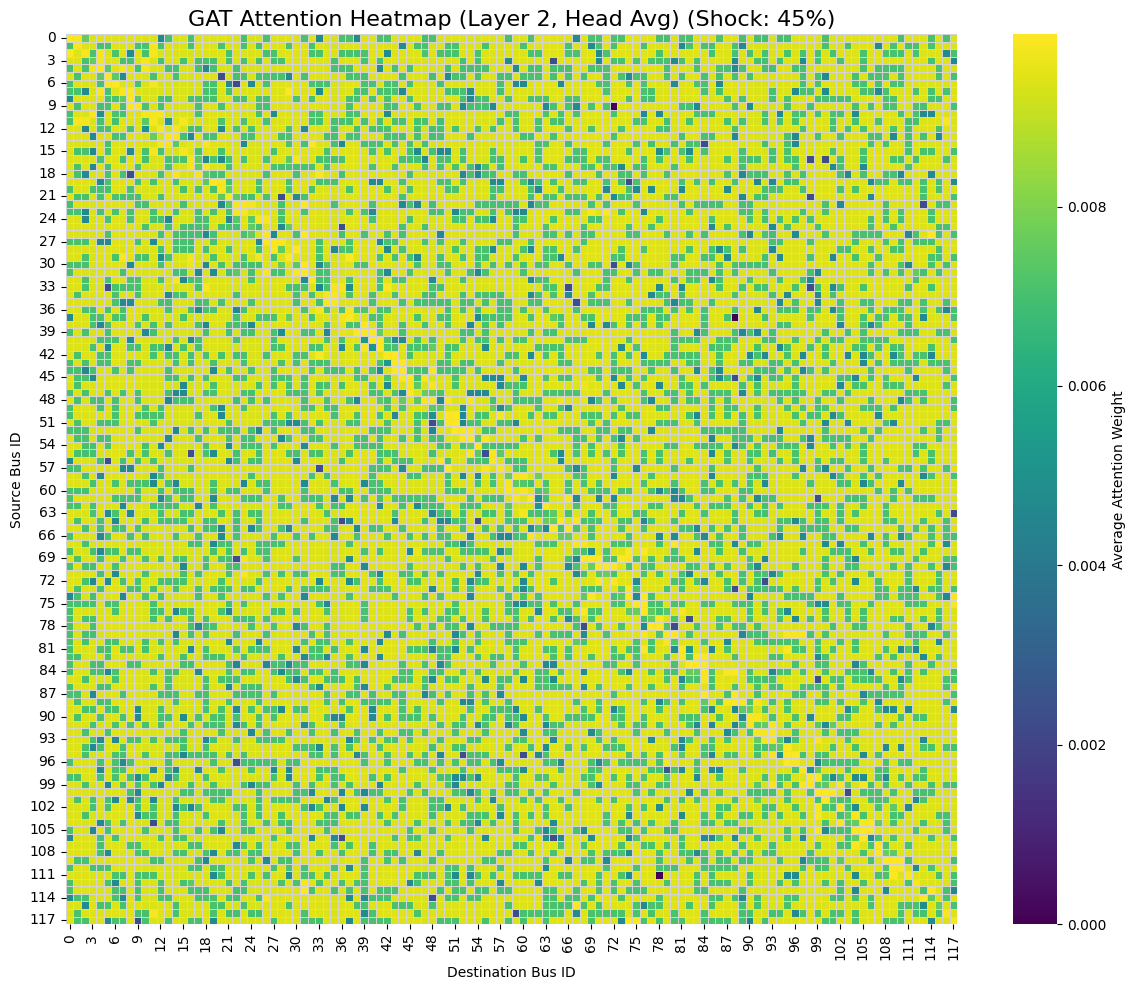

  Saved: ./output/results_viz/gat_attention_heatmap_45pct.png


In [37]:
# Call the GAT Attention Heatmap visualization
plot_gat_attention_heatmap(GAT, env_test, shock_pct=0.45)

## Section 10 — Results & Analysis

This section presents a comprehensive analysis of the Primal-Dual OPF GAT-PPO agent.

### New Lagrangian Panels in All Plots

| Panel | Metric | Interpretation |
|---|---|---|
| Constraint g_V | `max_i(|V_i-1|−V_max_dev)` | > 0 → voltage constraint violated |
| Constraint g_T | `max_k(ρ_k − 1.0)` | > 0 → thermal constraint violated |
| Constraint g_G | normalised gen limit violation | > 0 → generator limits exceeded |
| λ_V | Lagrange voltage multiplier | Rising → voltage violations being penalised |
| λ_T | Lagrange thermal multiplier | Rising → thermal violations being penalised |
| λ_G | Lagrange gen-limit multiplier | Rising → gen limit violations being penalised |

A well-converged Lagrangian controller shows:
- **g_V, g_T, g_G → 0** over training (constraints satisfied)
- **λ values stabilise** (dual variables converge)
- **Reward rises** as the agent learns to minimise generation cost within constraints

### Overview of Visualizations

1.  **Training Curves** — 10-panel dashboard including Lagrangian g and λ evolution.
2.  **In-Distribution Test Results** — 5-row dashboard with Lagrangian panels.
3.  **Out-of-Distribution Test Results** — same structure on OOD episodes.
4.  **Topology Visualization** — grid topology with voltage/loading cues.
5.  **Correlation Heatmap** — metric correlations.
6.  **Action Distribution** — histogram of P and V setpoints.
7.  **Voltage Heatmap Before Blackout** — per-bus voltage deviation over final steps.
8.  **Critic Value vs Actual Return** — critic calibration check.
9.  **Extended Sensitivity Analyses** — metric relationships.
10. **Steps vs Shock** — survival degradation.
11. **Action Radar Chart** — composite performance.
12. **Comparison Dashboard** — GAT-PPO vs rule-based baselines.


In [38]:
print("\n[VISUALISING TRAINING CURVES]")
df_train = pd.read_csv("./output/output_csv/training_history.csv")
plot_training_curves(df_train)



[VISUALISING TRAINING CURVES]
  Saved: ./output/plotly_charts/training_curves.html


In [41]:
print("\n[VISUALISING TEST RESULTS]")
plot_test_results(df_test, label="In-Distribution Test")
plot_test_results(df_ood,  label="OOD Test (Shock Gen 20-30)")


[VISUALISING TEST RESULTS]
  Saved: ./output/plotly_charts/in-distribution_test_plots.html
  Saved: ./output/plotly_charts/ood_test_shock_gen_20-30_plots.html



[TOPOLOGY VISUALISATION — initial state]


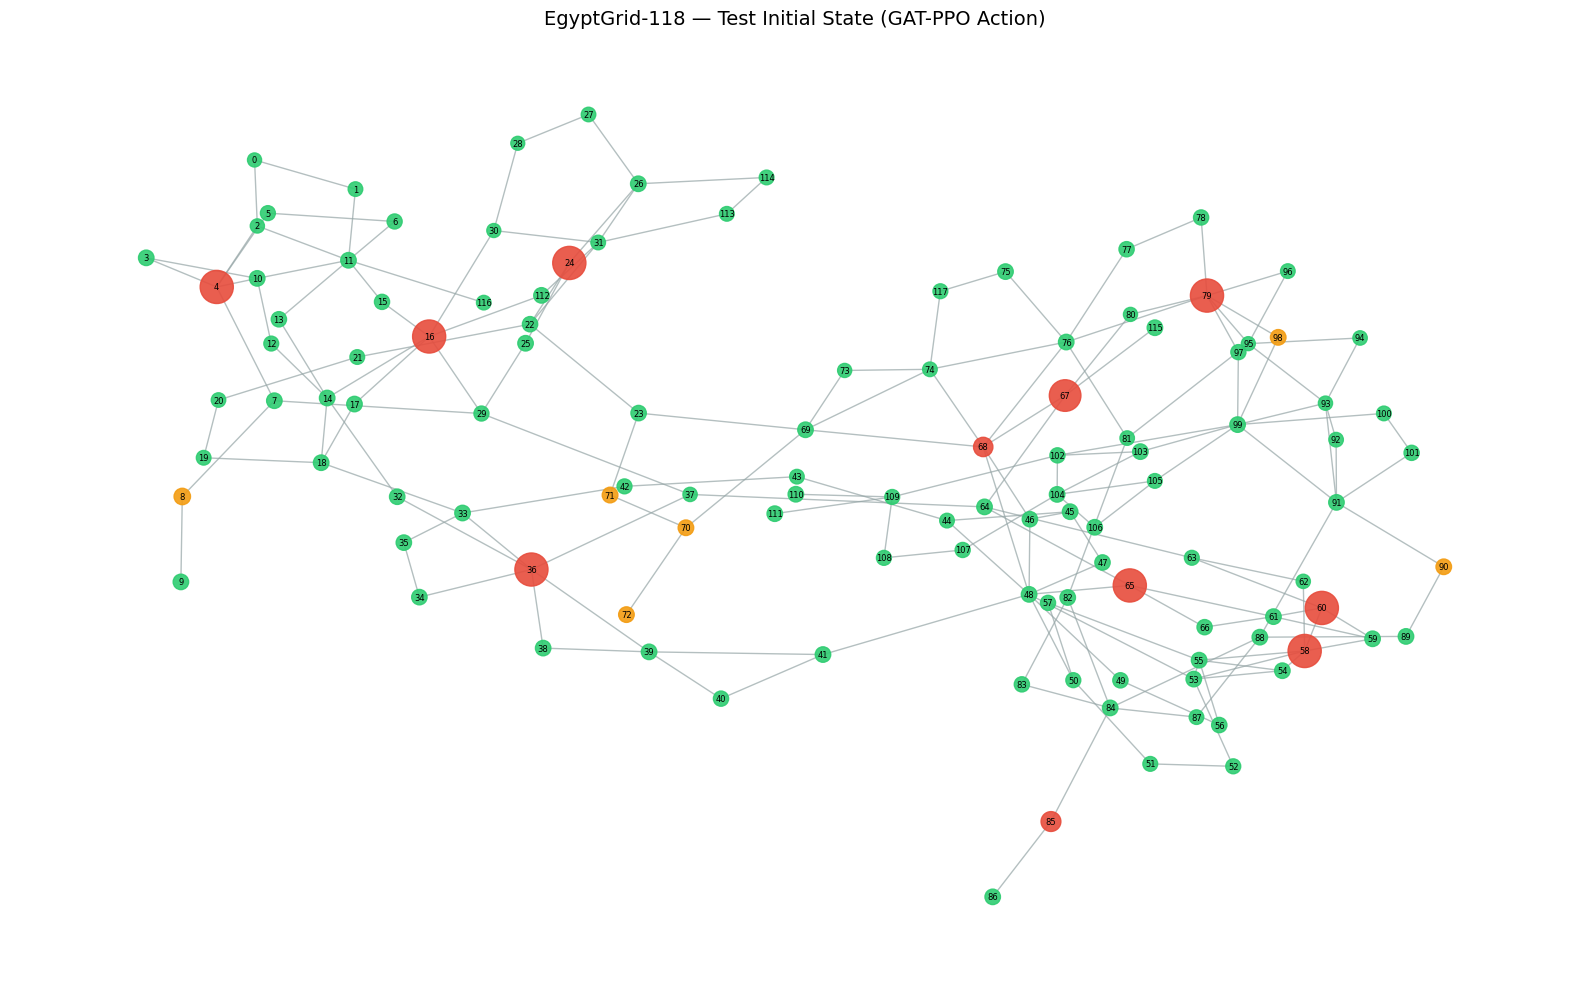

In [42]:
print("\n[TOPOLOGY VISUALISATION — initial state]")
state_42, _ = env_test.reset()
with torch.no_grad():
    bus_42, gen_42 = state_42
    st_42     = torch.FloatTensor(bus_42).unsqueeze(0)
    st_gen_42 = torch.FloatTensor(gen_42).unsqueeze(0)
    dist_P_42, dist_emg_42, _ = GAT(st_42, adj=env_test._y_bus_adj, gen_feat=st_gen_42)
    greedy_action = torch.cat([dist_P_42.mean, dist_emg_42.mean], dim=-1).numpy().flatten()

plot_topology(env_test, env_test._last_obs, action=greedy_action,
              title="EgyptGrid-118 — Test Initial State (GAT-PPO Action)")



[CORRELATION HEATMAP]


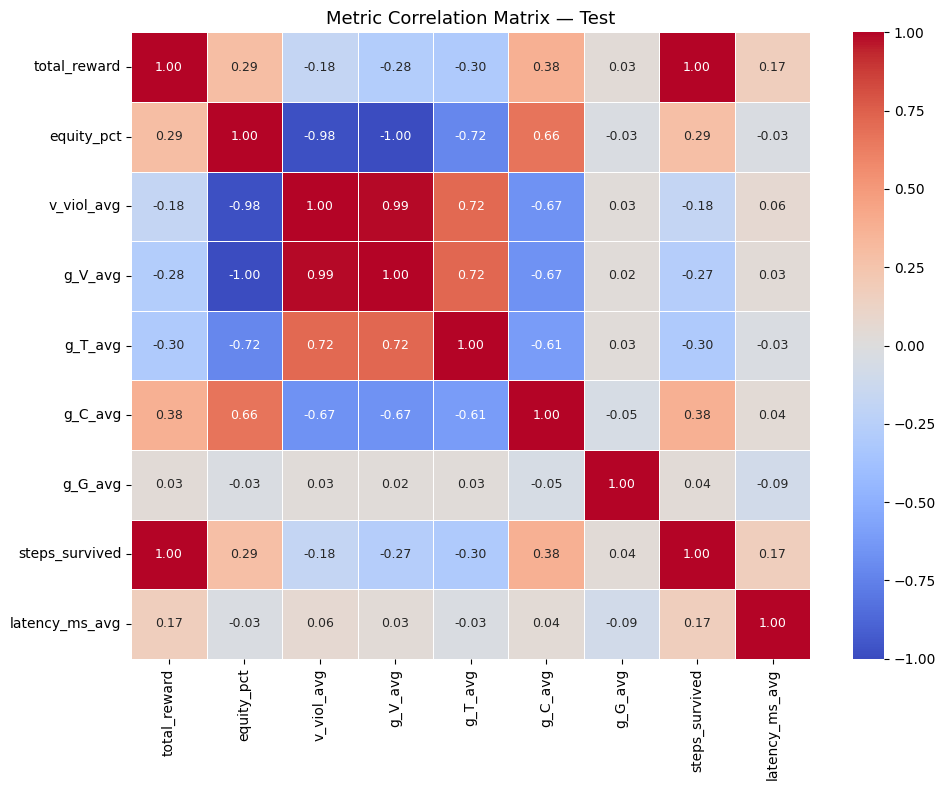

  Saved: ./output/results_viz/correlation_heatmap_test.png


In [45]:
print("\n[CORRELATION HEATMAP]")
plot_correlation_heatmap(df_test)


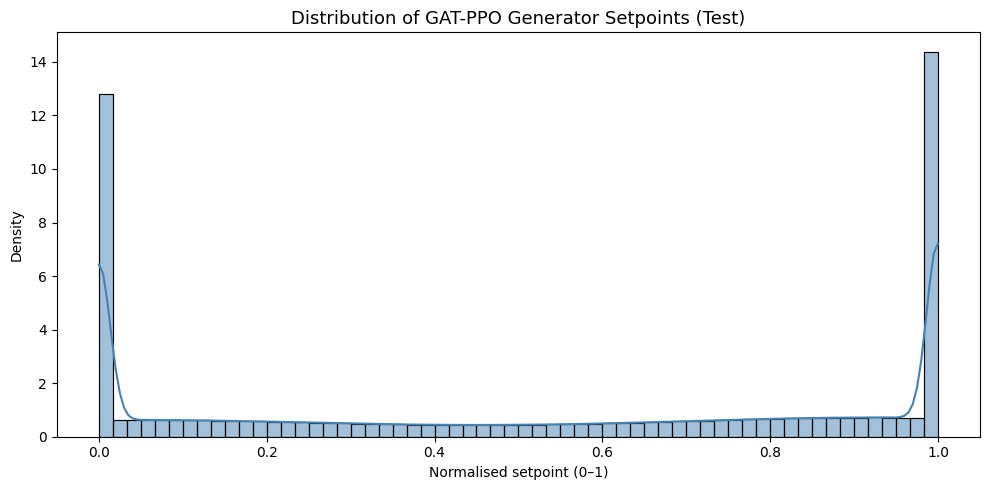

  Saved → ./output/action_distribution.png


In [ ]:
# ── Action distribution ──────────────────────────────────────────────────
all_a = np.concatenate(actions_test)
plt.figure(figsize=(10, 5))
sns.histplot(all_a, bins=60, kde=True, stat='density', color='steelblue')
plt.title('Distribution of GAT-PPO Generator Setpoints (Test)', fontsize=13)
plt.xlabel('Normalised setpoint (0–1)')
plt.ylabel('Density')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/results_viz/action_distribution.png', dpi=120)
plt.show()
print(f"  Saved → {OUTPUT_DIR}/results_viz/action_distribution.png")


### Voltage Heatmap Before Blackout

This visualization shows the voltage deviation ($|V - 1.0|$) for each bus in the system over the last 50 steps leading up to an episode termination (blackout). This can help identify which buses are most vulnerable to voltage collapse in critical situations.

In [47]:
def plot_voltage_heatmap_before_blackout(agent, env, n_steps_before_blackout=50):
    """
    Generates a heatmap of voltage deviations for the steps leading up to a blackout.
    """
    print(f"\n[GENERATING VOLTAGE HEATMAP BEFORE BLACKOUT ({n_steps_before_blackout} steps)]")

    # Set a specific shock for this simulation to have a repeatable scenario
    if hasattr(env, 'suez_shock_pct'):
        if not isinstance(env, OutOfDistributionEnv):
            env.suez_shock_pct = 0.45 # 50% Suez shock
        else:
            env.ood_percentage = 0.45 # 50% OOD shock

    state, _ = env.reset()
    voltage_deviations_history = []

    print("  Simulating episode to blackout...")
    with torch.no_grad():
        while True:
            bus_46, gen_46 = state
            st_46 = torch.FloatTensor(bus_46).unsqueeze(0)
            st_gen_46 = torch.FloatTensor(gen_46).unsqueeze(0)
            dist_P_46, dist_emg_46, _ = agent(st_46, adj=env._y_bus_adj, gen_feat=st_gen_46)
            action = torch.cat([dist_P_46.mean.clamp(0.0, 1.0), dist_emg_46.mean.clamp(0.0, 1.0)], dim=-1)

            v_pu = env._get_bus_voltages(env._last_obs) # Get current voltages
            voltage_deviations_history.append(np.abs(v_pu - 1.0))

            next_s, rew, done, _, info = env.step(action.numpy())
            state = next_s

            if done:
                print(f"  Episode terminated after {env.n_steps} steps. Blackout detected.")
                break

    if not voltage_deviations_history:
        print("  No voltage data collected. Episode might have terminated immediately.")
        return

    # Get the last N steps of voltage deviations
    steps_to_plot = min(n_steps_before_blackout, len(voltage_deviations_history))
    last_n_voltage_deviations = voltage_deviations_history[-steps_to_plot:]

    # Create a DataFrame for the heatmap
    df_heatmap = pd.DataFrame(
        np.array(last_n_voltage_deviations),
        columns=[f'Bus_{i}' for i in range(env.n_bus)],
        index=range(len(last_n_voltage_deviations))
    )

    plt.figure(figsize=(18, 8))
    sns.heatmap(
        df_heatmap.T, # Transpose to have buses on Y-axis and steps on X-axis
        cmap='plasma',
        cbar_kws={'label': 'Voltage Deviation (|V - 1.0|)'},
        yticklabels=10,
        xticklabels=10
    )
    plt.title(f'Voltage Deviation Heatmap for Last {steps_to_plot} Steps Before Blackout (Shock: {env.suez_shock_pct*100:.0f}%)', fontsize=16)
    plt.xlabel('Time Step Before Blackout')
    plt.ylabel('Bus ID')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/results_viz/voltage_heatmap_before_blackout.png', dpi=150)
    plt.show()
    print(f"  Saved: {OUTPUT_DIR}/voltage_heatmap_before_blackout.png")


[GENERATING VOLTAGE HEATMAP BEFORE BLACKOUT (50 steps)]
  Simulating episode to blackout...
  Episode terminated after 513 steps. Blackout detected.


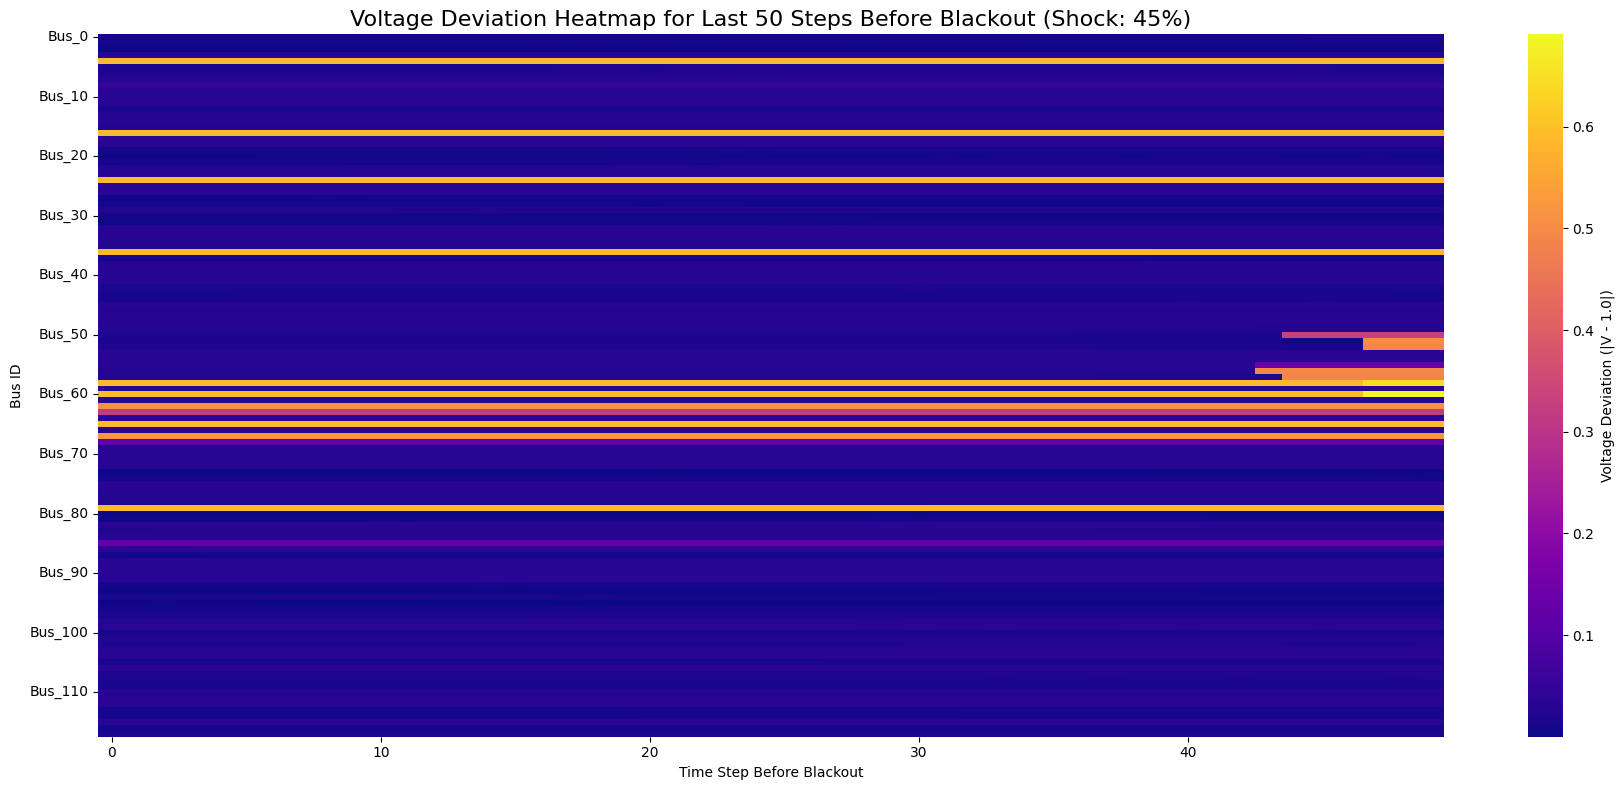

  Saved: ./output/voltage_heatmap_before_blackout.png


In [48]:
plot_voltage_heatmap_before_blackout(GAT, env_test)

### Critic Value vs. Actual Discounted Return Plot

This plot compares the values predicted by the critic network to the actual discounted returns observed during a single episode. A good critic should closely track the true returns, indicating an accurate estimation of the state's long-term value.

In [49]:
def plot_critic_value_vs_actual_return(agent, env, gamma=GAMMA, trainer=None):
    print("\n[GENERATING CRITIC VALUE VS. ACTUAL DISCOUNTED RETURN PLOT (45% shock)]")

    # Set env to a specific Wave III shock for a repeatable scenario
    if not isinstance(env, OutOfDistributionEnv):
        env.suez_shock_pct = 0.45 # Fixed 45% shock for Wave III scenario
    else:
        # If using OOD env, ensure it's set to a relevant shock
        env.ood_percentage = 0.45

    state, _ = env.reset()
    episode_rewards = []
    critic_values = []

    print("  Simulating one episode to collect data...")
    with torch.no_grad():
        while True:
            bus_c, gen_c = state
            st_c = torch.FloatTensor(bus_c).unsqueeze(0)
            st_gen_c = torch.FloatTensor(gen_c).unsqueeze(0)
            dist_P_c, dist_emg_c, val = agent(st_c, adj=env._y_bus_adj, gen_feat=st_gen_c)
            a_P_c   = dist_P_c.mean.clamp(0.0, 1.0)
            a_emg_c = dist_emg_c.mean.clamp(0.0, 1.0)
            action  = torch.cat([a_P_c, a_emg_c], dim=-1)

            critic_values.append(val.item())

            next_s, reward, done, _, _ = env.step(action.numpy())
            episode_rewards.append(reward)
            state = next_s

            if done:
                break

    # Calculate actual discounted returns
    actual_returns = []
    G = 0
    for r in reversed(episode_rewards):
        G = r + gamma * G
        actual_returns.insert(0, G)

    print(f"  Raw episode rewards min: {np.min(episode_rewards):.2f}, max: {np.max(episode_rewards):.2f}")
    print(f"  Actual returns BEFORE clipping min: {np.min(actual_returns):.2f}, max: {np.max(actual_returns):.2f}")

    # Apply clipping to actual returns for consistent comparison with critic's trained range
    actual_returns = np.array(actual_returns, dtype=np.float32)


    if trainer is not None:
        # Standardize using the stats the Critic actually learned from
        actual_returns = (actual_returns - trainer.ret_rms.mean) / (np.sqrt(trainer.ret_rms.var) + 1e-8)

    actual_returns = np.clip(actual_returns, -RETURN_NORM_CLIP, RETURN_NORM_CLIP)
    print(f"  Actual returns AFTER clipping min: {np.min(actual_returns):.2f}, max: {np.max(actual_returns):.2f}")
    # Ensure critic_values and actual_returns have the same length
    min_len = min(len(critic_values), len(actual_returns))
    critic_values = critic_values[:min_len]
    actual_returns = actual_returns[:min_len]

    if min_len == 0:
        print("  Episode was too short to generate a meaningful plot.")
        return

    # Create the plot
    fig = go.Figure()
    fig.add_trace(go.Scatter(y=critic_values, mode='lines', name='Critic Predicted Value', line=dict(color='blue')))
    fig.add_trace(go.Scatter(y=actual_returns, mode='lines', name='Actual Discounted Return', line=dict(color='red', dash='dot')))

    fig.update_layout(
        title=f'Critic Predicted Value vs. Actual Discounted Return (Wave III Shock: {env.suez_shock_pct*100:.0f}%)',
        xaxis_title='Time Step',
        yaxis_title='Value / Return',
        hovermode='x unified',
        height=500
    )

    path = f'{OUTPUT_DIR}/plotly_charts/critic_vs_actual_return.html'
    fig.write_html(path)
    print(f"  Saved: {path}")



In [50]:
plot_critic_value_vs_actual_return(GAT, env_test, trainer=PPOGAT)


[GENERATING CRITIC VALUE VS. ACTUAL DISCOUNTED RETURN PLOT (45% shock)]
  Simulating one episode to collect data...
  Raw episode rewards min: 0.27, max: 2.19
  Actual returns BEFORE clipping min: 0.27, max: 175.53
  Actual returns AFTER clipping min: -3.00, max: 3.00
  Saved: ./output/plotly_charts/critic_vs_actual_return.html


### Extended Sensitivity Analysis: Grid Performance vs. Average Voltage Violations

This section expands on the sensitivity analysis to explore the linear relationships between average voltage violations per step and other critical performance metrics. We use `seaborn.regplot` to visualize these correlations, which also provides a linear regression line to indicate trends.

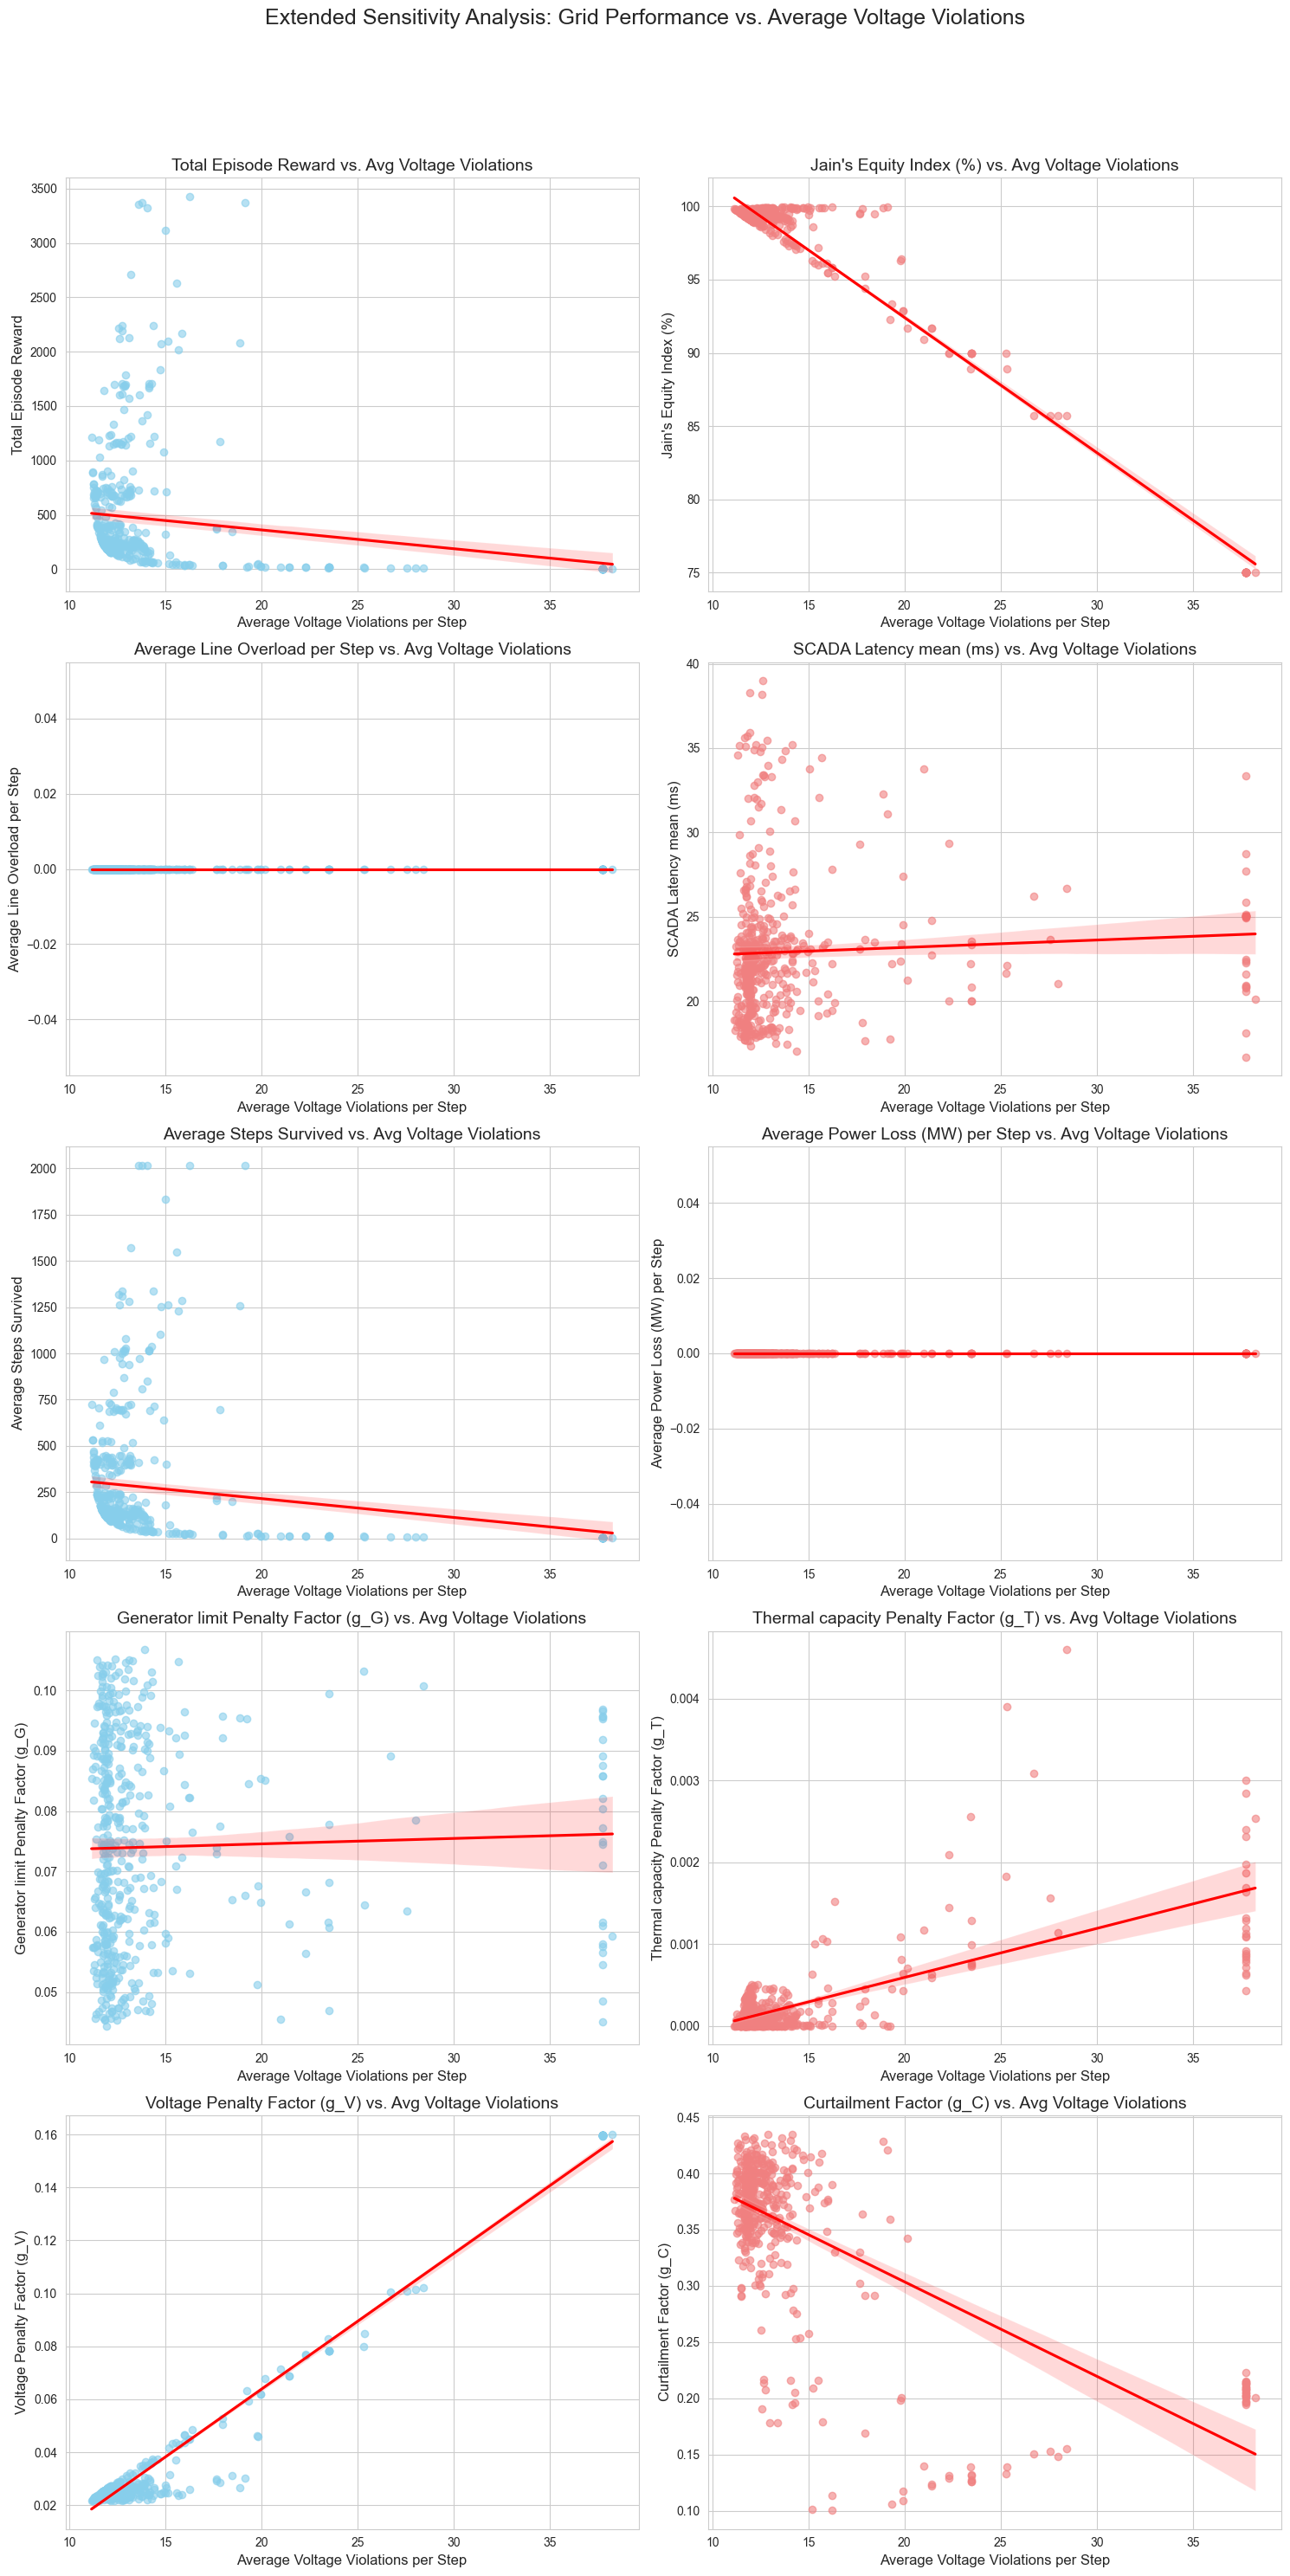

  Saved: ./output/results_viz/extended_sensitivity_voltage_violations.png


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
sns.set_style("whitegrid")

# Define all metrics to plot against v_viol_avg
metrics_to_plot = [
    ('total_reward', 'Total Episode Reward'),
    ('equity_pct', 'Jain\'s Equity Index (%)'),
    ('line_ovld_avg', 'Average Line Overload per Step'),
    ('latency_ms_avg', 'SCADA Latency mean (ms)'),
    ('steps_survived', 'Average Steps Survived'),
    ('power_loss_avg', 'Average Power Loss (MW) per Step'),
    ('g_G_avg', 'Generator limit Penalty Factor (g_G)'),
    ('g_T_avg', 'Thermal capacity Penalty Factor (g_T)'),
    ('g_V_avg', 'Voltage Penalty Factor (g_V)'),
    ('g_C_avg', 'Curtailment Factor (g_C)')
]

# Determine grid size for subplots
n_metrics = len(metrics_to_plot)
rows = (n_metrics + 1) // 2  # 2 columns per row
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
fig.suptitle('Extended Sensitivity Analysis: Grid Performance vs. Average Voltage Violations', fontsize=18, y=1.02)

# Flatten axes array for easy iteration if it's multi-dimensional
axes = axes.flatten()

for i, (col_name, title) in enumerate(metrics_to_plot):
    sns.regplot(x='v_viol_avg', y=col_name, data=df_test, ax=axes[i],
                color='skyblue' if i % 2 == 0 else 'lightcoral',
                line_kws={'color': 'red'}, scatter_kws={'alpha':0.6})
    axes[i].set_title(f'{title} vs. Avg Voltage Violations', fontsize=14)
    axes[i].set_xlabel('Average Voltage Violations per Step', fontsize=12)
    axes[i].set_ylabel(title, fontsize=12)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.savefig(f'{OUTPUT_DIR}/results_viz/extended_sensitivity_voltage_violations.png', dpi=150)
plt.show()

print(f"  Saved: {OUTPUT_DIR}/results_viz/extended_sensitivity_voltage_violations.png")

### Steps Survived vs. Shock Level

In [104]:
print("\n[VISUALISING STEPS SURVIVED VS SHOCK LEVEL]")
plot_steps_vs_shock(df_test, df_ood=df_ood, label="_comparison")


[VISUALISING STEPS SURVIVED VS SHOCK LEVEL]
  Saved: ./output/plotly_charts/steps_vs_shock_comparison.html


### Action Radar Chart

This radar chart provides a composite view of the agent's performance across various key metrics, comparing the in-distribution test results with the out-of-distribution (OOD) evaluation. Metrics are normalized to a 0-1 scale where 1 indicates optimal performance (e.g., high equity, low violations, high steps survived) and 0 indicates the worst observed performance. This allows for an intuitive side-by-side comparison of the agent's robustness and generalization capabilities.


[GENERATING ACTION RADAR CHART]


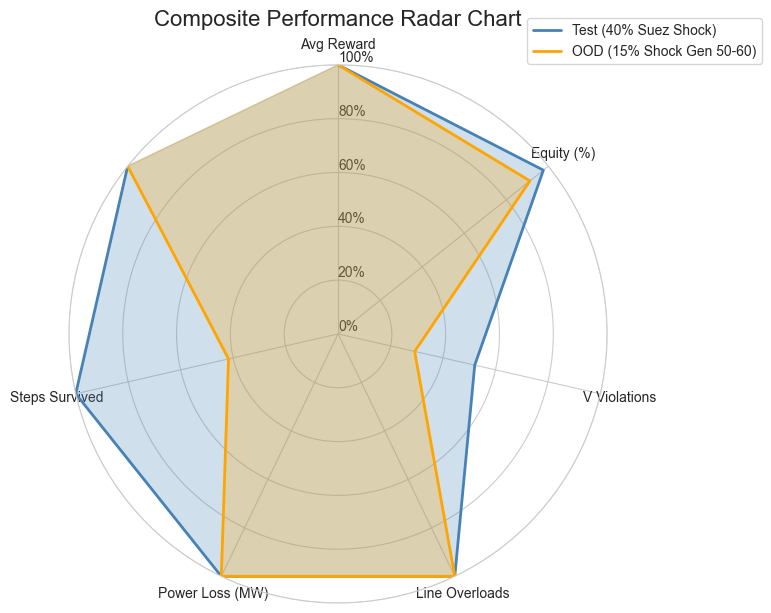

  Saved: ./output/results_viz/action_radar_chart.png


In [103]:
# Call the Action Radar Chart visualization
plot_action_radar_chart(df_test, df_ood)

## Section 11 — Quantitative Results Summary

The table below is populated with actual metrics after evaluation cells run.

| Metric | Test (15-65% shock) | OOD (10-70% shock gen 50-60) |
|---|---|---|
| Avg Episode Reward | *(after run)* | *(after run)* |
| Jain Equity Index (%) | *(after run)* | *(after run)* |
| Voltage Violations / step | *(after run)* | *(after run)* |
| Line Overloads / step | *(after run)* | *(after run)* |
| Power Loss (avg/step) | *(after run)* | *(after run)* |
| Constraint g_V (avg) | *(after run)* | *(after run)* |
| Constraint g_T (avg) | *(after run)* | *(after run)* |
| λ_V (final avg) | *(after run)* | *(after run)* |
| λ_T (final avg) | *(after run)* | *(after run)* |
| Max Voltage Deviation (pu) | *(after run)* | *(after run)* |
| Max Line Loading (rho) | *(after run)* | *(after run)* |
| SCADA Latency mean (ms) | *(after run)* | *(after run)* |
| Avg Steps Survived | *(after run)* | *(after run)* |
| Diversity Factor | *(after run)* | *(after run)* |


In [105]:
# Final side-by-side comparison
print("\n" + "="*80)
print("FINAL COMPARISON TABLE — Primal-Dual OPF-RL")
print("="*80)
print(f"{'Metric':<42} {'Test':>18} {'OOD':>16}")
print("-"*80)
metrics = [
    ('total_reward',        'Avg Episode Reward',               '{:>18.1f}',  '{:>16.1f}'),
    ('equity_pct',          'Jain Equity Index (%)',            '{:>17.2f}%', '{:>15.2f}%'),
    ('v_viol_avg',          'Voltage Violations / step',       '{:>18.3f}',  '{:>16.3f}'),
    ('latency_ms_avg',      'SCADA Latency mean (ms)',         '{:>18.3f}',  '{:>16.3f}'),
    ('steps_survived',      'Avg Steps Survived',              '{:>18.1f}',  '{:>16.1f}'),
    # Lagrangian OPF metrics
    ('g_V_avg',             'Constraint g_V (avg)',            '{:>18.5f}',  '{:>16.5f}'),
    ('g_T_avg',             'Constraint g_T (avg)',            '{:>18.5f}',  '{:>16.5f}'),
    ('g_G_avg',             'Constraint g_G (avg)',            '{:>18.5f}',  '{:>16.5f}'),
    ('max_v_dev_avg',       'Max Voltage Deviation (pu)',      '{:>18.5f}',  '{:>16.5f}'),
    ('n_violations_avg',    'N Volt Violations / step',        '{:>18.3f}',  '{:>16.3f}'),
    ('max_loading_avg',     'Max Line Loading (rho)',          '{:>18.5f}',  '{:>16.5f}'),
]
for col, name, fmt_t, fmt_o in metrics:
    if col not in df_test.columns or col not in df_ood.columns:
        continue
    vt = df_test[col].mean()
    vo = df_ood[col].mean()
    print(f"  {name:<40} {fmt_t.format(vt)} {fmt_o.format(vo)}")
print("="*80)



FINAL COMPARISON TABLE — Primal-Dual OPF-RL
Metric                                                   Test              OOD
--------------------------------------------------------------------------------
  Avg Episode Reward                                    457.8            139.5
  Jain Equity Index (%)                                97.61%           91.20%
  Voltage Violations / step                            14.368           21.237
  SCADA Latency mean (ms)                              22.934           29.230
  Avg Steps Survived                                    272.2             83.5
  Constraint g_V (avg)                                0.03505          0.07055
  Constraint g_T (avg)                                0.00025          0.00072
  Constraint g_G (avg)                                0.07406          0.12472
  Max Voltage Deviation (pu)                          0.60370          0.63272
  N Volt Violations / step                             14.368           21.237
  Max


[VISUALISING SIDE-BY-SIDE COMPARISON]


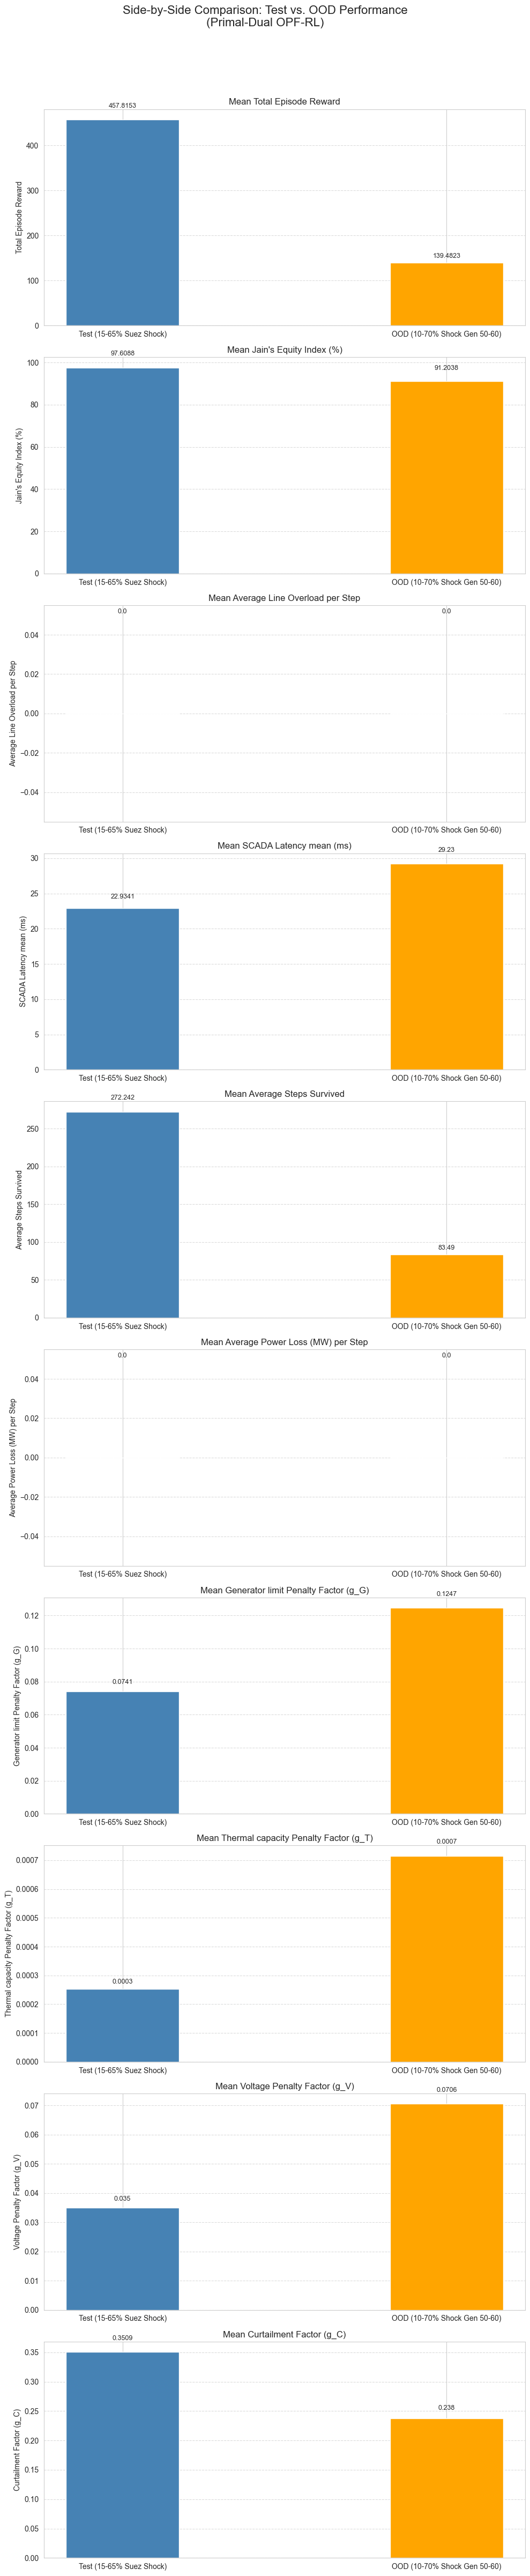

  Saved: ./output/results_viz/side_by_side_comparison_plots.png


In [106]:
import matplotlib.pyplot as plt
import numpy as np

print("\n[VISUALISING SIDE-BY-SIDE COMPARISON]")

metrics = [
    ('total_reward',        'Avg Episode Reward',               '{:>18.1f}',  '{:>16.1f}'),
    ('equity_pct',          'Jain Equity Index (%)',            '{:>17.2f}%', '{:>15.2f}%'),
    ('v_viol_avg',          'Voltage Violations / step',       '{:>18.3f}',  '{:>16.3f}'),
    ('latency_ms_avg',      'SCADA Latency mean (ms)',         '{:>18.3f}',  '{:>16.3f}'),
    ('steps_survived',      'Avg Steps Survived',              '{:>18.1f}',  '{:>16.1f}'),
    # Lagrangian OPF metrics
    ('g_V_avg',             'Constraint g_V (avg)',            '{:>18.5f}',  '{:>16.5f}'),
    ('g_T_avg',             'Constraint g_T (avg)',            '{:>18.5f}',  '{:>16.5f}'),
    ('g_G_avg',             'Constraint g_G (avg)',            '{:>18.5f}',  '{:>16.5f}'),
    ('max_v_dev_avg',       'Max Voltage Deviation (pu)',      '{:>18.5f}',  '{:>16.5f}'),
    ('n_violations_avg',    'N Volt Violations / step',        '{:>18.3f}',  '{:>16.3f}'),
    ('max_loading_avg',     'Max Line Loading (rho)',          '{:>18.5f}',  '{:>16.5f}'),
]
# Filter to columns present in both dataframes
metrics_to_plot = [(c, t) for c, t in metrics_to_plot
                   if c in df_test.columns and c in df_ood.columns]

fig, axes = plt.subplots(nrows=len(metrics_to_plot), ncols=1,
                          figsize=(10, 5 * len(metrics_to_plot)))
fig.suptitle('Side-by-Side Comparison: Test vs. OOD Performance\n'
             '(Primal-Dual OPF-RL)', fontsize=16, y=0.99)

width = 0.35

for i, (col, title) in enumerate(metrics_to_plot):
    ax = axes[i]
    val_test = df_test[col].mean()
    val_ood  = df_ood[col].mean()
    labels   = ['Test (15-65% Suez Shock)', 'OOD (10-70% Shock Gen 50-60)']
    values   = [val_test, val_ood]
    x        = np.arange(len(labels))
    bars = ax.bar(x, values, width, color=['steelblue', 'orange'])
    ax.set_ylabel(title)
    ax.set_title(f'Mean {title}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                yval + (yval * 0.05 if yval != 0 else 0.05),
                round(yval, 4), ha='center', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig(f'{OUTPUT_DIR}/results_viz/side_by_side_comparison_plots.png', dpi=150)
plt.show()
print(f"  Saved: {OUTPUT_DIR}/results_viz/side_by_side_comparison_plots.png")


## Section 12 — Rule-Based Baselines Comparison

This section introduces rule-based dispatch strategies (Pro-Rata, Merit-Order, and Voltage-Sensitivity) to serve as baselines for comparison against the GAT-PPO agent. All baselines are evaluated using the same `RobustEnv` physics, reward structure, and metrics as the trained agent, ensuring a fair comparison. The `_action_voltage_sensitivity` function has been optimized for vectorized computation.

### Strategy Implementations

-   **Pro-Rata**: Scales generation proportionally to available headroom.
-   **Merit-Order**: Dispatches generators based on ascending marginal cost (renewables first, then gas, then oil).
-   **Voltage-Sensitivity**: Prioritizes generators electrically close to voltage-violated buses, falling back to Pro-Rata if no violations occur.

In [107]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# =============================================================================
#  MARGINAL COST TABLE
#  Source: EETC Annual Report 2022/2023 & IEA Egypt energy data
#  Units: USD / MWh (approximate, used for merit-order ranking only)
# =============================================================================
# Maps fuel-type keywords (lowercase) → marginal cost proxy
MARGINAL_COST = {
    'hydro':  0.0,    # zero fuel cost — always dispatch first
    'wind':   0.0,    # zero fuel cost
    'solar':  0.0,    # zero fuel cost
    'gas':   45.0,    # CCGT at ~$45/MWh (Egyptian LNG spot, 2023)
    'oil':   85.0,    # oil peakers — expensive, last resort
    'unknown': 50.0,  # conservative fallback
}

def _marginal_cost(source_str: str) -> float:
    """Return the marginal cost proxy for a generator's fuel type."""
    s = str(source_str).lower()
    for key, cost in MARGINAL_COST.items():
        if key in s:
            return cost
    return MARGINAL_COST['unknown']


def _build_hop_distance(env, max_hops: int = 6) -> np.ndarray:
    """
    Build a bus × bus hop-distance matrix from the Grid2Op line topology.

    Returns int array of shape (n_bus, n_bus).  Entry [i, j] is the
    minimum number of lines needed to travel from bus i to bus j.
    Disconnected pairs are set to max_hops + 1.
    """
    g2 = env.g2op_env
    n  = g2.n_sub
    G  = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(g2.n_line):
        G.add_edge(g2.line_or_to_subid[i], g2.line_ex_to_subid[i])
    dist = dict(nx.all_pairs_shortest_path_length(G, cutoff=max_hops))
    D = np.full((n, n), max_hops + 1, dtype=np.int32)
    for i, row in dist.items():
        for j, d in row.items():
            D[i, j] = d
    return D


# Pre-build hop distance once — cached as module-level after first call
_hop_distance_cache: dict = {}

def _get_hop_distance(env) -> np.ndarray:
    env_id = id(env)
    if env_id not in _hop_distance_cache:
        _hop_distance_cache[env_id] = _build_hop_distance(env)
    return _hop_distance_cache[env_id]


# =============================================================================
#  STRATEGY IMPLEMENTATIONS
# =============================================================================

def _action_pro_rata(env, obs) -> np.ndarray:
    """
    Proportional (pro-rata) redispatch.

    Each generator receives a setpoint proportional to its available
    headroom: (gen_pmax - gen_pmin) / sum_of_headrooms.

    This matches the automatic generation control (AGC) signal sent
    by Egyptian dispatch centres during frequency deviations when
    no specific generator is targeted.

    Rationale: when total load > available generation, AGC scales all
    controllable units proportionally to headroom so that no single
    unit is pushed to its limit while others sit idle.
    """
    pmax   = np.array(env.g2op_env.gen_pmax, dtype=np.float32)
    pmin   = np.array(env.g2op_env.gen_pmin, dtype=np.float32)
    headroom = np.maximum(0.0, pmax - pmin)
    total_hr = headroom.sum()

    total_load = float(obs.load_p.sum())
    sum_pmin = pmin.sum()

    if total_hr < 1e-6:
        # Fallback: uniform dispatch at 70% capacity (relative to real_pmax)
        # Clip will handle if real_pmax is too low
        # return np.full(env.action_dim, 0.70, dtype=np.float32)
        fraction = 0.0
    else:
        fraction = np.clip((total_load - sum_pmin) / total_hr, 0.0, 1.0)

    # Each generator's setpoint is its share of headroom, scaled by this fraction
    # and then normalized by its real_pmax to get a [0,1] action
    setpoints  = (pmin + fraction * headroom) / (np.array(env.real_pmax) + 1e-8)

    return np.clip(setpoints, 0.0, 1.0).astype(np.float32)


def _action_merit_order(env, obs, gen_sources) -> np.ndarray:
    """
    Merit-order (economic) dispatch.

    Dispatches generators in ascending marginal cost order until total
    load demand is met.  Renewable generators (cost=0) always run first
    at full capacity.  Gas CCGT plants fill the residual.  Oil peakers
    are dispatched last.

    This is the standard EETC daily dispatch schedule.  Under Suez shock
    the gas fleet is already derated by the environment before this
    function is called, so the merit-order sees the post-shock capacities.

    Parameters
    ----------
    env         : RobustEnv instance
    obs         : current Grid2Op observation
    gen_sources : list/array of fuel-type strings, length n_gen
                  (from env.g2op_env.gen_type or CSV sources)
    """
    n_gen   = env.action_dim
    pmax_g2 = np.array(env.g2op_env.gen_pmax, dtype=np.float32)
    pmin_g2 = np.array(env.g2op_env.gen_pmin, dtype=np.float32)

    costs   = np.array([_marginal_cost(src) for src in gen_sources], dtype=np.float32)
    order   = np.argsort(costs)   # cheapest → most expensive

    # Scale target load to Egyptian MW capacity, if applicable
    target_load = float(obs.load_p.sum())
    setpoints   = np.zeros(n_gen, dtype=np.float32)
    remaining   = target_load

    for idx in order:
        if remaining <= 0:
            break
        max_mw  = float(pmax_g2[idx])
        min_mw  = float(pmin_g2[idx])


        if remaining < min_mw:
            # Cannot run this generator below minimum stable load — skip it
            continue

        # Dispatch up to available max, but not less than min (if remaining load is high enough)
        # If remaining is less than min_mw, this generator won't be dispatched fully or at all by this logic

        # The generator will only provide what's needed up to its max capability
        dispatch_this_gen = min(remaining, max_mw)

        # Convert dispatch_this_gen (MW) to a normalized setpoint [0, 1]
        setpoints[idx] = dispatch_this_gen / (float(pmax_g2[idx]) + 1e-8)
        remaining -= dispatch_this_gen

    return np.clip(setpoints, 0.0, 1.0).astype(np.float32)


def _action_voltage_sensitivity(env, obs) -> np.ndarray:
    """
    Voltage-sensitivity-weighted redispatch (optimized vectorized version).

    When voltage violations are present, real SCADA operators increase
    output on generators electrically close to voltage-violated buses.
    This is a simplified version of the sensitivity-based redispatch
    defined in ENTSO-E operational guidelines (OP 12.003).

    Algorithm:
    1. Identify buses with |V - 1.0| > 0.05 pu (voltage violations).
    2. For each generator g at bus b_g, compute a proximity weight:
         w_g = sum over violated buses v of  1 / (hop(b_g, v) + 1)
    3. Dispatch each generator proportionally to w_g × headroom_g,
       scaled to meet total load demand.

    If no violations exist, fall back to pro-rata dispatch.
    """
    v_pu  = env._get_bus_voltages(obs)
    viols = np.where(np.abs(v_pu - 1.0) > 0.05)[0]   # violated bus indices

    if len(viols) == 0:
        # No violations — standard pro-rata is sufficient
        return _action_pro_rata(env, obs)

    hop_D   = _get_hop_distance(env)
    pmax_g2 = np.array(env.g2op_env.gen_pmax, dtype=np.float32)
    pmin_g2 = np.array(env.g2op_env.gen_pmin, dtype=np.float32)
    headroom = np.maximum(0.0, pmax_g2 - pmin_g2)

    # Generator bus assignments
    gen_bus = np.array(env.g2op_env.gen_to_subid)

    # Vectorized calculation of weights
    # hop_D_subset has shape (n_gen, len(viols))
    # It contains hop_distance from each generator's bus to each violated bus
    hop_D_subset = hop_D[gen_bus[:, None], viols]
    weights = np.sum(1.0 / (hop_D_subset.astype(np.float32) + 1.0), axis=1)

    # Weight × headroom gives a sensitivity-scaled capacity
    sensitivity = weights * headroom
    total_sens  = sensitivity.sum()
    if total_sens < 1e-6:
        return _action_pro_rata(env, obs)

    target_load = float(obs.load_p.sum()) * env.cap_scale
    fractions   = sensitivity / total_sens
    allocs_mw   = fractions * target_load
    allocs_mw   = np.clip(allocs_mw, pmin_g2, pmax_g2)
    setpoints   = allocs_mw / (np.array(env.real_pmax) + 1e-8)
    return np.clip(setpoints, 0.0, 1.0).astype(np.float32)


# =============================================================================
#  UNIFIED EVALUATION RUNNER
# =============================================================================

def evaluate_rule_based(
    env,
    strategy: str = 'merit_order',
    n_episodes: int = 100,
    shock_range: tuple = (0.15, 0.65),
    seed: int = 42,
    label: str = None,
) -> tuple:
    """
    Evaluate a rule-based dispatch strategy on RobustEnv.

    Uses exactly the same evaluation loop, metrics, and diversity-factor
    computation as evaluate_agent() in the training script so results
    are directly comparable.

    Parameters
    ----------
    env          : RobustEnv  (the same env used for GAT-PPO evaluation)
    strategy     : one of 'pro_rata', 'merit_order', 'voltage_sensitivity'
    n_episodes   : number of episodes to evaluate
    shock_range  : (lo, hi) Suez shock fraction sampled uniformly each episode
    seed         : numpy random seed for reproducibility
    label        : display name (auto-derived from strategy if None)

    Returns
    -------
    pd.DataFrame  — same columns as evaluate_agent output
    list[np.ndarray] — actions taken per step
    """
    rng = np.random.default_rng(seed)
    if label is None:
        label = strategy.replace('_', ' ').title()

    # Retrieve generator source strings for merit-order cost lookup
    gen_sources_str = ['unknown'] * env.action_dim # Default fallback
    try:
        # Prioritize CSV sources if available and then Grid2Op's gen_type
        # Accessing `env.g2op_env.gen_type` directly, assuming it exists
        # This ensures `gen_sources_str` is populated with actual fuel types for merit order
        if hasattr(env, '_gen_sources') and env._gen_sources is not None:
            gen_sources_str = list(env._gen_sources)
        else:
            gen_sources_str = list(env.g2op_env.gen_type)
    except Exception:
        # If all else fails, use 'unknown'
        pass

    records, all_actions = [], []
    STRATEGY_MAP = {
        'pro_rata':            _action_pro_rata,
        'merit_order':         _action_merit_order,
        'voltage_sensitivity': _action_voltage_sensitivity,
    }
    if strategy not in STRATEGY_MAP:
        raise ValueError(f"Unknown strategy '{strategy}'. "
                         f"Choose from: {list(STRATEGY_MAP.keys())}")

    print(f"\n{'='*65}")
    print(f"RULE-BASED [{label}] — {n_episodes} episodes")
    print(f"{'='*65}")
    print(
        f"{'EP':>4} | {'Equity%':>8} | {'V_viol':>6} | "
        f"{'Ovld':>5} | {'PLoss':>7} | {'Lat(ms)':>8} | {'Steps':>6}"
    )
    print("-"*65)

    for ep in range(n_episodes):
        shock = float(rng.uniform(shock_range[0], shock_range[1]))
        env.suez_shock_pct = shock
        state, _ = env.reset()

        ep_r, ep_eq, ep_vv, ep_ov, ep_lt, ep_pl = 0.0, [], [], [], [], []
        episode_load_p_history = []
        n_steps = 0

        while True:
            t0  = time.perf_counter()
            obs = env._last_obs

            # --- Compute rule-based action ---
            if strategy == 'merit_order':
                act = STRATEGY_MAP[strategy](env, obs, gen_sources_str)
            else:
                act = STRATEGY_MAP[strategy](env, obs)

            all_actions.append(act.copy()) # Store a copy of the action
            lat = (time.perf_counter() - t0) * 1000.0

            next_s, rew, done, _, _ = env.step(act)

            ep_r += rew
            ep_eq.append(env.last_equity)
            ep_vv.append(env.last_v_viol)
            ep_ov.append(env.last_line_ovld)
            ep_lt.append(lat)
            ep_pl.append(env.last_power_loss)
            episode_load_p_history.append(env._last_obs.load_p.copy())
            n_steps += 1

            if done:
                break

        # Diversity factor — identical formula to evaluate_agent
        diversity_factor = 0.0
        if episode_load_p_history:
            arr = np.array(episode_load_p_history)
            sum_ind_max = np.max(arr, axis=0).sum()
            max_sim     = np.sum(arr, axis=1).max()
            if max_sim > 1e-8:
                diversity_factor = sum_ind_max / max_sim

        rec = {
            'episode':          ep,
            'total_reward':     round(ep_r, 2),
            'equity_pct':       round(float(np.mean(ep_eq)), 3),
            'v_viol_avg':       round(float(np.mean(ep_vv)), 3),
            'line_ovld_avg':    round(float(np.mean(ep_ov)), 3),
            'latency_ms_avg':   round(float(np.mean(ep_lt)), 3),
            'steps_survived':   n_steps,
            'power_loss_avg':   round(float(np.mean(ep_pl)), 3),
            'diversity_factor': round(diversity_factor, 3),
            'shock_pct':        shock,
            'strategy':         label,
        }
        records.append(rec)

        if ep % 10 == 0:
            print(f"{ep:>4} | {rec['equity_pct']:>7.2f}% | "
                  f"{rec['v_viol_avg']:>6.2f} | {rec['line_ovld_avg']:>5.2f} | "
                  f"{rec['power_loss_avg']:>7.1f} | "
                  f"{rec['latency_ms_avg']:>8.3f} | {n_steps:>6}")

    df = pd.DataFrame(records)
    print(f"\n[{label}] complete — "
          f"avg equity {df.equity_pct.mean():.2f}% | "
          f"avg steps {df.steps_survived.mean():.1f}")
    return df, all_actions


# =============================================================================
#  COMPARISON TABLE (printed)
# =============================================================================

def print_comparison_table(
    df_gat: pd.DataFrame,
    df_pro_rata: pd.DataFrame,
    df_merit: pd.DataFrame,
    df_volt: pd.DataFrame,
) -> None:
    """
    Print a formatted side-by-side comparison table of all four strategies
    across every metric tracked by evaluate_agent / evaluate_rule_based.
    """
    dfs = {
        'GAT-PPO (Ours)':       df_gat,
        'Pro-Rata':              df_pro_rata,
        'Merit-Order':           df_merit,
        'Voltage-Sensitivity':   df_volt,
    }
    metrics = [
        ('equity_pct',       'Jain Equity Index (%)',          '.2f',  True),
        ('v_viol_avg',       'Voltage Violations / step',      '.3f',  False),
        ('line_ovld_avg',    'Line Overload / step',           '.3f',  False),
        ('power_loss_avg',   'Power Loss MW / step',           '.2f',  False),
        ('steps_survived',   'Avg Steps Survived',             '.1f',  True),
        ('diversity_factor', 'Diversity Factor',               '.3f',  True),
        ('latency_ms_avg',   'Decision Latency (ms)',          '.3f',  None),
    ]

    # Column widths
    col_w = 22
    print(f"\n{'='*100}")
    print("  COMPARISON TABLE — GAT-PPO vs Rule-Based Redispatch Baselines")
    print(f"  Evaluation: {len(df_gat)} episodes, Suez shock {df_gat.shock_pct.min()*100:.0f}%–{df_gat.shock_pct.max()*100:.0f}%, same RobustEnv")
    print(f"{'='*100}")

    header = f"{'Metric':<35}"
    for name in dfs:
        header += f"{name:>{col_w}}"
    print(header)
    print("-"*100)

    for col, name, fmt, higher_better in metrics:
        row = f"{name:<35}"
        vals = {k: df[col].mean() for k, df in dfs.items()}
        best_val = None
        if higher_better is not None:
            if higher_better:
                best_val = max(vals.values())
            else:
                best_val = min(vals.values())

        for k, v in vals.items():
            cell = format(v, fmt)
            # Mark best value with ★
            is_best = (higher_better is not None) and (
                (higher_better and v == best_val) or
                (not higher_better and v == best_val)
            )
            row += f"{' ★ ' + cell if is_best else cell:>{col_w}}"
        print(row)

    print(f"{'='*100}")
    print("  ★ = best value for that metric")
    print(f"{'='*100}\n")


# =============================================================================
#  VISUALISATION DASHBOARD
# =============================================================================

# Colour scheme — consistent across all plots
COLOURS = {
    'GAT-PPO':            '#2E86C1',   # blue
    'Pro-Rata':           '#E74C3C',   # red
    'Merit-Order':        '#27AE60',   # green
    'Voltage-Sensitivity':'#F39C12',   # amber
}

def _shade(df, fig, row, col, metric, color, name, showlegend=True):
    """Add mean ± std band + mean line to a subplot."""
    # Ensure 'episode' column exists and df is not empty
    if df.empty or 'episode' not in df.columns:
        return

    # For shading, we need to sort by episode to ensure correct band drawing
    df_sorted = df.sort_values('episode').reset_index(drop=True)
    eps  = df_sorted['episode'].tolist()
    mean = df_sorted[metric].tolist()

    # Calculate std only if there's more than one data point
    if len(df_sorted) > 1:
        std_val  = df_sorted[metric].std()
    else:
        std_val = 0 # No standard deviation for single point

    std = [std_val] * len(eps)
    upper = [m + s for s, m in zip(mean, std)]
    lower = [m - s for m, s in zip(mean, std)]

    # Convert hex color to rgba for fill (COLOURS uses hex format)
    def _hex_to_rgba(hex_color, alpha=0.12):
        h = hex_color.lstrip('#')
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        return f'rgba({r},{g},{b},{alpha})'
    fill_color = _hex_to_rgba(color) if color.startswith('#') else color.replace(')', ',0.12)').replace('rgb', 'rgba')

    # Shaded band
    fig.add_trace(go.Scatter(
        x=eps + eps[::-1], y=upper + lower[::-1],
        fill='toself', fillcolor=fill_color,
        line=dict(width=0), showlegend=False, hoverinfo='skip',
    ), row=row, col=col)
    # Mean line
    fig.add_trace(go.Scatter(
        x=eps, y=mean, mode='lines',
        line=dict(color=color, width=2),
        name=name, showlegend=showlegend,
    ), row=row, col=col)


def plot_comparison_dashboard(
    df_gat:       pd.DataFrame,
    df_pro_rata:  pd.DataFrame,
    df_merit:     pd.DataFrame,
    df_volt:      pd.DataFrame,
    output_dir:   str = '/content/output',
    shock_levels: list = None,
) -> None:
    """
    Generate all comparison visualisations and save to output_dir.

    Produces 6 figures:
    1. Multi-metric overview dashboard (Plotly — interactive HTML)
    2. Per-shock-level performance breakdown (Plotly)
    3. Radar chart (Plotly — interactive HTML)
    4. CDF of steps survived per strategy (Plotly — interactive HTML)
    5. Performance degradation vs. shock level (Plotly — interactive HTML)
    6. Box plots of key metrics (Plotly — interactive HTML)
    """
    dfs = {
        'GAT-PPO':            df_gat,
        'Pro-Rata':           df_pro_rata,
        'Merit-Order':        df_merit,
        'Voltage-Sensitivity':df_volt,
    }

    # ── 1. OVERVIEW DASHBOARD ─────────────────────────────────
    metrics_cfg = [
        ('equity_pct',       'Jain Equity Index (%)',         1, 1, True),
        ('v_viol_avg',       'Voltage Violations / step',     1, 2, False),
        ('line_ovld_avg',    'Line Overload / step',          2, 1, False),
        ('power_loss_avg',   'Power Loss (MW/step)',          2, 2, False),
        ('steps_survived',   'Steps Survived',                3, 1, True),
        ('diversity_factor', 'Diversity Factor',              3, 2, True),
    ]
    fig1 = make_subplots(
        rows=3, cols=2,
        subplot_titles=[m[1] for m in metrics_cfg],
        vertical_spacing=0.10, horizontal_spacing=0.08,
    )
    for name, df in dfs.items():
        col = COLOURS[name]
        for met, title, row, c, higher in metrics_cfg:
            show = (met == 'equity_pct')   # show legend only on first panel
            _shade(df, fig1, row, c, met, col, name, show)
        # Add reference lines
    fig1.add_hline(y=90, row=1, col=1, line=dict(color='black', width=1, dash='dot'),
                   annotation_text='Target 90%', annotation_font_color='black')
    fig1.add_hline(y=0,  row=1, col=2, line=dict(color='black', width=1, dash='dot'))
    fig1.update_layout(
        # Removed STYLE
        height=900,
        title=dict(
            text='EgyptGrid-118 | GAT-PPO vs Rule-Based Redispatch Baselines<br>'
                 '<sup>100 episodes · Suez shock 15%–65% · same RobustEnv physics</sup>',
            font=dict(size=15, color='black'),
        ),
        legend=dict(
            orientation='h', y=-0.20, x=0.5, xanchor='center', # Legend at bottom
            bgcolor='rgba(0,0,0,0)', font=dict(size=10, color='black')
        ),
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(gridcolor='lightgrey'), yaxis=dict(gridcolor='lightgrey'),
    )
    for ax_name in ['xaxis', 'xaxis2', 'xaxis3', 'xaxis4',
               'yaxis', 'yaxis2', 'yaxis3', 'yaxis4']:
        fig1.update_layout(**{ax_name: dict(gridcolor='lightgrey', zerolinecolor='lightgrey')})

    path1 = f'{output_dir}/comp_viz/comparison_overview.html'
    fig1.write_html(path1)
    print(f"  Saved: {path1}")

    # ── 2. PER-SHOCK-LEVEL BREAKDOWN ─────────────────────────────────
    if shock_levels is None:
        shock_levels = [0.15, 0.30, 0.45, 0.60]

    tol = 0.07   # ± tolerance for binning episodes to a shock level
    fig2 = make_subplots(
        rows=2, cols=2,
        subplot_titles=[f'Shock ≈ {int(s*100)}%' for s in shock_levels],
        vertical_spacing=0.15, horizontal_spacing=0.10,
    )
    bar_metrics = ['equity_pct', 'v_viol_avg', 'steps_survived', 'power_loss_avg']
    bar_labels  = ['Equity %',   'V-viol/step', 'Steps',          'P-loss MW']

    for s_idx, shock in enumerate(shock_levels):
        row = s_idx // 2 + 1
        col = s_idx %  2 + 1
        for name, df in dfs.items():
            subset = df[np.abs(df['shock_pct'] - shock) < tol]
            if subset.empty:
                continue
            vals    = [subset[m].mean() for m in bar_metrics]
            max_v   = max(abs(v) for v in vals) or 1.0
            norm_v  = [v / max_v for v in vals]   # normalise to [0,1] for same axis
            fig2.add_trace(go.Bar(
                name=name, x=bar_labels, y=norm_v,
                marker_color=COLOURS[name],
                showlegend=(s_idx == 0),
            ), row=row, col=col)

    fig2.update_layout(
        # Removed STYLE
        height=700, barmode='group',
        title=dict(
            text='Performance by Shock Level — Normalised Metrics',
            font=dict(size=14, color='black'),
        ),
        legend=dict(orientation='h', y=-0.28, x=0.5, xanchor='center', # Legend at bottom
                    bgcolor='rgba(0,0,0,0)', font=dict(size=10, color='black'))
    )
    fig2.update_layout(plot_bgcolor='white', paper_bgcolor='white')
    for ax_name in ['xaxis', 'xaxis2', 'xaxis3', 'xaxis4',
               'yaxis', 'yaxis2', 'yaxis3', 'yaxis4']:
        fig2.update_layout(**{ax_name: dict(gridcolor='lightgrey', title_font=dict(color='black'), tickfont=dict(color='black'))})


    path2 = f'{output_dir}/comp_viz/comparison_by_shock.html'
    fig2.write_html(path2)
    print(f"  Saved: {path2}")

# 3 - Performance chart
    radar_cfg = [
        # (column, label, higher_is_better, clip_min, clip_max)
        ('equity_pct',       'Equity Index',     True,   0,   100),
        ('v_viol_avg',       'V-Stability (inv)', False, 0,   30),
        ('line_ovld_avg',    'Thermal (inv)',     False,  0,    5),
        ('power_loss_avg',   'Efficiency (inv)',  False,  0,  500),
        ('steps_survived',   'Survival',          True,   0,  300),
        ('diversity_factor', 'Diversity Factor',  True,   1.0, 1.4),
    ]

    categories = [r[1] for r in radar_cfg]
    fig = go.Figure()

    # 2. Iterate through your dataframes (matching your existing loop logic)
    for name, df in dfs.items():
        vals = []
        for col_name, _, higher, lo, hi in radar_cfg:
            raw = df[col_name].mean()
            # Normalization logic
            n = np.clip((raw - lo) / (hi - lo + 1e-8), 0, 1)
            vals.append(1 - n if not higher else n)

        # Plotly needs the path to close by repeating the first value
        vals.append(vals[0])
        display_categories = categories + [categories[0]]

        fig.add_trace(go.Scatterpolar(
            r=vals,
            theta=display_categories,
            fill='toself',
            name=name,
            line=dict(color=COLOURS[name], width=2),
            fillcolor=f"rgba{tuple(list(int(COLOURS[name].lstrip('#')[i:i+2], 16) for i in (0, 2, 4)) + [0.08])}",
            hoverinfo='name+theta+r'
        ))

    # 3. Apply the dark aesthetic styling
    fig.update_layout(
        template='plotly_white', # Changed to plotly_white
        paper_bgcolor='white',
        plot_bgcolor='white',
        title={
            'text': "Performance Radar<br><sup>(normalised, higher = better)</sup>",
            'y': 0.95,
            'x': 0.5,
            'xanchor': 'center',
            'yanchor': 'top',
            'font': dict(color='black', size=16) # Changed font color to black
        },
        polar=dict(
            bgcolor='white',
            radialaxis=dict(
                visible=True,
                range=[0, 1],
                tickvals=[0.25, 0.5, 0.75, 1.0],
                tickfont=dict(color='black', size=10), # Changed font color to black
                gridcolor='lightgrey',
                linecolor='lightgrey',
            ),
            angularaxis=dict(
                tickfont=dict(color='black', size=11), # Changed font color to black
                gridcolor='lightgrey',
                linecolor='lightgrey',
            )
        ),
        legend=dict(
            font=dict(color='black'), # Changed font color to black
            bgcolor='rgba(0,0,0,0)',
            bordercolor='lightgrey',
            borderwidth=1,
            orientation="h", # Changed to horizontal
            x=0.5, y=-0.15, xanchor='center' # Positioned at the bottom
        ),
        margin=dict(l=80, r=80, t=100, b=80),
        showlegend=True
    )

    # 4. Save and Show
    path3_html = f'{output_dir}/comp_viz/comparison_radar.html'
    fig.write_html(path3_html)

    print(f"Saved: {path3_html}")
    # ── 4. CDF OF STEPS SURVIVED ─────────────────────────────
    fig4 = go.Figure()
    for name, df in dfs.items():
        steps = np.sort(df['steps_survived'].values)
        cdf   = np.arange(1, len(steps) + 1) / len(steps)
        fig4.add_trace(go.Scatter(
            x=steps, y=cdf * 100,
            mode='lines', name=name,
            line=dict(color=COLOURS[name], width=2.5),
        ))
    fig4.add_vline(x=100, line=dict(color='black', width=1, dash='dot'),
                   annotation_text='100 steps', annotation_font_color='black')
    fig4.update_layout(
        # Removed STYLE
        height=450,
        title=dict(text='CDF of Episode Survival — Steps Before Grid Collapse',
                   font=dict(size=14, color='black')),
        xaxis=dict(title='Steps Survived', gridcolor='lightgrey', title_font=dict(color='black'), tickfont=dict(color='black')),
        yaxis=dict(title='Cumulative % of Episodes', gridcolor='lightgrey', title_font=dict(color='black'), tickfont=dict(color='black')),
        legend=dict(bgcolor='rgba(0,0,0,0)', font=dict(size=10, color='black'), orientation='h', x=0.5, y=-0.23, xanchor='center'), # Changed to horizontal, positioned at bottom
        plot_bgcolor='white',
        paper_bgcolor='white'
    )
    path4 = f'{output_dir}/comp_viz/comparison_survival_cdf.html'
    fig4.write_html(path4)
    print(f"  Saved: {path4}")

    # ── 5. METRIC DELTA vs SHOCK LEVEL (scatter + regression) ─────────
    fig5 = make_subplots(
        rows=1, cols=2,
        subplot_titles=['Jain Equity vs Shock Level',
                        'Steps Survived vs Shock Level'],
        horizontal_spacing=0.12,
    )
    for name, df in dfs.items():
        color = COLOURS[name]
        for metric, row, col in [('equity_pct', 1, 1), ('steps_survived', 1, 2)]:
            fig5.add_trace(go.Scatter(
                x=df['shock_pct'] * 100,
                y=df[metric],
                mode='markers',
                marker=dict(color=color, size=5, opacity=0.5),
                name=name, showlegend=(metric == 'equity_pct'),
            ), row=row, col=col)
            # Linear trendline
            x_v = df['shock_pct'].values * 100
            y_v = df[metric].values
            coeffs = np.polyfit(x_v, y_v, 1)
            x_line = np.linspace(x_v.min(), x_v.max(), 50)
            fig5.add_trace(go.Scatter(
                x=x_line, y=np.polyval(coeffs, x_line),
                mode='lines', line=dict(color=color, width=2, dash='dash'),
                showlegend=False,
            ), row=row, col=col)

    fig5.update_layout(
        # Removed STYLE
        height=450,
        title=dict(text='Performance Degradation Under Increasing Suez Shock',
                   font=dict(size=14, color='black')),
        xaxis=dict(title='Shock Level (%)', gridcolor='lightgrey', title_font=dict(color='black'), tickfont=dict(color='black')),
        yaxis=dict(title='Jain Equity (%)', gridcolor='lightgrey', title_font=dict(color='black'), tickfont=dict(color='black')),
        xaxis2=dict(title='Shock Level (%)', gridcolor='lightgrey', title_font=dict(color='black'), tickfont=dict(color='black')),
        yaxis2=dict(title='Steps Survived', gridcolor='lightgrey', title_font=dict(color='black'), tickfont=dict(color='black')),
        legend=dict(bgcolor='rgba(0,0,0,0)', font=dict(size=10, color='black'), orientation='h', x=0.5, y=-0.33, xanchor='center'), # Legend at bottom
        plot_bgcolor='white',
        paper_bgcolor='white'
    )
    path5 = f'{output_dir}/comp_viz/comparison_shock_degradation.html'
    fig5.write_html(path5)
    print(f"  Saved: {path5}")

    # ── 6. BOX PLOTS — DISTRIBUTION OF KEY METRICS ─────────────────────────
    fig6, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white') # Changed facecolor to white

    box_metrics = [
        ('equity_pct',    'Jain Equity Index (%)'),
        ('v_viol_avg',    'Voltage Violations / step'),
        ('steps_survived','Steps Survived'),
    ]
    colors_list = list(COLOURS.values())
    labels_list = list(COLOURS.keys())

    for ax, (met, title) in zip(axes, box_metrics):

        ax.set_facecolor('white') # Changed facecolor to white

        data_to_plot = [dfs[name][met].values for name in COLOURS]

        bp = ax.boxplot(
            data_to_plot,
            patch_artist=True,
            medianprops=dict(color='black', linewidth=2), # Changed median color to black
            whiskerprops=dict(color='grey'), # Changed whisker color
            capprops=dict(color='grey'), # Changed cap color
            flierprops=dict(marker='o', color='grey', markersize=3, alpha=0.4), # Changed flier color
        )

        for patch, color in zip(bp['boxes'], colors_list):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_xticks(range(1, len(labels_list) + 1))
        ax.set_xticklabels(labels_list, rotation=15, ha='right',
                           color='black', fontsize=8) # Changed font color to black
        ax.set_title(title, color='black', fontsize=11) # Changed font color to black
        ax.set_ylabel(title, color='black', fontsize=9) # Changed font color to black
        ax.tick_params(colors='black') # Changed tick color to black
        ax.spines['bottom'].set_color('lightgrey') # Changed spine color
        ax.spines['left'].set_color('lightgrey') # Changed spine color
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.label.set_color('black') # Changed y-axis label color to black
        ax.grid(axis='y', color='lightgrey', alpha=0.5)
    fig6.suptitle('Distribution of Key Metrics — All Strategies', color='black', fontsize=13) # Changed suptitle color to black
    plt.tight_layout()
    path6 = f'{output_dir}/comp_viz/comparison_boxplots.png'

    plt.savefig(path6, dpi=150, bbox_inches='tight', facecolor='white') # Changed facecolor to white

    print(f"  Saved: {path6}")
    print(f"\n[COMPARISON] All figures saved to {output_dir}")

### Evaluation Block

This block runs the evaluation for each rule-based strategy and generates the comparison dashboard and table. This code should be executed after the GAT-PPO training and evaluation (`df_test` dataframe) are complete.

In [108]:
# =============================================================================
#  PHASE 6 — Rule-Based Comparison
#  Run this block after GAT-PPO training and df_test are available.
# =============================================================================


COMPARISON_SHOCK_RANGE = (0.15, 0.65)   # same range as evaluate_agent
COMPARISON_EPISODES    = 100
COMPARISON_SEED        = 0              # different seed from GAT-PPO eval (42)

# Ensure the eval env uses the same fresh env instance
# RobustEnv is already imported implicitly if the main notebook is run sequentially
env_compare = RobustEnv(
    noise_std=0.02,
    failure_prob=0.05,
    suez_shock_pct=0.0,
    is_test_env=False,
)

print("\n[PHASE 6a] Pro-Rata redispatch baseline...")
df_pro_rata, _ = evaluate_rule_based(
    env_compare, strategy='pro_rata',
    n_episodes=COMPARISON_EPISODES,
    shock_range=COMPARISON_SHOCK_RANGE,
    seed=COMPARISON_SEED,
    label='Pro-Rata',
)

print("\n[PHASE 6b] Merit-Order redispatch baseline...")
df_merit, _ = evaluate_rule_based(
    env_compare, strategy='merit_order',
    n_episodes=COMPARISON_EPISODES,
    shock_range=COMPARISON_SHOCK_RANGE,
    seed=COMPARISON_SEED,
    label='Merit-Order',
)

print("\n[PHASE 6c] Voltage-Sensitivity redispatch baseline...")
df_volt, _ = evaluate_rule_based(
    env_compare, strategy='voltage_sensitivity',
    n_episodes=COMPARISON_EPISODES,
    shock_range=COMPARISON_SHOCK_RANGE,
    seed=COMPARISON_SEED,
    label='Voltage-Sensitivity',
)

# Save all baseline results
df_pro_rata.to_csv(f'{OUTPUT_DIR}/output_csv/comparison_pro_rata.csv', index=False)
df_merit.to_csv(f'{OUTPUT_DIR}/output_csv/comparison_merit_order.csv', index=False)
df_volt.to_csv(f'{OUTPUT_DIR}/output_csv/comparison_volt_sensitivity.csv', index=False)

# Tag the GAT-PPO dataframe with its strategy name for legend labels
df_test_tagged = df_test.copy()
df_test_tagged['strategy'] = 'GAT-PPO'

print("\n[PHASE 6d] Comparison summary table:")
print_comparison_table(df_test_tagged, df_pro_rata, df_merit, df_volt)

RobustEnv ready — n_bus=118, action_dim=186

[PHASE 6a] Pro-Rata redispatch baseline...

RULE-BASED [Pro-Rata] — 100 episodes
  EP |  Equity% | V_viol |  Ovld |   PLoss |  Lat(ms) |  Steps
-----------------------------------------------------------------


IndexError: index 7 is out of bounds for axis 0 with size 0

In [ ]:
print("\n[PHASE 6e] Generating comparison visualisations...")
plot_comparison_dashboard(
    df_gat=df_test_tagged,
    df_pro_rata=df_pro_rata,
    df_merit=df_merit,
    df_volt=df_volt,
    output_dir=OUTPUT_DIR,
)

## Section 13: Ablation Study

In [109]:
print("\n[ABLATION STUDY CONSTANTS]")
ORIG_W_EQUITY        = 20.0   # Original Jain's equity bonus weight
ORIG_W_V_LOAD_PEN    = 20.0   # Original L1 voltage penalty (load buses)
ORIG_W_V_GEN_PEN     = 6.0    # Original L1 voltage penalty (generator buses)
ORIG_W_THERMAL_PEN   = 50.0   # Original soft thermal penalty
print(f"  Original W_EQUITY: {ORIG_W_EQUITY}")
print(f"  Original W_V_LOAD_PEN: {ORIG_W_V_LOAD_PEN}")
print(f"  Original W_V_GEN_PEN: {ORIG_W_V_GEN_PEN}")
print(f"  Original W_THERMAL_PEN: {ORIG_W_THERMAL_PEN}")


[ABLATION STUDY CONSTANTS]
  Original W_EQUITY: 20.0
  Original W_V_LOAD_PEN: 20.0
  Original W_V_GEN_PEN: 6.0
  Original W_THERMAL_PEN: 50.0


### Training & Evaluation for Ablation: No `Y_bus` Adjacency Matrix

In [110]:
class GAT_ActorCritic_NoAdj(GAT_ActorCritic):
    """
    Ablation model: GAT_ActorCritic where the GAT layers internally ignore
    the adjacency matrix, effectively disabling topology-aware attention.
    All other architecture is identical to the main model.
    """
    def __init__(self, n_bus, action_dim):
        super().__init__(n_bus, action_dim)

    def forward(self, x, adj=None, gen_feat=None, return_attention=False):
        # Override forward: always pass adj=None to disable Y-bus attention
        return super().forward(x, adj=None, gen_feat=gen_feat, return_attention=return_attention)


In [ ]:
print("\n[PHASE ABLATION 1.1] Initialising environments (No GAT Adj)...")
env_train_ablation1 = RobustEnv(noise_std=0.02, failure_prob=0.05, suez_shock_pct=0.0)
env_test_ablation1  = RobustEnv(noise_std=0.02, failure_prob=0.05, suez_shock_pct=0.0, is_test_env=False)

print("\n[PHASE ABLATION 1.2] Building model (No GAT Adj)...")
# Use the new GAT_ActorCritic_NoAdj model for this ablation
GAT_ablation1    = GAT_ActorCritic_NoAdj(n_bus=env_train_ablation1.n_bus, action_dim=env_train_ablation1.action_dim)
PPOGAT_ablation1 = PPOTrainer(GAT_ablation1, lr=LR, clip_eps=CLIP_EPS, gamma=GAMMA, gae_lambda=GAE_LAMBDA)
print(f"  Trainable parameters: {count_params(GAT_ablation1):,}")

print(f"\n[PHASE ABLATION 1.3] Curriculum Training (No GAT Adj) ({TOTAL_TRAIN_EPISODES} scenarios)...")
history_ablation1 = train_curriculum(env_train_ablation1, GAT_ablation1, PPOGAT_ablation1, verbose_every=50)

hist_df_ablation1 = pd.DataFrame({k: v for k, v in history_ablation1.items() if k != 'latencies'})
hist_df_ablation1.to_csv(f'{OUTPUT_DIR}/output_csv/training_history_ablation1.csv', index=False)
pd.DataFrame({'latency_ms': history_ablation1['latencies']}).to_csv(
    f'{OUTPUT_DIR}/output_csv/training_latencies_ablation1.csv', index=False)
print(f"  Saved training history for ablation 1 \u2192 {OUTPUT_DIR}/training_history_ablation1.csv")

In [ ]:
# ── Save final weights & load best checkpoint for ablation 1 ─────────────

torch.save(GAT_ablation1.state_dict(), './checkpoints/last_gat_ppo_egypt118_ablation1.pth')

best_ckpt_ablation1 = './checkpoints/best_gat_ppo_egypt118_ablation1.pth' # Use a specific checkpoint for ablation 1
if os.path.exists(best_ckpt_ablation1):
    PPOGAT_ablation1.load_checkpoint(best_ckpt_ablation1)   # uses weights_only=True internally
else:
    print("  No best checkpoint found for ablation 1 — using current weights.")

In [ ]:
print("\n[PHASE ABLATION 1.4] Test Evaluation (No GAT Adj)...")
df_test_ablation1, actions_test_ablation1 = evaluate_agent(GAT_ablation1, env_test, n_episodes=100, label="ABLATION 1 TEST (No GAT Adj)")
df_test_ablation1.to_csv(f'{OUTPUT_DIR}/output_csv/test_results_ablation1.csv', index=False)
print(f"  Saved {OUTPUT_DIR}/output_csv/test_results_ablation1.csv")
print_summary(df_test_ablation1, "Ablation 1 Test Evaluation \u2014 No GAT Adj")

### Compare Ablation: (No GAT Adj) vs. Primal-Dual

In [ ]:
print("\n" + "="*80)
print("FINAL COMPARISON TABLE \u2014 Ablation 1 (No GAT Adj) vs. Primal-Dual OPF-RL")
print("="*80)
print(f"{'Metric':<42} {'Primal-Dual':>18} {'No GAT Adj':>16}")
print("-"*80)
metrics = [
    ('total_reward',        'Avg Episode Reward',               '{:>18.1f}',  '{:>16.1f}'),
    ('equity_pct',          'Jain Equity Index (%)',            '{:>17.2f}%', '{:>15.2f}%'),
    ('v_viol_avg',          'Voltage Violations / step',       '{:>18.3f}',  '{:>16.3f}'),
    ('line_ovld_avg',       'Line Overloads / step',           '{:>18.3f}',  '{:>16.3f}'),
    ('power_loss_avg',      'Power Loss (avg/step)',           '{:>18.3f}',  '{:>16.3f}'),
    ('latency_ms_avg',      'SCADA Latency mean (ms)',         '{:>18.3f}',  '{:>16.3f}'),
    ('steps_survived',      'Avg Steps Survived',              '{:>18.1f}',  '{:>16.1f}'),
    ('diversity_factor',    'Diversity Factor',                '{:>18.3f}',  '{:>16.3f}'),
    ('g_V_avg',             'Constraint g_V (avg)',            '{:>18.5f}',  '{:>16.5f}'),
    ('g_T_avg',             'Constraint g_T (avg)',            '{:>18.5f}',  '{:>16.5f}'),
    ('g_G_avg',             'Constraint g_G (avg)',            '{:>18.5f}',  '{:>16.5f}'),
    ('lambda_V_avg',        'Lambda_V (final avg)',            '{:>18.5f}',  '{:>16.5f}'),
    ('lambda_T_avg',        'Lambda_T (final avg)',            '{:>18.5f}',  '{:>16.5f}'),
    ('lambda_G_avg',        'Lambda_G (final avg)',            '{:>18.5f}',  '{:>16.5f}'),
    ('max_v_dev_avg',       'Max Voltage Deviation (pu)',      '{:>18.5f}',  '{:>16.5f}'),
    ('n_violations_avg',    'N Volt Violations / step',        '{:>18.3f}',  '{:>16.3f}'),
    ('max_loading_avg',     'Max Line Loading (rho)',          '{:>18.5f}',  '{:>16.5f}'),
]
for col, name, fmt_pd, fmt_ab1 in metrics:
    if col not in df_test.columns or col not in df_test_ablation1.columns:
        continue
    vt_pd = df_test[col].mean()
    vt_ab1 = df_test_ablation1[col].mean()
    print(f"  {name:<40} {fmt_pd.format(vt_pd)} {fmt_ab1.format(vt_ab1)}")
print("="*80)


print("\n[VISUALISING SIDE-BY-SIDE COMPARISON: Ablation 1 vs. Primal-Dual]")

def plot_ablation_comparison_dashboard_1(df_primal_dual: pd.DataFrame, df_ablation: pd.DataFrame, output_dir: str = '/content/output') -> None:
    dfs = {
        'Primal-Dual': df_primal_dual,
        'No GAT Adj (Ablation)': df_ablation,
    }
    COLORS_AB = {
        'Primal-Dual':            '#2E86C1',   # blue
        'No GAT Adj (Ablation)': '#E74C3C',   # red
    }

    metrics_cfg = [
        ('total_reward',     'Total Episode Reward',          1, 1, True),
        ('steps_survived',   'Steps Survived',                1, 2, True),
        ('v_viol_avg',       'Voltage Violations / step',     2, 1, False),
        ('max_v_dev_avg',    'Max Voltage Deviation (pu)',    2, 2, False),
        ('power_loss_avg',   'Power Loss (MW/step)',          3, 1, False),
    ]
    fig_ab = make_subplots(
        rows=3, cols=2,
        subplot_titles=[m[1] for m in metrics_cfg],
        vertical_spacing=0.10, horizontal_spacing=0.08,
    )
    for name, df in dfs.items():
        col = COLORS_AB[name]
        for met, title, row, c, higher in metrics_cfg:
            df_plot = df.copy()
            df_plot['episode'] = np.arange(len(df_plot))
            _shade(df_plot, fig_ab, row, c, met, col, name, showlegend=(met == 'total_reward'))

    fig_ab.add_hline(y=0,  row=1, col=1, line=dict(color='black', width=1, dash='dot'))
    fig_ab.add_hline(y=0,  row=1, col=2, line=dict(color='black', width=1, dash='dot'))
    fig_ab.update_layout(
        height=900,
        title=dict(
            text='EgyptGrid-118 | Ablation: No GAT Adj vs Primal-Dual OPF<br><sup>100 episodes \u00b7 Suez shock 15%\u201365% \u00b7 same RobustEnv physics</sup>',
            font=dict(size=15, color='black'),
        ),
        legend=dict(
            orientation='h', y=-0.20, x=0.5, xanchor='center', # Legend at bottom
            bgcolor='rgba(0,0,0,0)', font=dict(size=10, color='black')
        ),
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(gridcolor='lightgrey'), yaxis=dict(gridcolor='lightgrey'),
    )
    for ax_name in ['xaxis', 'xaxis2', 'xaxis3', 'xaxis4', 'xaxis5', 'xaxis6',
               'yaxis', 'yaxis2', 'yaxis3', 'yaxis4', 'yaxis5', 'yaxis6']:
        fig_ab.update_layout(**{ax_name: dict(gridcolor='lightgrey', zerolinecolor='lightgrey')})

    path_ab = f'{output_dir}/abl_study/ablation1_comparison_overview.html'
    fig_ab.write_html(path_ab)
    fig_ab.show()
    print(f"  Saved: {path_ab}")

plot_ablation_comparison_dashboard_1(df_test, df_test_ablation1, OUTPUT_DIR)

## Contributions

This notebook makes the following novel contributions relative to the Phase 3 baseline:

1.  **Primal-dual (Lagrangian) OPF reward** (§2): Replaces soft penalty shaping with a principled constrained optimisation formulation. Lagrange multipliers λ_V, λ_T, λ_G are updated via dual ascent at each step, providing theoretically grounded constraint satisfaction.

2.  **Constraint function definitions** (§2): g_V, g_T, g_G are computed from AC power-flow outputs at every step — physically correct violations rather than heuristic penalty proxies.

3.  **Upgraded action space** (§2): The policy now outputs both ΔP_g (active power setpoints) and V_g (voltage setpoints) in a 2×n_gen action vector, moving closer to full OPF control.

4.  **Safety layer** (§2): Hard clipping of P_g to [gen_pmin, gen_pmax] and V_g to [V_LOW_WARN, V_HIGH_WARN] before dispatch, ensuring physical feasibility at every step.

5.  **Generation cost minimisation** (§2): Quadratic + linear OPF cost function c(P_g) added to reward, directly minimising economic dispatch cost as in classical OPF.

6.  **Reduced fairness weight** (§1): Jain's equity bonus reduced by 10× (20.0→2.0), preventing it from dominating the Lagrangian constraint terms.

7.  **Extended Lagrangian logging** (§6,§7): Per-episode tracking of g_V, g_T, g_G, λ_V, λ_T, λ_G, max voltage deviation, number of violations, and max line loading enables post-hoc analysis of constraint satisfaction.

8.  **Updated visualisation** (§8,§10): Training curves and test result dashboards extended with Lagrangian constraint and multiplier panels, enabling clear diagnosis of dual convergence.

9.  **Preserved physics and GAT** (§4): AC power flow (LightSim2Grid), admittance-weighted GAT, and complex Y_bus topology are fully preserved. No DC approximations introduced.
